# Silver 02b — EDA on Profiled Silver States

### Ask

What is this notebook doing?

### Answer

This notebook performs Silver EDA using the profiled states created in Silver 02a.

Instead of only comparing the original source labels, this notebook compares:

- `normal_clean`
- `normal_contaminated`
- `abnormal`
- `recovery`

The goal is to understand how sensor behavior changes across these profiled groups, produce generator-ready artifacts, and preserve the evidence needed to explain why clean-normal data is a better modeling reference than all originally labeled normal rows.

## Environment Setup and Utility Imports

### Ask

Why start with imports and setup?

### Answer

This notebook needs dataframe, plotting, configuration, artifact, truth-record, and logging utilities before it can run the profiled-state EDA.

At this point, I am only preparing the environment. The actual analysis begins after the profiled Silver dataframe and its supporting registry files are loaded.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, cast
import json
import logging
import math
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew as scipy_skew, kurtosis as scipy_kurtosis

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.ensemble import IsolationForest

from utils.core.paths import get_paths
from utils.core.file_io import (
    load_json, 
    save_json,
)

from utils.core.logging_setup import (
    configure_logging, 
    log_layer_paths,
)

from utils.core.ledger import Ledger

from utils.core.truths import (
    make_process_run_id,
    identify_meta_columns,
    load_parent_truth_record_from_dataframe,
    get_dataset_name_from_truth,
    get_truth_hash,
    get_parent_truth_hash,
    get_artifact_path_from_truth,
    extract_truth_hash,
    get_pipeline_mode_from_truth,
    get_truth_value,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
)

from utils.core.config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)


from utils.core.artifacts import (
    build_artifact_dirs,
    build_artifact_dirs_from_config,
    artifact_file_path,
)
from utils.database.postgres import (
    get_engine_from_env, 
    read_sql_dataframe,
)

from utils.database.layer_postgres import (
    read_layer_dataframe, 
    write_layer_dataframe, 
    prepare_layer_dataframe,
)

from utils.database.sql_notebook_helpers import (
    delete_dataset_run_rows,
    execute_many,
    get_existing_dataframe,
    get_row_value,
    log_data_quality_event,
    log_pipeline_artifact,
    preview_sql_table,
    row_to_payload,
    sql_table_ref,
    to_builtin,
    to_json_string,
    to_scalar,
    upsert_pipeline_run,
)

from utils.database.medallion_sql_writers import (
    log_gold_05_anomaly_detection_summary_sql,
    log_silver_eda_sql,
    write_bronze_sensor_observations_sql,
    write_gold_baseline_scores_sql,
    write_gold_cascade_scores_sql,
    write_gold_model_comparison_results_sql,
    write_gold_preprocessed_features_sql,
    write_silver_sensor_observation_features_sql,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 200)

SQL schema: capstone
Dataset ID: pump_synthetic_v1
Run ID: synthetic_run_001


In [2]:
def require_dict(value: Any | None, name: str) -> Dict[str, Any]:
    if value is None:
        return {}

    if not isinstance(value, dict):
        raise TypeError(
            f"{name} must be a dictionary, got {type(value).__name__}: {value!r}"
        )

    return cast(Dict[str, Any], value)


def require_list(value: Any | None, name: str) -> List[Any]:
    if value is None:
        return []

    if not isinstance(value, list):
        raise TypeError(
            f"{name} must be a list, got {type(value).__name__}: {value!r}"
        )

    return cast(List[Any], value)


def scalar_to_float(value: object, name: str = "value") -> float:
    if value is None:
        raise ValueError(f"{name} cannot be None.")

    if value is pd.NA:
        raise ValueError(f"{name} cannot be pandas NA.")

    if isinstance(value, float) and math.isnan(value):
        raise ValueError(f"{name} cannot be NaN.")

    return float(cast(Any, value))

## Environment Setup and Utility Imports

### Ask

Why start with imports and setup?

### Answer

This notebook needs dataframe, plotting, configuration, artifact, truth-record, and logging utilities before it can run the profiled-state EDA.

At this point, I am only preparing the environment. The actual analysis begins after the profiled Silver dataframe and its supporting registry files are loaded.

In [ ]:
paths = get_paths()

CONFIG_ROOT = paths.configs
CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"

CONFIG = cast(
    Dict[str, Any],
    load_pipeline_config(
        config_root=CONFIG_ROOT,
        stage="silver_eda",
        dataset="pump",
        mode=CONFIG_RUN_MODE,
        profile=CONFIG_PROFILE,
        project_root=paths.root,
    ).data,
)

SILVER_EDA_CFG = cast(Dict[str, Any], CONFIG["silver_eda"])
PATHS = cast(Dict[str, Any], CONFIG["resolved_paths"])
FILENAMES = cast(Dict[str, Any], CONFIG["filenames"])
VERSIONS_CFG = cast(Dict[str, Any], CONFIG["versions"])

PIPELINE = cast(
    Dict[str, Any],
    CONFIG.get(
        "pipeline",
        {
            "execution_mode": "batch",
            "orchestration_mode": "notebook",
        },
    ),
)

RUNTIME_CFG = cast(Dict[str, Any], CONFIG["runtime"])
DATASET_CFG = cast(Dict[str, Any], CONFIG["dataset"])
WANDB_CFG = cast(Dict[str, Any], CONFIG["wandb"])
EXECUTION_CFG = cast(Dict[str, Any], CONFIG.get("execution", {}))

TRUTH_CONFIG = cast(Dict[str, Any], build_truth_config_block(CONFIG))
TRUTH_CONFIG["pipeline"] = PIPELINE

STAGE = "silver_eda"
LAYER_NAME = "silver_eda"

SILVER_VERSION = str(VERSIONS_CFG["silver_eda"])
TRUTH_VERSION = str(VERSIONS_CFG["truth"])
CLEANING_RECIPE_ID = str(SILVER_EDA_CFG["cleaning_recipe_id"])

SILVER_SUBSETS_PROCESS_RUN_ID = make_process_run_id("silver_subsets")

PIPELINE_MODE = str(PIPELINE["execution_mode"])
RUN_MODE = str(RUNTIME_CFG["mode"])

DATASET_NAME_CONFIG = str(DATASET_CFG["name"])
DATASET_NAME = str(DATASET_NAME_CONFIG).strip().lower()


# Keep process-run compatibility with existing downstream cells.
SILVER_PROCESS_RUN_ID = make_process_run_id(
    str(SILVER_EDA_CFG["process_run_id_prefix"])
)

#### #### #### ####
# Weights and Biases

WANDB_PROJECT = str(WANDB_CFG["project"])
WANDB_ENTITY = str(WANDB_CFG["entity"])
WANDB_RUN_NAME = f"{SILVER_VERSION}"

#### #### #### ####

BRONZE_TRAIN_DATA_PATH = Path(str(PATHS["data_bronze_train_dir"]))
SILVER_TRAIN_DATA_PATH = Path(str(PATHS["data_silver_train_dir"]))

ARTIFACTS_ROOT = Path(str(PATHS["artifacts_root"]))
TRUTHS_PATH = Path(str(PATHS["truths_dir"]))
TRUTH_INDEX_PATH = Path(str(PATHS["truth_index_path"]))
LOGS_PATH = Path(str(PATHS["logs_root"]))

# Canonical Silver EDA artifact roots.
# The artifact-dir cell below owns the detailed subfolders.
SILVER_ARTIFACTS_ROOT = ARTIFACTS_ROOT / "silver" / str(DATASET_NAME_CONFIG)
SILVER_EDA_ARTIFACTS_ROOT = SILVER_ARTIFACTS_ROOT / "eda"
SILVER_SUBSET_ARTIFACTS_ROOT = SILVER_EDA_ARTIFACTS_ROOT / "subsets"

SILVER_TRAIN_DATA_FILE_NAME = str(FILENAMES["silver_train_file_name"])

TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)
SILVER_EDA_ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
SILVER_SUBSET_ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

print("CONFIG dataset:", DATASET_NAME_CONFIG)
print("Silver input dir:", SILVER_TRAIN_DATA_PATH)
print("Silver EDA artifact root:", SILVER_EDA_ARTIFACTS_ROOT)
print("Silver subset output root:", SILVER_SUBSET_ARTIFACTS_ROOT)

set_wandb_dir_from_config(CONFIG)

CONFIG dataset: pump
Silver input dir: /workspace/data/silver/train
Silver EDA artifact root: /workspace/artifacts/silver/pump/eda
Silver subset output root: /workspace/artifacts/silver/pump/eda/subsets


PosixPath('/workspace/wandb')

---

In [4]:
SILVER_EDA_ARTIFACT_DIR = SILVER_EDA_ARTIFACTS_ROOT
SILVER_SUBSET_ARTIFACT_DIR = SILVER_EDA_ARTIFACT_DIR

SENSOR_PROFILE_DIR = SILVER_EDA_ARTIFACT_DIR / "sensor_profiles"
CORRELATION_ARTIFACT_DIR = SILVER_EDA_ARTIFACT_DIR / "correlation_analysis"
PCA_ARTIFACT_DIR = SILVER_EDA_ARTIFACT_DIR / "pca"
DISTRIBUTION_PLOT_DIR = SILVER_EDA_ARTIFACT_DIR / "distribution_plots"
ALIGNED_ONSET_PLOT_DIR = SILVER_EDA_ARTIFACT_DIR / "aligned_onset_plots"
TIMELINE_OVERLAY_DIR = SILVER_EDA_ARTIFACT_DIR / "timeline_overlays"
GENERATOR_INPUT_DIR = SILVER_EDA_ARTIFACT_DIR / "generator_inputs"
SILVER_SUBSET_SUMMARY_DIR = SILVER_EDA_ARTIFACT_DIR / "summaries"
SILVER_SUBSET_METADATA_DIR = SILVER_EDA_ARTIFACT_DIR / "metadata"
SILVER_SUBSET_CONFIG_DIR = SILVER_EDA_ARTIFACT_DIR / "config"
SILVER_SUBSET_LINEAGE_DIR = SILVER_EDA_ARTIFACT_DIR / "lineage"

# Actual subset output folder.
SILVER_SUBSET_OUTPUT_DIR = SILVER_SUBSET_ARTIFACTS_ROOT

for artifact_dir in [
    SILVER_EDA_ARTIFACT_DIR,
    SILVER_SUBSET_ARTIFACT_DIR,
    SENSOR_PROFILE_DIR,
    CORRELATION_ARTIFACT_DIR,
    PCA_ARTIFACT_DIR,
    DISTRIBUTION_PLOT_DIR,
    ALIGNED_ONSET_PLOT_DIR,
    TIMELINE_OVERLAY_DIR,
    GENERATOR_INPUT_DIR,
    SILVER_SUBSET_SUMMARY_DIR,
    SILVER_SUBSET_METADATA_DIR,
    SILVER_SUBSET_CONFIG_DIR,
    SILVER_SUBSET_LINEAGE_DIR,
    SILVER_SUBSET_OUTPUT_DIR,
]:
    artifact_dir.mkdir(parents=True, exist_ok=True)

CONFIG_SNAPSHOT_PATH = (
    SILVER_SUBSET_CONFIG_DIR
    / f"{DATASET_NAME_CONFIG}__silver_profiled_eda__resolved_config.yaml"
)

if bool(EXECUTION_CFG.get("save_config_snapshot", True)):
    export_config_snapshot(
        CONFIG,
        destination=CONFIG_SNAPSHOT_PATH,
    )

print("CONFIG dataset:", DATASET_NAME_CONFIG)
print("Silver EDA artifact path:", SILVER_EDA_ARTIFACT_DIR)
print("Silver subset output path:", SILVER_SUBSET_OUTPUT_DIR)

CONFIG dataset: pump
Silver EDA artifact path: /workspace/artifacts/silver/pump/eda
Silver subset output path: /workspace/artifacts/silver/pump/eda/subsets


---

In [ ]:
# =============================================================================
# SQL Runtime Context
# Purpose:
#   Establish the Postgres connection and resolve the dataset/run identifiers
#   used by SQL logging and medallion table writes.
# =============================================================================

engine = get_engine_from_env()

CAPSTONE_SCHEMA: str = str(os.getenv("CAPSTONE_SCHEMA", "capstone"))


raw_dataset_id = os.getenv(
    "CAPSTONE_DATASET_ID",
    globals().get(
        "DATASET_NAME",
        CONFIG.get("dataset", {}).get("name")
        if isinstance(CONFIG.get("dataset", {}), dict)
        else None,
    ),
)

if raw_dataset_id is None:
    raise ValueError(
        "DATASET_ID could not be resolved. "
        "Set CAPSTONE_DATASET_ID, DATASET_NAME, or CONFIG['dataset']['name']."
    )

if isinstance(raw_dataset_id, dict):
    raise TypeError(
        "DATASET_ID resolved to a dictionary instead of a string. "
        f"Value: {raw_dataset_id!r}"
    )

DATASET_ID: str = str(raw_dataset_id)


raw_run_id = os.getenv(
    "CAPSTONE_RUN_ID",
    globals().get(
        "PROCESS_RUN_ID",
        globals().get("RUN_ID", None),
    ),
)

if raw_run_id is None:
    raise ValueError(
        "RUN_ID could not be resolved. "
        "Set CAPSTONE_RUN_ID, PROCESS_RUN_ID, or RUN_ID."
    )

if isinstance(raw_run_id, dict):
    raise TypeError(
        "RUN_ID resolved to a dictionary instead of a string. "
        f"Value: {raw_run_id!r}"
    )

RUN_ID: str = str(raw_run_id)


print(f"SQL schema: {CAPSTONE_SCHEMA}")
print(f"Dataset ID: {DATASET_ID}")
print(f"Run ID: {RUN_ID}")

SQL schema: capstone
Dataset ID: pump_synthetic_v1
Run ID: synthetic_run_001


In [6]:

# =============================================================================
# SQL Smoke Check
# Purpose:
#   Confirm the database connection and expected capstone schemas/tables exist.
# =============================================================================

sql_smoke_check_dataframe = read_sql_dataframe(
    engine,
    """
    SELECT
        table_schema,
        table_name
    FROM information_schema.tables
    WHERE table_schema IN (:capstone_schema, 'bronze', 'silver', 'gold', 'metadata')
    ORDER BY table_schema, table_name
    """,
    params={"capstone_schema": CAPSTONE_SCHEMA},
)

display(sql_smoke_check_dataframe)

,table_schema,table_name
0,bronze,sensor_observations
1,capstone,bronze_observations_input_stage
2,capstone,data_quality_events
3,capstone,pipeline_artifacts
4,capstone,pipeline_runs
5,capstone,simulation_state_control
6,capstone,simulation_timing_config
7,capstone,synthetic_observations_premelt_stage
8,capstone,synthetic_observations_timestamped_stage
9,capstone,synthetic_pump_stream


---

## Start Logging for Profiled Silver EDA

### Ask

Why do I set up logging here?

### Answer

This notebook creates several EDA tables, plots, and generator-support artifacts. Logging gives me a record of what happened during the run and where outputs were written.

That is useful when I need to troubleshoot artifact creation or confirm that the notebook used the expected profiled Silver input.

In [7]:
# =========================================================
# Logging
# =========================================================

silver_eda_log_path = LOGS_PATH / "silver_eda_profiled.log"

configure_logging(
    "capstone",
    silver_eda_log_path,
    level=logging.INFO,
    overwrite_handlers=True,
)

logger = logging.getLogger("capstone.silver_eda_profiled")
logger.info("Silver profiled EDA notebook starting")
log_layer_paths(paths, current_layer="silver", logger=logger)

print("Logging to:", silver_eda_log_path)

2026-06-02 15:47:44,555 | INFO | capstone.silver_eda_profiled | Silver profiled EDA notebook starting
2026-06-02 15:47:44,557 | INFO | capstone.silver_eda_profiled | Project Root Path Loaded: /workspace
2026-06-02 15:47:44,560 | INFO | capstone.silver_eda_profiled | Project Logging Path Loaded: /workspace/logs
2026-06-02 15:47:44,563 | INFO | capstone.silver_eda_profiled | Project Artifacts Path Loaded: /workspace/artifacts
2026-06-02 15:47:44,565 | INFO | capstone.silver_eda_profiled | Project Notebooks Path Loaded: /workspace/notebooks
2026-06-02 15:47:44,570 | INFO | capstone.silver_eda_profiled | Project Truths Path Loaded: /workspace/artifacts/truths
2026-06-02 15:47:44,574 | INFO | capstone.silver_eda_profiled | Project Data Path Loaded: /workspace/data
2026-06-02 15:47:44,580 | INFO | capstone.silver_eda_profiled | Previous Layer (Bronze) Path Loaded: /workspace/data/bronze
2026-06-02 15:47:44,582 | INFO | capstone.silver_eda_profiled | Previous Layer (Bronze) Training Path Load

Logging to: /workspace/logs/silver_eda_profiled.log


## Configure Experiment Tracking

### Ask

Why is experiment tracking controlled with a switch here?

### Answer

This notebook can optionally use experiment tracking, but the core EDA work should still run without it.

Keeping this toggle near the top makes the behavior clear. If tracking is off, the notebook still produces the local artifacts needed for the project.

In [8]:
# =========================================================
# Optional experiment tracking
# =========================================================
# Keeping this notebook light by default.
# Add W&B or other tracking later if needed.

USE_EXPERIMENT_TRACKING = False

if USE_EXPERIMENT_TRACKING:
    print("Experiment tracking enabled.")
else:
    print("Experiment tracking disabled for this notebook run.")

Experiment tracking disabled for this notebook run.


## Initialize the Profiled EDA Ledger

### Ask

What does the ledger capture in this notebook?

### Answer

The ledger records the main steps and artifacts created during the profiled EDA run.

Because this notebook produces many different outputs, the ledger helps keep a structured summary of the run instead of relying only on notebook output or folder inspection.

In [9]:
ledger = Ledger(stage=STAGE, recipe_id=CLEANING_RECIPE_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized Silver profiled EDA ledger.",
    logger=logger,
)

print("Ledger initialized.")

2026-06-02 15:47:44,649 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:44.649175+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'init', 'message': 'Initialized Silver profiled EDA ledger.', 'why': None, 'consequence': None, 'data': {}}


Ledger initialized.


## Load the Profiled Silver Dataframe

### Ask

What is the main input for this notebook?

### Answer

The main input is the profiled dataframe created by Silver 02a.

This dataframe contains the original Silver features plus the `machine_status__profiled` field. That profiled status field is what allows this notebook to compare clean normal behavior against contaminated normal, abnormal, and recovery behavior.

In [10]:

expected_profiled_df_path = (
    SILVER_TRAIN_DATA_PATH
    / f"{DATASET_NAME_CONFIG}__silver_subsets__profiled_dataframe.parquet"
)

fallback_profiled_dirs = [
    SILVER_SUBSET_OUTPUT_DIR,
    SILVER_SUBSET_ARTIFACT_DIR,
]

if expected_profiled_df_path.exists():
    PROFILED_DF_PATH = expected_profiled_df_path
else:
    profiled_candidates: list[Path] = []

    for fallback_profiled_dir in fallback_profiled_dirs:
        if fallback_profiled_dir.exists():
            profiled_candidates.extend(
                fallback_profiled_dir.rglob("*__silver_subsets__profiled_dataframe.parquet")
            )

    profiled_candidates = sorted(
        {
            candidate.resolve()
            for candidate in profiled_candidates
            if candidate.is_file()
        }
    )

    if not profiled_candidates:
        raise FileNotFoundError(
            "Could not find the profiled dataframe created by Notebook 02a.\n"
            f"Checked primary path: {expected_profiled_df_path}\n"
            f"Checked fallback directories: {[str(path) for path in fallback_profiled_dirs]}"
        )

    PROFILED_DF_PATH = profiled_candidates[0]

    logger.warning(
        "Expected profiled dataframe not found at primary path. Using fallback candidate: %s",
        PROFILED_DF_PATH,
    )

silver_eda_df = pd.read_parquet(PROFILED_DF_PATH)

ledger.add(
    kind="step",
    step="load_profiled_dataframe",
    message="Loaded profiled Silver dataframe from 02a output.",
    data={
        "profiled_df_path": str(PROFILED_DF_PATH),
        "shape": list(silver_eda_df.shape),
        "column_count": int(len(silver_eda_df.columns)),
    },
    logger=logger,
)

print("Loaded:", PROFILED_DF_PATH)
print("Shape:", silver_eda_df.shape)

display(silver_eda_df.head(3))

2026-06-02 15:47:46,887 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:46.887864+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'load_profiled_dataframe', 'message': 'Loaded profiled Silver dataframe from 02a output.', 'why': None, 'consequence': None, 'data': {'profiled_df_path': '/workspace/data/silver/train/pump__silver_subsets__profiled_dataframe.parquet', 'shape': [220320, 339], 'column_count': 339}}


Loaded: /workspace/data/silver/train/pump__silver_subsets__profiled_dataframe.parquet
Shape: (220320, 339)


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status,machine_status__synthetic,__status_group,__is_normal_candidate,__normal_episode_id,__keep_after_episode_trim,__window_id,sensor_00__value_deviation,sensor_00__delta_deviation,sensor_00__value_abnormal_flag,sensor_00__delta_abnormal_flag,sensor_00__any_abnormal_flag,sensor_01__value_deviation,sensor_01__delta_deviation,sensor_01__value_abnormal_flag,sensor_01__delta_abnormal_flag,sensor_01__any_abnormal_flag,sensor_02__value_deviation,sensor_02__delta_deviation,sensor_02__value_abnormal_flag,sensor_02__delta_abnormal_flag,sensor_02__any_abnormal_flag,sensor_03__value_deviation,sensor_03__delta_deviation,sensor_03__value_abnormal_flag,sensor_03__delta_abnormal_flag,sensor_03__any_abnormal_flag,sensor_04__value_deviation,...,sensor_33__value_deviation,sensor_33__delta_deviation,sensor_33__value_abnormal_flag,sensor_33__delta_abnormal_flag,sensor_33__any_abnormal_flag,sensor_34__value_deviation,sensor_34__delta_deviation,sensor_34__value_abnormal_flag,sensor_34__delta_abnormal_flag,sensor_34__any_abnormal_flag,sensor_35__value_deviation,sensor_35__delta_deviation,sensor_35__value_abnormal_flag,sensor_35__delta_abnormal_flag,sensor_35__any_abnormal_flag,sensor_36__value_deviation,sensor_36__delta_deviation,sensor_36__value_abnormal_flag,sensor_36__delta_abnormal_flag,sensor_36__any_abnormal_flag,sensor_37__value_deviation,sensor_37__delta_deviation,sensor_37__value_abnormal_flag,sensor_37__delta_abnormal_flag,sensor_37__any_abnormal_flag,sensor_38__value_deviation,sensor_38__delta_deviation,sensor_38__value_abnormal_flag,sensor_38__delta_abnormal_flag,sensor_38__any_abnormal_flag,sensor_39__value_deviation,sensor_39__delta_deviation,sensor_39__value_abnormal_flag,sensor_39__delta_abnormal_flag,sensor_39__any_abnormal_flag,sensor_40__value_deviation,sensor_40__delta_deviation,sensor_40__value_abnormal_flag,sensor_40__delta_abnormal_flag,sensor_40__any_abnormal_flag,sensor_41__value_deviation,sensor_41__delta_deviation,sensor_41__value_abnormal_flag,sensor_41__delta_abnormal_flag,sensor_41__any_abnormal_flag,sensor_42__value_deviation,sensor_42__delta_deviation,sensor_42__value_abnormal_flag,sensor_42__delta_abnormal_flag,sensor_42__any_abnormal_flag,sensor_43__value_deviation,sensor_43__delta_deviation,sensor_43__value_abnormal_flag,sensor_43__delta_abnormal_flag,sensor_43__any_abnormal_flag,sensor_44__value_deviation,sensor_44__delta_deviation,sensor_44__value_abnormal_flag,sensor_44__delta_abnormal_flag,sensor_44__any_abnormal_flag,sensor_45__value_deviation,sensor_45__delta_deviation,sensor_45__value_abnormal_flag,sensor_45__delta_abnormal_flag,sensor_45__any_abnormal_flag,sensor_46__value_deviation,sensor_46__delta_deviation,sensor_46__value_abnormal_flag,sensor_46__delta_abnormal_flag,sensor_46__any_abnormal_flag,sensor_47__value_deviation,sensor_47__delta_deviation,sensor_47__value_abnormal_flag,sensor_47__delta_abnormal_flag,sensor_47__any_abnormal_flag,sensor_48__value_deviation,sensor_48__delta_deviation,sensor_48__value_abnormal_flag,sensor_48__delta_abnormal_flag,sensor_48__any_abnormal_flag,sensor_49__value_deviation,sensor_49__delta_deviation,sensor_49__value_abnormal_flag,sensor_49__delta

## Resolve Parent Truth and Dataset Identity

### Ask

Why check lineage before running EDA?

### Answer

Before creating new Silver EDA artifacts, I need to confirm which upstream Silver output this profiled dataframe came from.

This step extracts the truth hash, loads the parent truth record, confirms the dataset name, and carries forward the pipeline mode. That keeps the EDA outputs connected to the exact profiled dataframe that produced them.

In [11]:
SILVER_TRUTH_HASH = extract_truth_hash(silver_eda_df)

if SILVER_TRUTH_HASH is None:
    raise ValueError("Could not resolve meta__truth_hash from Silver dataframe.")

SILVER_DATASET_NAME = (
    silver_eda_df["meta__dataset"]
    .dropna()
    .astype("string")
    .str.strip()
)

SILVER_DATASET_NAME = SILVER_DATASET_NAME[SILVER_DATASET_NAME != ""]

if len(SILVER_DATASET_NAME) == 0:
    raise ValueError("Silver dataframe is missing usable meta__dataset values.")

SILVER_DATASET_NAME = str(SILVER_DATASET_NAME.iloc[0]).strip()

silver_truth = load_parent_truth_record_from_dataframe(
    dataframe=silver_eda_df,
    truth_dir=TRUTHS_PATH,
    parent_layer_name="silver",
    dataset_name=SILVER_DATASET_NAME,
    column_name="meta__truth_hash",
)

DATASET_NAME = get_dataset_name_from_truth(silver_truth)
SILVER_TRUTH_HASH = get_truth_hash(silver_truth)
SILVER_PARENT_TRUTH_HASH = get_parent_truth_hash(silver_truth)

PIPELINE_MODE_FROM_TRUTH = get_pipeline_mode_from_truth(silver_truth)

if PIPELINE_MODE_FROM_TRUTH is not None:
    PIPELINE_MODE = PIPELINE_MODE_FROM_TRUTH

SILVER_TRUTH_PATH = (
    TRUTHS_PATH
    / "silver"
    / f"{DATASET_NAME}__silver__truth__{SILVER_TRUTH_HASH}.json"
)

LABEL_SOURCE_COLUMN = get_truth_value(
    silver_truth,
    "runtime_facts",
    "label_resolution",
    "label_source_column",
    required=False,
)

LABEL_SOURCE_TYPE = get_truth_value(
    silver_truth,
    "runtime_facts",
    "label_resolution",
    "label_source_type",
    required=False,
)

runtime_facts = cast(
    Dict[str, Any],
    silver_truth.get("runtime_facts", {}) or {},
)

CANONICAL_INFO = cast(
    Dict[str, Any],
    runtime_facts.get("canonical_info", {}) or {},
)

FEATURE_SET_INFO = cast(
    Dict[str, Any],
    runtime_facts.get("feature_set", {}) or {},
)

QUALITY_INFO = cast(
    Dict[str, Any],
    runtime_facts.get("quality_info", {}) or {},
)

NEEDS_ONE_HOT_ENCODING = bool(
    silver_truth.get("needs_one_hot_encoding", False)
)

ONE_HOT_ENCODING_COLUMNS = list(
    silver_truth.get("one_hot_encoding_columns", [])
)

feature_registry_dir = get_artifact_path_from_truth(
    silver_truth,
    "feature_registry_dir",
)

FEATURE_REGISTRY_FILE_NAME = f"{DATASET_NAME}__silver__feature_registry.json"
FEATURE_REGISTRY_PATH = Path(feature_registry_dir) / "registry" / FEATURE_REGISTRY_FILE_NAME

# Keep these compatibility variables pointed at the canonical Silver EDA artifact tree.
SILVER_EDA_ARTIFACT_DIR = SILVER_EDA_ARTIFACTS_ROOT
SILVER_SUBSET_ARTIFACT_DIR = SILVER_EDA_ARTIFACT_DIR
SILVER_SUBSET_OUTPUT_DIR = SILVER_SUBSET_ARTIFACTS_ROOT

SILVER_EDA_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SILVER_SUBSET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SILVER_SUBSETS_TRUTH_DIR = TRUTHS_PATH / "silver_subsets"
SILVER_SUBSETS_TRUTH_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Loaded Silver truth: %s", SILVER_TRUTH_PATH)
logger.info("Resolved dataset name from Silver truth: %s", DATASET_NAME)
logger.info("Resolved label source column from Silver truth: %s", LABEL_SOURCE_COLUMN)

ledger.add(
    kind="step",
    step="resolve_truth",
    message="Resolved Silver truth, dataset identity, and subset artifact directories.",
    data={
        "dataset_name": DATASET_NAME,
        "silver_truth_hash": SILVER_TRUTH_HASH,
        "silver_parent_truth_hash": SILVER_PARENT_TRUTH_HASH,
        "silver_truth_path": str(SILVER_TRUTH_PATH),
        "label_source_column": LABEL_SOURCE_COLUMN,
        "label_source_type": LABEL_SOURCE_TYPE,
        "feature_registry_path": str(FEATURE_REGISTRY_PATH),
        "silver_artifact_dir": str(SILVER_EDA_ARTIFACT_DIR),
        "silver_subset_output_dir": str(SILVER_SUBSET_OUTPUT_DIR),
        "silver_truth_dir": str(SILVER_SUBSETS_TRUTH_DIR),
    },
    logger=logger,
)

print("Loaded Silver truth:", SILVER_TRUTH_PATH)
print("Silver truth hash:", SILVER_TRUTH_HASH)
print("Resolved dataset name:", DATASET_NAME)
print("Resolved label source column:", LABEL_SOURCE_COLUMN)
print("Feature registry path:", FEATURE_REGISTRY_PATH)
print("Silver EDA artifact dir:", SILVER_EDA_ARTIFACT_DIR)
print("Silver subset output dir:", SILVER_SUBSET_OUTPUT_DIR)

2026-06-02 15:47:47,194 | INFO | capstone.silver_eda_profiled | Loaded Silver truth: /workspace/artifacts/truths/silver/pump__silver__truth__e6ca1b7d8df1c76bdb7754a40c0d50951622eecc39b2e107ffa7876b3268ff4a.json
2026-06-02 15:47:47,196 | INFO | capstone.silver_eda_profiled | Resolved dataset name from Silver truth: pump
2026-06-02 15:47:47,197 | INFO | capstone.silver_eda_profiled | Resolved label source column from Silver truth: machine_status
2026-06-02 15:47:47,198 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:47.198307+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'resolve_truth', 'message': 'Resolved Silver truth, dataset identity, and subset artifact directories.', 'why': None, 'consequence': None, 'data': {'dataset_name': 'pump', 'silver_truth_hash': 'e6ca1b7d8df1c76bdb7754a40c0d50951622eecc39b2e107ffa7876b3268ff4a', 'silver_parent_truth_hash': '65fc2fb9e5fc2892d89db066e4321189eb738065762b2985fed497518b029240'

Loaded Silver truth: /workspace/artifacts/truths/silver/pump__silver__truth__e6ca1b7d8df1c76bdb7754a40c0d50951622eecc39b2e107ffa7876b3268ff4a.json
Silver truth hash: e6ca1b7d8df1c76bdb7754a40c0d50951622eecc39b2e107ffa7876b3268ff4a
Resolved dataset name: pump
Resolved label source column: machine_status
Feature registry path: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
Silver EDA artifact dir: /workspace/artifacts/silver/pump/eda
Silver subset output dir: /workspace/artifacts/silver/pump/eda/subsets


## Load the Feature Registry

### Ask

Why load the feature registry again?

### Answer

The feature registry defines the columns that should be treated as actual sensor/modeling features.

This notebook creates many feature-level summaries, so I need to make sure those summaries are based on the same feature set that was approved in the upstream Silver workflow.

In [12]:
# =========================================================
# Load feature registry from Silver truth and resolve feature columns
# =========================================================

if FEATURE_REGISTRY_PATH is None:
    raise ValueError(
        "FEATURE_REGISTRY_PATH was not resolved from Silver truth before loading the feature registry."
    )

feature_registry_raw = load_json(
    FEATURE_REGISTRY_PATH.parent,
    FEATURE_REGISTRY_PATH.name,
)

feature_registry = require_dict(
    feature_registry_raw,
    "feature_registry",
)

feature_columns_raw = require_list(
    feature_registry.get("feature_columns"),
    "feature_registry['feature_columns']",
)

FEATURE_COLUMNS = [
    str(column_name).strip()
    for column_name in feature_columns_raw
    if str(column_name).strip() != ""
]

if len(FEATURE_COLUMNS) == 0:
    raise ValueError(
        f"Feature registry was loaded but feature_columns is empty: {FEATURE_REGISTRY_PATH}"
    )

missing_feature_columns = [
    column_name
    for column_name in FEATURE_COLUMNS
    if column_name not in silver_eda_df.columns
]

if missing_feature_columns:
    logger.warning(
        "Some feature registry columns were not found in the dataframe and will be skipped: %s",
        missing_feature_columns[:20],
    )

FEATURE_COLUMNS = [
    column_name
    for column_name in FEATURE_COLUMNS
    if column_name in silver_eda_df.columns
]

if len(FEATURE_COLUMNS) == 0:
    raise ValueError(
        "After intersecting the feature registry with dataframe columns, no usable feature columns remained."
    )

CONFIG_SENSOR_COLUMNS = FEATURE_COLUMNS

meta_columns = identify_meta_columns(silver_eda_df)
meta_column_set = set(meta_columns)

logger.info("Loaded Silver Feature Registry: %s", FEATURE_REGISTRY_PATH)

ledger.add(
    kind="step",
    step="load_silver_feature_registry",
    message="Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.",
    why="Silver EDA should inherit resolved feature metadata from Silver rather than rebuilding it from config.",
    consequence="EDA profiling and generator exports use the same resolved feature set and feature registry lineage as prior Silver stages.",
    data={
        "feature_registry_path": str(FEATURE_REGISTRY_PATH),
        "keys": int(len(feature_registry)),
        "feature_count": int(len(FEATURE_COLUMNS)),
        "missing_feature_column_count": int(len(missing_feature_columns)),
        "feature_sample": FEATURE_COLUMNS[:10],
    },
    logger=logger,
)

print("Loaded Silver Feature Registry:", FEATURE_REGISTRY_PATH)
print("Feature registry keys:", int(len(feature_registry)))
print("Feature column count:", int(len(FEATURE_COLUMNS)))
print("First 10 feature columns:", FEATURE_COLUMNS[:10])

2026-06-02 15:47:47,222 | INFO | capstone.file_io | Loading JSON: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
2026-06-02 15:47:47,235 | INFO | capstone.silver_eda_profiled | Loaded Silver Feature Registry: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
2026-06-02 15:47:47,238 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:47.238158+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'load_silver_feature_registry', 'message': 'Loaded Silver Feature Registry JSON file using the path resolved from Silver truth.', 'why': 'Silver EDA should inherit resolved feature metadata from Silver rather than rebuilding it from config.', 'consequence': 'EDA profiling and generator exports use the same resolved feature set and feature registry lineage as prior Silver stages.', 'data': {'feature_registry_path': '/workspace/artifacts/silver/pump/preeda/registry/pum

Loaded Silver Feature Registry: /workspace/artifacts/silver/pump/preeda/registry/pump__silver__feature_registry.json
Feature registry keys: 17
Feature column count: 50
First 10 feature columns: ['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09']


----

## Define Robust Scaling Helpers

### Ask

Why use robust center and scale helpers?

### Answer

Sensor data can contain spikes, missing values, and fault-driven extremes.

These helpers summarize values using robust statistics so comparisons are less sensitive to extreme values. That makes the profiled-state comparisons more stable and more useful for anomaly-focused EDA.

In [13]:
# =========================================================
# Robust helper functions
# =========================================================

def robust_center_scale(series: pd.Series, eps: float = 1e-9) -> tuple[float, float]:
    """
    Returns robust center and robust scale using:
    - median
    - MAD * 1.4826

    Falls back to std if MAD is 0 or NaN.
    """
    s = pd.to_numeric(series, errors="coerce").dropna()

    if s.empty:
        return 0.0, 1.0

    center = scalar_to_float(s.median(), "robust_center_scale.median")
    mad = scalar_to_float(np.median(np.abs(s - center)), "robust_center_scale.mad")
    scale = 1.4826 * mad

    if np.isnan(scale) or scale <= eps:
        scale = (
            scalar_to_float(s.std(ddof=1), "robust_center_scale.std")
            if len(s) > 1
            else eps
        )

    if np.isnan(scale) or scale <= eps:
        scale = eps

    return center, scale


def robust_abs_z(series: pd.Series, center: float, scale: float) -> pd.Series:
    """
    Absolute robust z-score.
    """
    s = pd.to_numeric(series, errors="coerce")

    if scale <= 0 or np.isnan(scale):
        return pd.Series(np.nan, index=s.index, dtype="float64")

    return ((s - center) / scale).abs()

## Define Source and Profiled State Constants

### Ask

Why define state values explicitly?

### Answer

This notebook uses both original source states and profiled states.

Defining the state constants in one place reduces the chance of spelling mismatches and makes the rest of the notebook easier to read. It also makes it clear which labels are coming from the original source and which labels were created by the profiling workflow.

In [14]:
# =========================================================
# Source / profiled state columns and masks
# =========================================================

STATE_COL_SOURCE = "machine_status__synthetic"
STATE_COL_PROFILED = "machine_status__profiled"

SOURCE_NORMAL_VALUE = "normal"
PROFILED_NORMAL_CLEAN_VALUE = "normal_clean"
PROFILED_NORMAL_CONTAMINATED_VALUE = "normal_contaminated"
PROFILED_ABNORMAL_VALUE = "abnormal"
PROFILED_RECOVERY_VALUE = "recovery"

required_state_cols = [STATE_COL_SOURCE, STATE_COL_PROFILED]

missing_state_cols = [
    column_name
    for column_name in required_state_cols
    if column_name not in silver_eda_df.columns
]

if missing_state_cols:
    raise KeyError(
        f"Missing required state columns in profiled dataframe: {missing_state_cols}"
    )

mask_source_normal = (
    silver_eda_df[STATE_COL_SOURCE]
    .astype(str)
    .str.lower()
    .str.strip()
    .eq(SOURCE_NORMAL_VALUE)
)

mask_profiled_normal_clean = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .str.lower()
    .str.strip()
    .eq(PROFILED_NORMAL_CLEAN_VALUE)
)

mask_profiled_normal_contaminated = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .str.lower()
    .str.strip()
    .eq(PROFILED_NORMAL_CONTAMINATED_VALUE)
)

mask_profiled_abnormal = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .str.lower()
    .str.strip()
    .eq(PROFILED_ABNORMAL_VALUE)
)

mask_profiled_recovery = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .str.lower()
    .str.strip()
    .eq(PROFILED_RECOVERY_VALUE)
)

profiled_state_mask_summary_df = pd.DataFrame(
    {
        "state_scope": [
            "all_rows",
            "source_normal",
            "profiled_normal_clean",
            "profiled_normal_contaminated",
            "profiled_abnormal",
            "profiled_recovery",
        ],
        "count": [
            int(len(silver_eda_df)),
            int(mask_source_normal.sum()),
            int(mask_profiled_normal_clean.sum()),
            int(mask_profiled_normal_contaminated.sum()),
            int(mask_profiled_abnormal.sum()),
            int(mask_profiled_recovery.sum()),
        ],
    }
)

display(profiled_state_mask_summary_df)

,state_scope,count
0,all_rows,220320
1,source_normal,205836
2,profiled_normal_clean,153885
3,profiled_normal_contaminated,18682
4,profiled_abnormal,7
5,profiled_recovery,14477


## Build the Profiled Data Overview

### Ask

What does the overview summary tell me?

### Answer

This summary gives me a quick structural read on the profiled dataframe.

I want to confirm row count, column count, feature count, available state fields, and basic dataset identity before moving into deeper EDA. This is the first checkpoint that the profiled input loaded correctly.

In [15]:
# =========================================================
# Quick overview summary
# =========================================================

overview_summary_df = pd.DataFrame(
    {
        "value": [
            DATASET_NAME,
            silver_eda_df.shape[0],
            silver_eda_df.shape[1],
            len(FEATURE_COLUMNS),
            len(meta_columns),
            int(mask_profiled_normal_clean.sum()),
            int(mask_profiled_normal_contaminated.sum()),
            int(mask_profiled_abnormal.sum()),
            int(mask_profiled_recovery.sum()),
        ]
    },
    index=[
        "dataset_name",
        "row_count",
        "column_count",
        "feature_count",
        "meta_count",
        "profiled_normal_clean_rows",
        "profiled_normal_contaminated_rows",
        "profiled_abnormal_rows",
        "profiled_recovery_rows",
    ],
)

ledger.add(
    kind="step",
    step="quick_overview",
    message="Built quick overview summary for profiled Silver dataframe.",
    data={"overview": overview_summary_df["value"].to_dict()},
    logger=logger,
)

display(overview_summary_df)

2026-06-02 15:47:47,778 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:47.778164+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'quick_overview', 'message': 'Built quick overview summary for profiled Silver dataframe.', 'why': None, 'consequence': None, 'data': {'overview': {'dataset_name': 'pump', 'row_count': 220320, 'column_count': 339, 'feature_count': 50, 'meta_count': 13, 'profiled_normal_clean_rows': 153885, 'profiled_normal_contaminated_rows': 18682, 'profiled_abnormal_rows': 7, 'profiled_recovery_rows': 14477}}}


,value
dataset_name,pump
row_count,220320
column_count,339
feature_count,50
meta_count,13
profiled_normal_clean_rows,153885
profiled_normal_contaminated_rows,18682
profiled_abnormal_rows,7
profiled_recovery_rows,14477


## Evaluate Overall Missingness

### Ask

Why review missingness before state-level profiling?

### Answer

Missingness can affect both model behavior and synthetic generation.

This cell builds a dataframe-level missingness summary so I can see which columns are incomplete before comparing states. It also helps identify sensors that may require special handling later.

In [16]:
# =========================================================
# Full-dataset missingness summary
# =========================================================

missingness_df = pd.DataFrame(
    {
        "column_name": silver_eda_df.columns,
        "missing_count": silver_eda_df.isna().sum().values,
        "row_count": len(silver_eda_df),
    }
)

missingness_df["missing_pct"] = (
    missingness_df["missing_count"] / missingness_df["row_count"]
)

missingness_df = missingness_df.sort_values(
    ["missing_pct", "missing_count", "column_name"],
    ascending=[False, False, True],
).reset_index(drop=True)

ledger.add(
    kind="step",
    step="full_dataset_missingness",
    message="Built full-dataset missingness summary.",
    data={
        "top_missing_columns": missingness_df.head(20).to_dict(orient="records"),
    },
    logger=logger,
)

display(missingness_df.head(25))

missingness_summary_df = pd.DataFrame(
    {
        "value": [
            int((missingness_df["missing_count"] > 0).sum()),
            float(missingness_df["missing_pct"].max()) if not missingness_df.empty else np.nan,
            float(missingness_df["missing_pct"].mean()) if not missingness_df.empty else np.nan,
        ]
    },
    index=[
        "columns_with_any_missing",
        "max_missing_pct",
        "mean_missing_pct_across_columns",
    ],
)

display(missingness_summary_df)

2026-06-02 15:47:48,111 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:48.111453+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'full_dataset_missingness', 'message': 'Built full-dataset missingness summary.', 'why': None, 'consequence': None, 'data': {'top_missing_columns': [{'column_name': '__window_id', 'missing_count': 55644, 'row_count': 220320, 'missing_pct': 0.2525599128540305}, {'column_name': 'sensor_51__delta_deviation', 'missing_count': 26880, 'row_count': 220320, 'missing_pct': 0.12200435729847495}, {'column_name': 'sensor_51', 'missing_count': 15383, 'row_count': 220320, 'missing_pct': 0.06982116920842411}, {'column_name': 'sensor_51__value_deviation', 'missing_count': 15383, 'row_count': 220320, 'missing_pct': 0.06982116920842411}, {'column_name': 'sensor_01__delta_deviation', 'missing_count': 14844, 'row_count': 220320, 'missing_pct': 0.06737472766884532}, {'column_name': 'sensor_30__delta_deviation', '

,column_name,missing_count,row_count,missing_pct
0,__window_id,55644,220320,0.252560
1,sensor_51__delta_deviation,26880,220320,0.122004
2,sensor_51,15383,220320,0.069821
3,sensor_51__value_deviation,15383,220320,0.069821
4,sensor_01__delta_deviation,14844,220320,0.067375
5,sensor_30__delta_deviation,14763,220320,0.067007
6,sensor_29__delta_deviation,14576,220320,0.066158
7,sensor_32__delta_deviation,14573,220320,0.066145
8,sensor_17__delta_deviation,14547,220320,0.066027
9,sensor_18__delta_deviation,14547,220320,0.066027


,value
columns_with_any_missing,152.000000
max_missing_pct,0.252560
mean_missing_pct_across_columns,0.012097


## Check Duplicate Candidate Keys

### Ask

Why am I checking duplicate keys?

### Answer

The dataset is time-oriented, so duplicate identity or ordering keys can create problems for episode analysis and downstream modeling.

This cell tests candidate key combinations to see whether rows can be uniquely identified using available metadata and time fields.

In [17]:
# =========================================================
# Duplicate row / duplicate key checks
# =========================================================

DUPLICATE_KEY_CANDIDATES = [
    ["meta__asset_id", "time_index"],
    ["meta__asset_id", "event_step"],
    ["meta__asset_id", "event_time"],
    ["meta__record_id"],
]

duplicate_check_rows = []

full_row_duplicate_count = int(silver_eda_df.duplicated().sum())

duplicate_check_rows.append(
    {
        "check_name": "full_row_duplicates",
        "key_columns": None,
        "duplicate_count": full_row_duplicate_count,
        "row_count": int(len(silver_eda_df)),
        "duplicate_rate": full_row_duplicate_count / len(silver_eda_df) if len(silver_eda_df) else np.nan,
    }
)

for key_cols in DUPLICATE_KEY_CANDIDATES:
    existing_cols = [c for c in key_cols if c in silver_eda_df.columns]
    if not existing_cols:
        continue

    duplicate_count = int(silver_eda_df.duplicated(subset=existing_cols).sum())

    duplicate_check_rows.append(
        {
            "check_name": "duplicate_key_check",
            "key_columns": ", ".join(existing_cols),
            "duplicate_count": duplicate_count,
            "row_count": int(len(silver_eda_df)),
            "duplicate_rate": duplicate_count / len(silver_eda_df) if len(silver_eda_df) else np.nan,
        }
    )

duplicate_summary_df = pd.DataFrame(duplicate_check_rows)

ledger.add(
    kind="step",
    step="duplicate_checks",
    message="Built duplicate row / duplicate key summary.",
    data={"duplicate_summary": duplicate_summary_df.to_dict(orient="records")
    },
    logger=logger,
)

display(duplicate_summary_df)

2026-06-02 15:47:53,153 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:47:53.153879+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'duplicate_checks', 'message': 'Built duplicate row / duplicate key summary.', 'why': None, 'consequence': None, 'data': {'duplicate_summary': [{'check_name': 'full_row_duplicates', 'key_columns': None, 'duplicate_count': 0, 'row_count': 220320, 'duplicate_rate': 0.0}, {'check_name': 'duplicate_key_check', 'key_columns': 'meta__asset_id, time_index', 'duplicate_count': 0, 'row_count': 220320, 'duplicate_rate': 0.0}, {'check_name': 'duplicate_key_check', 'key_columns': 'meta__asset_id, event_step', 'duplicate_count': 0, 'row_count': 220320, 'duplicate_rate': 0.0}, {'check_name': 'duplicate_key_check', 'key_columns': 'meta__asset_id, event_time', 'duplicate_count': 0, 'row_count': 220320, 'duplicate_rate': 0.0}, {'check_name': 'duplicate_key_check', 'key_columns': 'meta__record_id', 'duplicate_

,check_name,key_columns,duplicate_count,row_count,duplicate_rate
0,full_row_duplicates,None,0,220320,0.0
1,duplicate_key_check,"meta__asset_id, time_index",0,220320,0.0
2,duplicate_key_check,"meta__asset_id, event_step",0,220320,0.0
3,duplicate_key_check,"meta__asset_id, event_time",0,220320,0.0
4,duplicate_key_check,meta__record_id,0,220320,0.0


## Build Numeric Feature Summaries

### Ask

What does this numeric profile provide?

### Answer

This step summarizes the numeric feature columns so I can understand their basic distributions, missingness, and sensor-level characteristics.

This gives me a broad feature-quality view before I start comparing behavior across profiled states.

In [18]:
# =========================================================
# Numeric / categorical profiling summary
# =========================================================

numeric_columns = [
    column for column in silver_eda_df.columns
    if pd.api.types.is_numeric_dtype(silver_eda_df[column])
]

categorical_columns = [
    column for column in silver_eda_df.columns
    if column not in numeric_columns
]

numeric_profile_rows = []

for column in FEATURE_COLUMNS:
    if column not in silver_eda_df.columns:
        continue

    s = pd.to_numeric(silver_eda_df[column], errors="coerce")
    non_null = s.dropna()

    numeric_profile_rows.append(
        {
            "feature": column,
            "row_count": int(len(s)),
            "non_null_count": int(non_null.shape[0]),
            "missing_count": int(s.isna().sum()),
            "mean": float(non_null.mean()) if not non_null.empty else np.nan,
            "std": float(non_null.std(ddof=1)) if len(non_null) > 1 else np.nan,
            "min": float(non_null.min()) if not non_null.empty else np.nan,
            "q05": float(non_null.quantile(0.05)) if not non_null.empty else np.nan,
            "median": float(non_null.median()) if not non_null.empty else np.nan,
            "q95": float(non_null.quantile(0.95)) if not non_null.empty else np.nan,
            "max": float(non_null.max()) if not non_null.empty else np.nan,
            "skew": float(scipy_skew(non_null, bias=False)) if len(non_null) > 2 else np.nan,
            "kurtosis": float(scipy_kurtosis(non_null, bias=False)) if len(non_null) > 3 else np.nan,
        }
    )

numeric_profile_df = pd.DataFrame(numeric_profile_rows).sort_values("feature").reset_index(drop=True)

categorical_profile_rows = []

for column in categorical_columns:
    s = silver_eda_df[column].astype("string")
    categorical_profile_rows.append(
        {
            "column_name": column,
            "row_count": int(len(s)),
            "non_null_count": int(s.notna().sum()),
            "missing_count": int(s.isna().sum()),
            "n_unique": int(s.nunique(dropna=True)),
            "top_value": s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else None,
        }
    )

categorical_profile_df = pd.DataFrame(categorical_profile_rows).sort_values("column_name").reset_index(drop=True)

ledger.add(
    kind="step",
    step="numeric_categorical_profile",
    message="Built numeric and categorical profiling summaries.",
    data={
        "numeric_feature_count": int(len(numeric_profile_df)),
        "categorical_column_count": int(len(categorical_profile_df)),
    },
    logger=logger,
)

display(numeric_profile_df.head(20))
display(categorical_profile_df.head(20))

2026-06-02 15:48:03,232 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:03.232720+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'numeric_categorical_profile', 'message': 'Built numeric and categorical profiling summaries.', 'why': None, 'consequence': None, 'data': {'numeric_feature_count': 50, 'categorical_column_count': 20}}


,feature,row_count,non_null_count,missing_count,mean,std,min,q05,median,q95,max,skew,kurtosis
0,sensor_00,220320,210112,10208,2.372221,0.412227,0.000000,2.088698,2.456539,2.510648,2.549016,-4.897460,23.348285
1,sensor_01,220320,219951,369,47.591611,3.296666,0.000000,41.059020,48.133678,51.692707,56.727430,-1.677949,5.434913
2,sensor_02,220320,220301,19,50.867392,3.666820,33.159720,41.189236,51.649300,54.123260,56.032990,-2.814770,8.640100
3,sensor_03,220320,220301,19,43.752481,2.418887,31.640620,39.236111,44.227428,46.527775,48.220490,-1.874125,5.009944
4,sensor_04,220320,220301,19,590.673936,144.023912,2.798032,201.137146,632.638916,644.560181,800.000000,-3.368828,9.955410
5,sensor_05,220320,220301,19,73.396414,17.298247,0.000000,55.414140,75.576790,94.061610,99.999880,-2.782800,9.842206
6,sensor_06,220320,215522,4798,13.501537,2.163736,0.014468,11.291960,13.642940,15.089700,22.251160,-4.718402,25.154772
7,sensor_07,220320,214869,5451,15.843152,2.201155,0.000000,15.154800,16.167530,16.710070,23.596640,-6.080813,40.469269
8,sensor_08,220320,215213,5107,15.200721,2.037390,0.028935,14.699070,15.494790,16.203700,24.348960,-5.990767,42.246772
9,sensor_09,220320,215725,4595,14.799210,2.091963,0.000000,14.539930,15.082470,15.632230,25.000000,-5.919266,39.874524


,column_name,row_count,non_null_count,missing_count,n_unique,top_value
0,__window_id,220320,164676,55644,40,episode_15__window_1
1,event_date,220320,220320,0,153,2018-04-01 00:00:00+00:00
2,event_time,220320,220320,0,220320,2018-04-01 00:00:00+00:00
3,final_row_quality_class,220320,220320,0,4,clean
4,machine_status,220320,220320,0,3,NORMAL
5,machine_status__profiled,220320,220320,0,5,normal_clean
6,machine_status__synthetic,220320,220320,0,3,normal
7,meta__asset_id,220320,220320,0,1,asset__001
8,meta__dataset,220320,220320,0,1,pump
9,meta__event_id,220320,220320,0,220320,pump:asset__001:run__001:0


## Review Source State Counts

### Ask

Why keep source-state counts in this profiled EDA notebook?

### Answer

Even though this notebook focuses on profiled states, I still want to preserve the original source-state distribution.

That gives me a reference point for comparing how the original labels changed after Silver 02a created clean-normal and contaminated-normal classifications.

In [19]:
# =========================================================
# Source-state reporting (keep on machine_status__synthetic)
# =========================================================

source_state_counts_df = (
    silver_eda_df[STATE_COL_SOURCE]
    .value_counts(dropna=False)
    .rename_axis(STATE_COL_SOURCE)
    .reset_index(name="row_count")
)

source_state_counts_df["row_pct"] = source_state_counts_df["row_count"] / len(silver_eda_df)

display(source_state_counts_df)

,machine_status__synthetic,row_count,row_pct
0,normal,205836,0.934259
1,recovery,14477,0.065709
2,abnormal,7,0.000032


## Define State-Level Sensor Profile Builder

### Ask

What does this helper function create?

### Answer

This helper builds sensor profile tables by state.

For each sensor and state group, it summarizes values like count, missingness, center, spread, and range. This is one of the core EDA outputs because it shows how sensor behavior changes between clean normal, contaminated normal, abnormal, and recovery rows.

In [20]:
# =========================================================
# Profile / grouped summary helper
# =========================================================

def build_state_sensor_profile_table(
    df: pd.DataFrame,
    *,
    sensor_cols: Sequence[str],
    state_col: str,
) -> pd.DataFrame:
    """
    Build per-state per-sensor summary stats.
    """
    rows: list[dict[str, Any]] = []

    for state_value, state_df in df.groupby(state_col, dropna=False):
        for sensor_col in sensor_cols:
            if sensor_col not in state_df.columns:
                continue

            s = pd.to_numeric(state_df[sensor_col], errors="coerce")
            non_null = s.dropna()

            rows.append(
                {
                    "state_col": state_col,
                    "state_value": state_value,
                    "sensor": sensor_col,
                    "row_count": int(len(state_df)),
                    "non_null_count": int(non_null.shape[0]),
                    "missing_count": int(s.isna().sum()),
                    "mean": float(non_null.mean()) if not non_null.empty else np.nan,
                    "std": float(non_null.std(ddof=1)) if len(non_null) > 1 else np.nan,
                    "min": float(non_null.min()) if not non_null.empty else np.nan,
                    "q05": float(non_null.quantile(0.05)) if not non_null.empty else np.nan,
                    "median": float(non_null.median()) if not non_null.empty else np.nan,
                    "q95": float(non_null.quantile(0.95)) if not non_null.empty else np.nan,
                    "max": float(non_null.max()) if not non_null.empty else np.nan,
                }
            )

    return pd.DataFrame(rows)

## Build Profiled-State Subsets

### Ask

Why split the dataframe by profiled state?

### Answer

Creating separate profiled-state subsets makes the later EDA easier and clearer.

Instead of repeatedly filtering the dataframe, this cell creates named groups for clean normal, contaminated normal, abnormal, and recovery. Those groups become the basis for sensor comparisons, missingness checks, correlations, and generator inputs.

In [21]:
# =========================================================
# Profiled-state subsets
# =========================================================

PROFILED_STATE_SUBSETS = {
    "normal_clean": silver_eda_df.loc[mask_profiled_normal_clean].copy(),
    "normal_contaminated": silver_eda_df.loc[mask_profiled_normal_contaminated].copy(),
    "abnormal": silver_eda_df.loc[mask_profiled_abnormal].copy(),
    "recovery": silver_eda_df.loc[mask_profiled_recovery].copy(),
}

profiled_subset_summary_df = pd.DataFrame(
    {
        "state_name": list(PROFILED_STATE_SUBSETS.keys()),
        "row_count": [len(v) for v in PROFILED_STATE_SUBSETS.values()],
    }
)

profiled_subset_summary_df["row_pct"] = profiled_subset_summary_df["row_count"] / len(silver_eda_df)

ledger.add(
    kind="step",
    step="profiled_state_subsets",
    message="Built profiled-state subset dictionary.",
    data={"profiled_subset_summary": profiled_subset_summary_df.to_dict(orient="records")},
    logger=logger,
)

display(profiled_subset_summary_df)

2026-06-02 15:48:03,954 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:03.954588+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'profiled_state_subsets', 'message': 'Built profiled-state subset dictionary.', 'why': None, 'consequence': None, 'data': {'profiled_subset_summary': [{'state_name': 'normal_clean', 'row_count': 153885, 'row_pct': 0.6984613289760349}, {'state_name': 'normal_contaminated', 'row_count': 18682, 'row_pct': 0.08479484386347132}, {'state_name': 'abnormal', 'row_count': 7, 'row_pct': 3.177196804647785e-05}, {'state_name': 'recovery', 'row_count': 14477, 'row_pct': 0.06570896877269426}]}}


,state_name,row_count,row_pct
0,normal_clean,153885,0.698461
1,normal_contaminated,18682,0.084795
2,abnormal,7,0.000032
3,recovery,14477,0.065709


## Review Dropped or Weak Sensor Behavior

### Ask

Why revisit dropped sensors here?

### Answer

Some sensors may have been dropped or weakened because of missingness or quality issues.

This review helps document those sensors from the perspective of the profiled-state EDA. That matters because the synthetic generator needs to understand which sensors are structurally missing, partially missing, or usable.

In [22]:
# =========================================================
# Dropped / missing sensor review
# =========================================================

dropped_sensor_review_df = numeric_profile_df.copy()

dropped_sensor_review_df["missing_pct"] = (
    dropped_sensor_review_df["missing_count"] / dropped_sensor_review_df["row_count"]
)

dropped_sensor_review_df["is_all_missing"] = dropped_sensor_review_df["non_null_count"].eq(0)
dropped_sensor_review_df["is_constant_or_near_constant"] = (
    dropped_sensor_review_df["std"].fillna(0).abs() <= 1e-12
)

dropped_sensor_review_df = dropped_sensor_review_df.sort_values(
    ["missing_pct", "is_constant_or_near_constant", "feature"],
    ascending=[False, False, True],
).reset_index(drop=True)

ledger.add(
    kind="step",
    step="dropped_sensor_review",
    message="Built dropped/missing sensor review table.",
    data={"top_dropped_sensor_review": dropped_sensor_review_df.head(20).to_dict(orient="records")},
    logger=logger,
)

display(dropped_sensor_review_df.head(25))

2026-06-02 15:48:03,981 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:03.980969+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'dropped_sensor_review', 'message': 'Built dropped/missing sensor review table.', 'why': None, 'consequence': None, 'data': {'top_dropped_sensor_review': [{'feature': 'sensor_51', 'row_count': 220320, 'non_null_count': 204937, 'missing_count': 15383, 'mean': 202.6996667515138, 'std': 109.58860723922459, 'min': 27.7777786254883, 'q05': 49.189820000000005, 'median': 197.338, 'q95': 257.8125, 'max': 1000.0, 'skew': 5.55298953152925, 'kurtosis': 39.21357312205376, 'missing_pct': 0.06982116920842411, 'is_all_missing': False, 'is_constant_or_near_constant': False}, {'feature': 'sensor_00', 'row_count': 220320, 'non_null_count': 210112, 'missing_count': 10208, 'mean': 2.372220815608163, 'std': 0.41222735241545866, 'min': 0.0, 'q05': 2.088697850000002, 'median': 2.456539, 'q95': 2.510648, 'max': 2.54

,feature,row_count,non_null_count,missing_count,mean,std,min,q05,median,q95,max,skew,kurtosis,missing_pct,is_all_missing,is_constant_or_near_constant
0,sensor_51,220320,204937,15383,202.699667,109.588607,27.777779,49.189820,197.338000,257.812500,1000.000000,5.552990,39.213573,0.069821,False,False
1,sensor_00,220320,210112,10208,2.372221,0.412227,0.000000,2.088698,2.456539,2.510648,2.549016,-4.897460,23.348285,0.046333,False,False
2,sensor_07,220320,214869,5451,15.843152,2.201155,0.000000,15.154800,16.167530,16.710070,23.596640,-6.080813,40.469269,0.024741,False,False
3,sensor_08,220320,215213,5107,15.200721,2.037390,0.028935,14.699070,15.494790,16.203700,24.348960,-5.990767,42.246772,0.023180,False,False
4,sensor_06,220320,215522,4798,13.501537,2.163736,0.014468,11.291960,13.642940,15.089700,22.251160,-4.718402,25.154772,0.021777,False,False
5,sensor_09,220320,215725,4595,14.799210,2.091963,0.000000,14.539930,15.082470,15.632230,25.000000,-5.919266,39.874524,0.020856,False,False
6,sensor_01,220320,219951,369,47.591611,3.296666,0.000000,41.059020,48.133678,51.692707,56.727430,-1.677949,5.434913,0.001675,False,False
7,sensor_30,220320,220059,261,614.596442,195.726872,0.000000,109.722200,668.981400,775.463000,1600.000000,-1.471729,3.119184,0.001185,False,False
8,sensor_29,220320,220248,72,576.195305,225.764091,0.636574,58.782714,564.872500,809.967250,1466.281000,-0.851852,1.176005,0.000327,False,False
9,sensor_32,220320,220252,68,804.283915,260.602361,0.240716,133.481420,878.850750,1014.913350,1839.211000,-1.181469,2.591677,0.000309,False,False


## Summarize Source States by Episode

### Ask

Why look at states by episode?

### Answer

Episode-level summaries help me understand how source labels are distributed across fault or operating periods.

This matters because row-level summaries can hide whether a small number of episodes dominate the dataset. Episode context is especially important for later synthetic generation and model evaluation.

In [23]:
# =========================================================
# Episode-by-source-state summary
# =========================================================

if "meta__episode_id" not in silver_eda_df.columns:
    raise KeyError("Expected episode column not found: meta__episode_id")

episode_source_counts_df = (
    silver_eda_df.groupby(["meta__episode_id", STATE_COL_SOURCE], dropna=False)
    .size()
    .rename("row_count")
    .reset_index()
)

episode_source_totals_df = (
    silver_eda_df.groupby("meta__episode_id")
    .size()
    .rename("episode_total_rows")
    .reset_index()
)

episode_source_counts_df = episode_source_counts_df.merge(
    episode_source_totals_df,
    on="meta__episode_id",
    how="left",
)

episode_source_counts_df["row_pct"] = (
    episode_source_counts_df["row_count"] / episode_source_counts_df["episode_total_rows"]
)

ledger.add(
    kind="step",
    step="episode_by_source_state",
    message="Built episode-by-source-state summary.",
    data={"episode_source_count_rows": int(len(episode_source_counts_df))},
    logger=logger,
)

display(episode_source_counts_df.head(20))

2026-06-02 15:48:04,059 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:04.059173+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'episode_by_source_state', 'message': 'Built episode-by-source-state summary.', 'why': None, 'consequence': None, 'data': {'episode_source_count_rows': 22}}


,meta__episode_id,machine_status__synthetic,row_count,episode_total_rows,row_pct
0,0,abnormal,1,18100,0.000055
1,0,normal,17155,18100,0.947790
2,0,recovery,944,18100,0.052155
3,1,abnormal,1,9521,0.000105
4,1,normal,6410,9521,0.673249
5,1,recovery,3110,9521,0.326646
6,2,abnormal,1,43010,0.000023
7,2,normal,41697,43010,0.969472
8,2,recovery,1312,43010,0.030505
9,3,abnormal,1,7765,0.000129


## Summarize Profiled States by Episode

### Ask

What does the profiled episode summary show?

### Answer

This cell summarizes the new profiled states by episode.

The goal is to see how clean normal, contaminated normal, abnormal, and recovery rows are distributed across episodes. This helps confirm whether the profiling logic created a reasonable episode-level structure.

In [24]:
# =========================================================
# Episode-by-profiled-state summary
# =========================================================

episode_profiled_counts_df = (
    silver_eda_df.groupby(["meta__episode_id", STATE_COL_PROFILED], dropna=False)
    .size()
    .rename("row_count")
    .reset_index()
)

episode_profiled_totals_df = (
    silver_eda_df.groupby("meta__episode_id")
    .size()
    .rename("episode_total_rows")
    .reset_index()
)

episode_profiled_counts_df = episode_profiled_counts_df.merge(
    episode_profiled_totals_df,
    on="meta__episode_id",
    how="left",
)

episode_profiled_counts_df["row_pct"] = (
    episode_profiled_counts_df["row_count"] / episode_profiled_counts_df["episode_total_rows"]
)

ledger.add(
    kind="step",
    step="episode_by_profiled_state",
    message="Built episode-by-profiled-state summary.",
    data={"episode_profiled_count_rows": int(len(episode_profiled_counts_df))},
    logger=logger,
)

display(episode_profiled_counts_df.head(20))

2026-06-02 15:48:04,128 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:04.128612+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'episode_by_profiled_state', 'message': 'Built episode-by-profiled-state summary.', 'why': None, 'consequence': None, 'data': {'episode_profiled_count_rows': 35}}


,meta__episode_id,machine_status__profiled,row_count,episode_total_rows,row_pct
0,0,abnormal,1,18100,0.000055
1,0,normal_clean,10784,18100,0.595801
2,0,normal_suspect,6371,18100,0.351989
3,0,recovery,944,18100,0.052155
4,1,abnormal,1,9521,0.000105
5,1,normal_clean,2142,9521,0.224976
6,1,normal_contaminated,33,9521,0.003466
7,1,normal_suspect,4235,9521,0.444806
8,1,recovery,3110,9521,0.326646
9,2,abnormal,1,43010,0.000023


## Build Source-State Missingness Tables

### Ask

Why compare missingness by original source state?

### Answer

Missingness may differ between normal, abnormal, and recovery periods.

This table preserves that source-state view so I can understand whether missingness is tied to the original operational labels before looking at the refined profiled labels.

In [25]:
# =========================================================
# Missingness by source state
# =========================================================

source_missingness_rows: list[dict[str, Any]] = []

for state_value, state_df in silver_eda_df.groupby(STATE_COL_SOURCE, dropna=False):
    for feature_col in FEATURE_COLUMNS:
        row_count = int(len(state_df))
        missing_count = int(state_df[feature_col].isna().sum())
        missing_pct = missing_count / row_count if row_count else np.nan

        source_missingness_rows.append(
            {
                "group_column": STATE_COL_SOURCE,
                "group_value": state_value,
                "feature": feature_col,
                "row_count": row_count,
                "missing_count": missing_count,
                "missing_pct": missing_pct,
            }
        )

missingness_by_source_state_df = pd.DataFrame(source_missingness_rows)

ledger.add(
    kind="step",
    step="missingness_by_source_state",
    message="Built missingness summary grouped by source state.",
    data={"source_missingness_rows": int(len(missingness_by_source_state_df))},
    logger=logger,
)

display(missingness_by_source_state_df.head(20))

2026-06-02 15:48:04,660 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:04.660093+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'missingness_by_source_state', 'message': 'Built missingness summary grouped by source state.', 'why': None, 'consequence': None, 'data': {'source_missingness_rows': 150}}


,group_column,group_value,feature,row_count,missing_count,missing_pct
0,machine_status__synthetic,abnormal,sensor_00,7,0,0.0
1,machine_status__synthetic,abnormal,sensor_01,7,0,0.0
2,machine_status__synthetic,abnormal,sensor_02,7,0,0.0
3,machine_status__synthetic,abnormal,sensor_03,7,0,0.0
4,machine_status__synthetic,abnormal,sensor_04,7,0,0.0
5,machine_status__synthetic,abnormal,sensor_05,7,0,0.0
6,machine_status__synthetic,abnormal,sensor_06,7,0,0.0
7,machine_status__synthetic,abnormal,sensor_07,7,0,0.0
8,machine_status__synthetic,abnormal,sensor_08,7,0,0.0
9,machine_status__synthetic,abnormal,sensor_09,7,0,0.0


## Build Profiled-State Missingness Tables

### Ask

Why compare missingness by profiled state?

### Answer

The profiled-state missingness table shows whether clean normal, contaminated normal, abnormal, and recovery rows have different missingness patterns.

This is important because missingness can be part of the equipment behavior pattern, not just a data-quality problem.

In [26]:
# =========================================================
# Missingness by profiled state
# =========================================================

profiled_missingness_rows: list[dict[str, Any]] = []

for state_value, state_df in silver_eda_df.groupby(STATE_COL_PROFILED, dropna=False):
    for feature_col in FEATURE_COLUMNS:
        row_count = int(len(state_df))
        missing_count = int(state_df[feature_col].isna().sum())
        missing_pct = missing_count / row_count if row_count else np.nan

        profiled_missingness_rows.append(
            {
                "group_column": STATE_COL_PROFILED,
                "group_value": state_value,
                "feature": feature_col,
                "row_count": row_count,
                "missing_count": missing_count,
                "missing_pct": missing_pct,
            }
        )

missingness_by_profiled_state_df = pd.DataFrame(profiled_missingness_rows)

ledger.add(
    kind="step",
    step="missingness_by_profiled_state",
    message="Built missingness summary grouped by profiled state.",
    data={"profiled_missingness_rows": int(len(missingness_by_profiled_state_df))},
    logger=logger,
)

display(missingness_by_profiled_state_df.head(20))

2026-06-02 15:48:05,772 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:05.772553+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'missingness_by_profiled_state', 'message': 'Built missingness summary grouped by profiled state.', 'why': None, 'consequence': None, 'data': {'profiled_missingness_rows': 250}}


,group_column,group_value,feature,row_count,missing_count,missing_pct
0,machine_status__profiled,abnormal,sensor_00,7,0,0.0
1,machine_status__profiled,abnormal,sensor_01,7,0,0.0
2,machine_status__profiled,abnormal,sensor_02,7,0,0.0
3,machine_status__profiled,abnormal,sensor_03,7,0,0.0
4,machine_status__profiled,abnormal,sensor_04,7,0,0.0
5,machine_status__profiled,abnormal,sensor_05,7,0,0.0
6,machine_status__profiled,abnormal,sensor_06,7,0,0.0
7,machine_status__profiled,abnormal,sensor_07,7,0,0.0
8,machine_status__profiled,abnormal,sensor_08,7,0,0.0
9,machine_status__profiled,abnormal,sensor_09,7,0,0.0


## Build State Transition Tables

### Ask

Why track transitions between source and profiled states?

### Answer

This step shows how the original source labels map into the profiled labels.

That helps explain how many original normal rows stayed clean normal versus became contaminated normal. It is an important documentation step because it makes the profiling decision visible and easier to defend.

In [27]:
# =========================================================
# State transitions / dwell lengths
# =========================================================

def build_state_transition_tables(
    df: pd.DataFrame,
    *,
    state_col: str,
    episode_col: str = "meta__episode_id",
    order_col: str = "time_index",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build:
    - transition table: from_state -> to_state counts
    - dwell table: consecutive run lengths by state
    """
    if episode_col not in df.columns:
        raise KeyError(f"Expected episode column not found: {episode_col}")

    if order_col not in df.columns:
        fallback_order_cols = [c for c in ["event_step", "event_time"] if c in df.columns]
        if not fallback_order_cols:
            raise KeyError(
                f"Expected order column not found: {order_col}; "
                "also could not resolve fallback from ['event_step', 'event_time']"
            )
        order_col = fallback_order_cols[0]

    work_df = df[[episode_col, order_col, state_col]].copy()
    work_df[state_col] = work_df[state_col].astype("string")
    work_df = work_df.sort_values([episode_col, order_col], kind="stable").reset_index(drop=True)

    # ---------------------------------------------------------
    # transitions
    # ---------------------------------------------------------
    trans_df = work_df.copy()
    trans_df["prev_state"] = trans_df.groupby(episode_col)[state_col].shift(1)
    trans_df["is_transition"] = trans_df["prev_state"].notna() & trans_df["prev_state"].ne(trans_df[state_col])

    transition_counts_df = (
        trans_df.loc[trans_df["is_transition"], ["prev_state", state_col]]
        .value_counts(dropna=False)
        .rename("transition_count")
        .reset_index()
        .rename(columns={state_col: "next_state"})
        .sort_values(["transition_count", "prev_state", "next_state"], ascending=[False, True, True])
        .reset_index(drop=True)
    )

    # ---------------------------------------------------------
    # dwell lengths
    # ---------------------------------------------------------
    dwell_rows: list[dict[str, Any]] = []

    for episode_value, episode_df in work_df.groupby(episode_col, sort=False):
        states = episode_df[state_col].tolist()
        if not states:
            continue

        run_state = states[0]
        run_len = 1

        for state_value in states[1:]:
            if state_value == run_state:
                run_len += 1
            else:
                dwell_rows.append(
                    {
                        episode_col: episode_value,
                        "state_value": run_state,
                        "run_length": run_len,
                    }
                )
                run_state = state_value
                run_len = 1

        dwell_rows.append(
            {
                episode_col: episode_value,
                "state_value": run_state,
                "run_length": run_len,
            }
        )

    dwell_df = pd.DataFrame(dwell_rows)

    if not dwell_df.empty:
        dwell_summary_df = (
            dwell_df.groupby("state_value", dropna=False)["run_length"]
            .agg(
                run_count="count",
                mean_run_length="mean",
                median_run_length="median",
                min_run_length="min",
                max_run_length="max",
            )
            .reset_index()
            .sort_values("state_value")
            .reset_index(drop=True)
        )
    else:
        dwell_summary_df = pd.DataFrame(
            columns=[
                "state_value",
                "run_count",
                "mean_run_length",
                "median_run_length",
                "min_run_length",
                "max_run_length",
            ]
        )

    return transition_counts_df, dwell_summary_df


source_transition_counts_df, source_dwell_summary_df = build_state_transition_tables(
    silver_eda_df,
    state_col=STATE_COL_SOURCE,
    episode_col="meta__episode_id",
    order_col="time_index",
)

profiled_transition_counts_df, profiled_dwell_summary_df = build_state_transition_tables(
    silver_eda_df,
    state_col=STATE_COL_PROFILED,
    episode_col="meta__episode_id",
    order_col="time_index",
)

ledger.add(
    kind="step",
    step="state_transitions_and_dwell",
    message="Built state transition and dwell summaries for source and profiled states.",
    data={
        "source_transition_rows": int(len(source_transition_counts_df)),
        "profiled_transition_rows": int(len(profiled_transition_counts_df)),
        "source_dwell_rows": int(len(source_dwell_summary_df)),
        "profiled_dwell_rows": int(len(profiled_dwell_summary_df)),
    },
    logger=logger,
)

print("Source transitions")
display(source_transition_counts_df.head(20))

print("Source dwell summary")
display(source_dwell_summary_df)

print("Profiled transitions")
display(profiled_transition_counts_df.head(20))

print("Profiled dwell summary")
display(profiled_dwell_summary_df)

2026-06-02 15:48:06,516 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:06.516911+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'state_transitions_and_dwell', 'message': 'Built state transition and dwell summaries for source and profiled states.', 'why': None, 'consequence': None, 'data': {'source_transition_rows': 2, 'profiled_transition_rows': 9, 'source_dwell_rows': 3, 'profiled_dwell_rows': 5}}


Source transitions


,prev_state,next_state,transition_count
0,abnormal,recovery,7
1,normal,abnormal,7


Source dwell summary


,state_value,run_count,mean_run_length,median_run_length,min_run_length,max_run_length
0,abnormal,7,1.000000,1.0,1,1
1,normal,8,25729.500000,21211.0,4700,53804
2,recovery,7,2068.142857,944.0,41,8390


Profiled transitions


,prev_state,next_state,transition_count
0,normal_suspect,normal_clean,2699
1,normal_clean,normal_suspect,2696
2,normal_contaminated,normal_suspect,487
3,normal_suspect,normal_contaminated,486
4,abnormal,recovery,7
5,normal_suspect,abnormal,4
6,normal_clean,abnormal,2
7,normal_clean,normal_contaminated,2
8,normal_contaminated,abnormal,1


Profiled dwell summary


,state_value,run_count,mean_run_length,median_run_length,min_run_length,max_run_length
0,abnormal,7,1.000000,1.0,1,1
1,normal_clean,2701,56.973343,2.0,1,7214
2,normal_contaminated,488,38.282787,2.0,1,4340
3,normal_suspect,3189,10.432424,2.0,1,2180
4,recovery,7,2068.142857,944.0,41,8390


## Build Normal-Clean Correlation Artifacts

### Ask

Why use normal-clean rows for correlation analysis?

### Answer

Normal-clean rows provide the best reference for stable operating relationships between sensors.

By building correlation artifacts from this subset, I can identify sensor relationships that represent healthy behavior instead of relationships distorted by faults or recovery periods.

In [28]:
# =========================================================
# Normal-clean correlation baseline
# =========================================================

CORRELATION_ARTIFACT_DIR = SILVER_EDA_ARTIFACT_DIR / "correlation_analysis"
CORRELATION_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

normal_clean_df = silver_eda_df.loc[mask_profiled_normal_clean, FEATURE_COLUMNS].copy()
normal_clean_df = normal_clean_df.apply(pd.to_numeric, errors="coerce")

correlation_matrix_normal_clean = normal_clean_df.corr()

correlation_matrix_normal_clean_path = (
    CORRELATION_ARTIFACT_DIR / "correlation_matrix_normal_clean.csv"
)

correlation_matrix_normal_clean.to_csv(correlation_matrix_normal_clean_path)

clean_corr_pairs = (
    correlation_matrix_normal_clean.where(
        np.triu(np.ones(correlation_matrix_normal_clean.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

clean_corr_pairs.columns = ["sensor_a", "sensor_b", "correlation"]
clean_corr_pairs["abs_correlation"] = clean_corr_pairs["correlation"].abs()

clean_corr_pairs = clean_corr_pairs.sort_values(
    by=["abs_correlation", "sensor_a", "sensor_b"],
    ascending=[False, True, True],
).reset_index(drop=True)

sensor_correlation_pairs_normal_clean_path = (
    CORRELATION_ARTIFACT_DIR / "sensor_correlation_pairs_normal_clean.csv"
)

clean_corr_pairs.to_csv(sensor_correlation_pairs_normal_clean_path, index=False)

ledger.add(
    kind="step",
    step="normal_clean_correlation",
    message="Built normal-clean correlation baseline and pair table.",
    data={
        "normal_clean_rows": int(len(normal_clean_df)),
        "correlation_matrix_normal_clean_path": str(correlation_matrix_normal_clean_path),
        "sensor_correlation_pairs_normal_clean_path": str(sensor_correlation_pairs_normal_clean_path),
        "top_pairs": clean_corr_pairs.head(10).to_dict(orient="records"),
    },
    logger=logger,
)

print("Saved:", correlation_matrix_normal_clean_path)
print("Saved:", sensor_correlation_pairs_normal_clean_path)
display(correlation_matrix_normal_clean.iloc[:10, :10])
display(clean_corr_pairs.head(20))

2026-06-02 15:48:07,922 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:07.922292+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'normal_clean_correlation', 'message': 'Built normal-clean correlation baseline and pair table.', 'why': None, 'consequence': None, 'data': {'normal_clean_rows': 153885, 'correlation_matrix_normal_clean_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/correlation_matrix_normal_clean.csv', 'sensor_correlation_pairs_normal_clean_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_normal_clean.csv', 'top_pairs': [{'sensor_a': 'sensor_17', 'sensor_b': 'sensor_18', 'correlation': 0.9919005570529897, 'abs_correlation': 0.9919005570529897}, {'sensor_a': 'sensor_40', 'sensor_b': 'sensor_43', 'correlation': 0.8534252089436858, 'abs_correlation': 0.8534252089436858}, {'sensor_a': 'sensor_14', 'sensor_b': 'sensor_16', 'correlation': 0.8271437680892

Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/correlation_matrix_normal_clean.csv
Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_normal_clean.csv


,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09
sensor_00,1.000000,-0.036952,0.212623,0.161285,0.791189,-0.145739,0.334298,0.171344,0.091480,0.111610
sensor_01,-0.036952,1.000000,0.262135,0.278696,0.017998,-0.061137,0.082227,0.122044,0.166959,0.108204
sensor_02,0.212623,0.262135,1.000000,0.489878,0.156488,-0.102111,-0.038086,-0.027327,-0.102264,-0.056640
sensor_03,0.161285,0.278696,0.489878,1.000000,0.120582,-0.167694,0.351527,0.278309,0.213371,0.155003
sensor_04,0.791189,0.017998,0.156488,0.120582,1.000000,-0.071957,0.318294,0.181439,0.123982,0.092232
sensor_05,-0.145739,-0.061137,-0.102111,-0.167694,-0.071957,1.000000,-0.359781,-0.318706,-0.256926,-0.147691
sensor_06,0.334298,0.082227,-0.038086,0.351527,0.318294,-0.359781,1.000000,0.565689,0.479592,0.237939
sensor_07,0.171344,0.122044,-0.027327,0.278309,0.181439,-0.318706,0.565689,1.000000,0.673924,0.442325
sensor_08,0.091480,0.166959,-0.102264,0.213371,0.123982,-0.256926,0.479592,0.673924,1.000000,0.584554
sensor_09,0.111610,0.108204,-0.056640,0.155003,0.092232,-0.147691,0.237939,0.442325,0.584554,1.000000


,sensor_a,sensor_b,correlation,abs_correlation
0,sensor_17,sensor_18,0.991901,0.991901
1,sensor_40,sensor_43,0.853425,0.853425
2,sensor_14,sensor_16,0.827144,0.827144
3,sensor_41,sensor_42,0.826613,0.826613
4,sensor_00,sensor_04,0.791189,0.791189
5,sensor_23,sensor_35,0.774730,0.774730
6,sensor_23,sensor_37,-0.772693,0.772693
7,sensor_06,sensor_23,0.763167,0.763167
8,sensor_38,sensor_41,0.762549,0.762549
9,sensor_19,sensor_21,0.756496,0.756496


In [29]:
# =========================================================
# Normal-contaminated comparison correlation
# =========================================================

normal_contaminated_df = silver_eda_df.loc[
    mask_profiled_normal_contaminated,
    FEATURE_COLUMNS,
].copy()

normal_contaminated_df = normal_contaminated_df.apply(pd.to_numeric, errors="coerce")

if len(normal_contaminated_df) > 1:
    correlation_matrix_normal_contaminated = normal_contaminated_df.corr()

    correlation_matrix_normal_contaminated_path = (
        CORRELATION_ARTIFACT_DIR / "correlation_matrix_normal_contaminated.csv"
    )

    correlation_matrix_normal_contaminated.to_csv(
        correlation_matrix_normal_contaminated_path
    )

    contaminated_corr_pairs = (
        correlation_matrix_normal_contaminated.where(
            np.triu(np.ones(correlation_matrix_normal_contaminated.shape), k=1).astype(bool)
        )
        .stack()
        .reset_index()
    )

    contaminated_corr_pairs.columns = [
        "sensor_a",
        "sensor_b",
        "correlation_contaminated",
    ]

    contaminated_corr_pairs["abs_correlation_contaminated"] = (
        contaminated_corr_pairs["correlation_contaminated"].abs()
    )

    correlation_delta_pairs_df = clean_corr_pairs.merge(
        contaminated_corr_pairs[
            [
                "sensor_a",
                "sensor_b",
                "correlation_contaminated",
                "abs_correlation_contaminated",
            ]
        ],
        on=["sensor_a", "sensor_b"],
        how="outer",
    )

    correlation_delta_pairs_df["correlation_clean"] = correlation_delta_pairs_df["correlation"]
    correlation_delta_pairs_df["abs_correlation_clean"] = correlation_delta_pairs_df["abs_correlation"]

    correlation_delta_pairs_df["correlation_delta"] = (
        correlation_delta_pairs_df["correlation_contaminated"]
        - correlation_delta_pairs_df["correlation_clean"]
    )

    correlation_delta_pairs_df["abs_correlation_delta"] = (
        correlation_delta_pairs_df["abs_correlation_contaminated"]
        - correlation_delta_pairs_df["abs_correlation_clean"]
    )

    correlation_delta_pairs_df = correlation_delta_pairs_df.drop(
        columns=["correlation", "abs_correlation"]
    )

    correlation_delta_pairs_df = correlation_delta_pairs_df.sort_values(
        by="abs_correlation_delta",
        ascending=False,
        na_position="last",
    ).reset_index(drop=True)

    correlation_delta_pairs_path = (
        CORRELATION_ARTIFACT_DIR / "sensor_correlation_pairs_clean_vs_contaminated_delta.csv"
    )

    correlation_delta_pairs_df.to_csv(correlation_delta_pairs_path, index=False)

    ledger.add(
        kind="step",
        step="normal_contaminated_correlation",
        message="Built contaminated-normal comparison correlation artifacts.",
        data={
            "normal_contaminated_rows": int(len(normal_contaminated_df)),
            "correlation_matrix_normal_contaminated_path": str(correlation_matrix_normal_contaminated_path),
            "correlation_delta_pairs_path": str(correlation_delta_pairs_path),
            "top_changed_pairs": correlation_delta_pairs_df.head(10).to_dict(orient="records"),
        },
        logger=logger,
    )

    print("Saved:", correlation_matrix_normal_contaminated_path)
    print("Saved:", correlation_delta_pairs_path)
    display(correlation_delta_pairs_df.head(20))

else:
    correlation_matrix_normal_contaminated = pd.DataFrame()
    correlation_delta_pairs_df = pd.DataFrame()
    print("Not enough normal_contaminated rows to build correlation comparison.")

2026-06-02 15:48:08,226 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:08.226617+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'normal_contaminated_correlation', 'message': 'Built contaminated-normal comparison correlation artifacts.', 'why': None, 'consequence': None, 'data': {'normal_contaminated_rows': 18682, 'correlation_matrix_normal_contaminated_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/correlation_matrix_normal_contaminated.csv', 'correlation_delta_pairs_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_clean_vs_contaminated_delta.csv', 'top_changed_pairs': [{'sensor_a': 'sensor_21', 'sensor_b': 'sensor_25', 'correlation_contaminated': 0.9243812992714525, 'abs_correlation_contaminated': 0.9243812992714525, 'correlation_clean': 0.018932826631141993, 'abs_correlation_clean': 0.018932826631141993, 'correlation_delta': 0.9054484726403105, 'abs_correl

Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/correlation_matrix_normal_contaminated.csv
Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_clean_vs_contaminated_delta.csv


,sensor_a,sensor_b,correlation_contaminated,abs_correlation_contaminated,correlation_clean,abs_correlation_clean,correlation_delta,abs_correlation_delta
0,sensor_21,sensor_25,0.924381,0.924381,0.018933,0.018933,0.905448,0.905448
1,sensor_19,sensor_24,0.932352,0.932352,-0.028548,0.028548,0.960900,0.903804
2,sensor_21,sensor_26,0.928059,0.928059,-0.024379,0.024379,0.952438,0.903680
3,sensor_20,sensor_25,0.898320,0.898320,-0.002347,0.002347,0.900668,0.895973
4,sensor_19,sensor_25,0.907885,0.907885,0.034250,0.034250,0.873635,0.873635
5,sensor_21,sensor_24,0.898371,0.898371,-0.030517,0.030517,0.928888,0.867853
6,sensor_20,sensor_26,0.901610,0.901610,-0.049972,0.049972,0.951583,0.851638
7,sensor_19,sensor_26,0.868499,0.868499,-0.023124,0.023124,0.891623,0.845375
8,sensor_23,sensor_25,0.904977,0.904977,0.069935,0.069935,0.835043,0.835043
9,sensor_20,sensor_24,0.869936,0.869936,-0.035950,0.035950,0.905886,0.833986


## Build Sensor Grouping from Correlation Structure

### Ask

Why group sensors using correlation?

### Answer

Correlated sensors may represent related mechanical or operational behavior.

Grouping sensors helps downstream analysis and synthetic generation preserve realistic relationships between features. It also gives Stage 3 and future pattern-analysis work a better way to reason about sensor groups instead of isolated columns.

In [30]:
# =========================================================
# Build correlated baseline subsystems from normal-clean
# =========================================================

SUBSYSTEM_CORR_THRESHOLD = 0.80

abs_corr_clean = correlation_matrix_normal_clean.abs().fillna(0.0)

adjacency_map: dict[str, set[str]] = {
    sensor: set()
    for sensor in FEATURE_COLUMNS
}

for sensor_a in FEATURE_COLUMNS:
    for sensor_b in FEATURE_COLUMNS:
        if sensor_a == sensor_b:
            continue

        if sensor_a not in abs_corr_clean.index or sensor_b not in abs_corr_clean.columns:
            continue

        correlation_value = scalar_to_float(
            abs_corr_clean.at[sensor_a, sensor_b],
            f"abs_corr_clean[{sensor_a}, {sensor_b}]",
        )

        if correlation_value >= SUBSYSTEM_CORR_THRESHOLD:
            adjacency_map[sensor_a].add(sensor_b)
            adjacency_map[sensor_b].add(sensor_a)

visited: set[str] = set()
components: list[list[str]] = []

for sensor in FEATURE_COLUMNS:
    if sensor in visited:
        continue

    stack = [sensor]
    component: list[str] = []

    while stack:
        current = stack.pop()

        if current in visited:
            continue

        visited.add(current)
        component.append(current)

        for neighbor in adjacency_map.get(current, set()):
            if neighbor not in visited:
                stack.append(neighbor)

    components.append(sorted(component))

sensor_group_rows: list[dict[str, object]] = []

for group_num, sensors in enumerate(
    sorted(components, key=lambda values: (-len(values), values[0])),
    start=1,
):
    group_name = f"subsystem_{group_num:02d}"

    for sensor in sensors:
        sensor_group_rows.append(
            {
                "sensor": sensor,
                "subsystem_group": group_name,
                "group_size": int(len(sensors)),
            }
        )

sensor_group_map_df = (
    pd.DataFrame(sensor_group_rows)
    .sort_values(by=["subsystem_group", "sensor"])
    .reset_index(drop=True)
)

sensor_group_map_path = CORRELATION_ARTIFACT_DIR / "sensor_group_map_normal_clean.csv"
sensor_group_map_df.to_csv(sensor_group_map_path, index=False)

ledger.add(
    kind="step",
    step="sensor_subsystem_grouping",
    message="Grouped sensors into baseline subsystems using normal-clean correlations.",
    data={
        "subsystem_corr_threshold": float(SUBSYSTEM_CORR_THRESHOLD),
        "group_count": int(sensor_group_map_df["subsystem_group"].nunique()) if not sensor_group_map_df.empty else 0,
        "sensor_group_map_path": str(sensor_group_map_path),
    },
    logger=logger,
)

print("Saved:", sensor_group_map_path)
display(sensor_group_map_df.head(30))

2026-06-02 15:48:08,328 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:08.328864+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'sensor_subsystem_grouping', 'message': 'Grouped sensors into baseline subsystems using normal-clean correlations.', 'why': None, 'consequence': None, 'data': {'subsystem_corr_threshold': 0.8, 'group_count': 46, 'sensor_group_map_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_group_map_normal_clean.csv'}}


Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_group_map_normal_clean.csv


,sensor,subsystem_group,group_size
0,sensor_14,subsystem_01,2
1,sensor_16,subsystem_01,2
2,sensor_17,subsystem_02,2
3,sensor_18,subsystem_02,2
4,sensor_40,subsystem_03,2
5,sensor_43,subsystem_03,2
6,sensor_41,subsystem_04,2
7,sensor_42,subsystem_04,2
8,sensor_00,subsystem_05,1
9,sensor_01,subsystem_06,1


In [31]:
# =========================================================
# Fault-propagation pair changes
# =========================================================

abnormal_df = silver_eda_df.loc[
    mask_profiled_abnormal,
    FEATURE_COLUMNS,
].copy()

abnormal_df = abnormal_df.apply(pd.to_numeric, errors="coerce")

if len(abnormal_df) > 1:
    correlation_matrix_abnormal = abnormal_df.corr()

    abnormal_corr_pairs = (
        correlation_matrix_abnormal.where(
            np.triu(np.ones(correlation_matrix_abnormal.shape), k=1).astype(bool)
        )
        .stack()
        .reset_index()
    )

    abnormal_corr_pairs.columns = [
        "sensor_a",
        "sensor_b",
        "correlation_abnormal",
    ]

    abnormal_corr_pairs["abs_correlation_abnormal"] = (
        abnormal_corr_pairs["correlation_abnormal"].abs()
    )

    fault_pairings_df = clean_corr_pairs.merge(
        abnormal_corr_pairs[
            [
                "sensor_a",
                "sensor_b",
                "correlation_abnormal",
                "abs_correlation_abnormal",
            ]
        ],
        on=["sensor_a", "sensor_b"],
        how="outer",
    )

    fault_pairings_df["correlation_clean"] = fault_pairings_df["correlation"]
    fault_pairings_df["abs_correlation_clean"] = fault_pairings_df["abs_correlation"]

    fault_pairings_df["correlation_delta_abnormal_vs_clean"] = (
        fault_pairings_df["correlation_abnormal"]
        - fault_pairings_df["correlation_clean"]
    )

    fault_pairings_df["abs_correlation_delta_abnormal_vs_clean"] = (
        fault_pairings_df["abs_correlation_abnormal"]
        - fault_pairings_df["abs_correlation_clean"]
    )

    fault_pairings_df = fault_pairings_df.drop(
        columns=["correlation", "abs_correlation"]
    )

    fault_pairings_df = fault_pairings_df.sort_values(
        by="abs_correlation_delta_abnormal_vs_clean",
        ascending=False,
        na_position="last",
    ).reset_index(drop=True)

    fault_pairings_path = (
        CORRELATION_ARTIFACT_DIR / "sensor_fault_pairings_normal_clean_vs_abnormal.csv"
    )

    fault_pairings_df.to_csv(fault_pairings_path, index=False)

    ledger.add(
        kind="step",
        step="fault_pairings",
        message="Built fault-propagation pairing table from normal-clean vs abnormal correlation changes.",
        data={
            "fault_pairings_path": str(fault_pairings_path),
            "top_fault_pairings": fault_pairings_df.head(10).to_dict(orient="records"),
        },
        logger=logger,
    )

    print("Saved:", fault_pairings_path)
    display(fault_pairings_df.head(20))

else:
    fault_pairings_df = pd.DataFrame()
    print("Not enough abnormal rows to build fault-pairing comparison.")

2026-06-02 15:48:08,508 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:08.508549+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'fault_pairings', 'message': 'Built fault-propagation pairing table from normal-clean vs abnormal correlation changes.', 'why': None, 'consequence': None, 'data': {'fault_pairings_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_fault_pairings_normal_clean_vs_abnormal.csv', 'top_fault_pairings': [{'sensor_a': 'sensor_16', 'sensor_b': 'sensor_24', 'correlation_abnormal': 0.9995381750551547, 'abs_correlation_abnormal': 0.9995381750551547, 'correlation_clean': 0.004453643539860425, 'abs_correlation_clean': 0.004453643539860425, 'correlation_delta_abnormal_vs_clean': 0.9950845315152943, 'abs_correlation_delta_abnormal_vs_clean': 0.9950845315152943}, {'sensor_a': 'sensor_38', 'sensor_b': 'sensor_43', 'correlation_abnormal': 0.9961839746811834, 'abs_correlation_abnormal': 0.

Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_fault_pairings_normal_clean_vs_abnormal.csv


,sensor_a,sensor_b,correlation_abnormal,abs_correlation_abnormal,correlation_clean,abs_correlation_clean,correlation_delta_abnormal_vs_clean,abs_correlation_delta_abnormal_vs_clean
0,sensor_16,sensor_24,0.999538,0.999538,0.004454,0.004454,0.995085,0.995085
1,sensor_38,sensor_43,0.996184,0.996184,-0.009163,0.009163,1.005347,0.987021
2,sensor_18,sensor_23,0.988453,0.988453,-0.001617,0.001617,0.990070,0.986836
3,sensor_19,sensor_30,0.988067,0.988067,0.001379,0.001379,0.986688,0.986688
4,sensor_17,sensor_23,0.987832,0.987832,0.002005,0.002005,0.985828,0.985828
5,sensor_21,sensor_30,0.987827,0.987827,0.002561,0.002561,0.985267,0.985267
6,sensor_16,sensor_30,0.985936,0.985936,0.001673,0.001673,0.984262,0.984262
7,sensor_14,sensor_24,0.999158,0.999158,0.015969,0.015969,0.983189,0.983189
8,sensor_40,sensor_42,0.992098,0.992098,0.009682,0.009682,0.982417,0.982417
9,sensor_20,sensor_25,0.983655,0.983655,-0.002347,0.002347,0.986002,0.981307


## Build Generator Input Artifacts

### Ask

Why does Silver EDA create generator inputs?

### Answer

The synthetic generator needs more than row counts. It needs structured information about sensor distributions, missingness, dropped sensors, state behavior, and relationships between sensors.

This section exports those generator-ready artifacts so synthetic data can be built from the profiled Silver analysis instead of from hard-coded assumptions.

In [32]:
# =========================================================
# Export generator-ready Silver subset artifacts
# =========================================================
# These files are the direct contract used by the synthetic generator.
# They are built from profiled states, especially normal_clean.

GENERATOR_INPUT_DIR = SILVER_EDA_ARTIFACT_DIR / "generator_inputs"
GENERATOR_INPUT_DIR.mkdir(parents=True, exist_ok=True)

# Episode status counts are written later, but define the path here
# so the generator manifest and final truth cell can safely reference it.
EPISODE_STATUS_EXPORT_PATH = GENERATOR_INPUT_DIR / "episode_status_counts.json"


def infer_distribution_family(
    *,
    std: float,
    iqr: float,
    skewness: float,
    kurtosis: float,
) -> str:
    """
    Small, generator-friendly distribution family classifier.
    """
    if not np.isfinite(std) or std <= 1e-12:
        return "near_constant"

    if not np.isfinite(iqr) or iqr <= 1e-12:
        return "bounded_near_constant"

    if np.isfinite(skewness) and skewness >= 1.0:
        return "right_skewed"

    if np.isfinite(skewness) and skewness <= -1.0:
        return "left_skewed"

    if np.isfinite(kurtosis) and kurtosis >= 5.0:
        return "robust_empirical"

    return "bounded_normal"


def build_rich_feature_profile(
    dataframe: pd.DataFrame,
    *,
    feature_columns: Sequence[str],
    state_scope: str,
) -> pd.DataFrame:
    """
    Build the rich profile format expected by utils.synthetic.generator.synthetic_profiles.
    Required columns:
    sensor, mean, std, min, max, median, iqr,
    p01, p05, p25, p50, p75, p95, p99,
    skewness, kurtosis, robust_std, distribution_family,
    lower_bound, upper_bound
    """
    rows: list[dict[str, object]] = []

    for sensor in feature_columns:
        if sensor not in dataframe.columns:
            continue

        series = (
            pd.to_numeric(dataframe[sensor], errors="coerce")
            .dropna()
            .astype(float)
        )

        if series.empty:
            mean = std = min_value = max_value = median = iqr = 0.0
            p01 = p05 = p25 = p50 = p75 = p95 = p99 = 0.0
            skewness_value = 0.0
            kurtosis_value = 0.0
            robust_std = 1e-6
            distribution_family = "near_constant"
            lower_bound = 0.0
            upper_bound = 0.0
        else:
            mean = scalar_to_float(series.mean(), f"{sensor}.mean")

            std = (
                scalar_to_float(series.std(ddof=1), f"{sensor}.std")
                if len(series) > 1
                else 0.0
            )
            std = max(std, 0.0)

            min_value = scalar_to_float(series.min(), f"{sensor}.min")
            max_value = scalar_to_float(series.max(), f"{sensor}.max")

            median = scalar_to_float(series.median(), f"{sensor}.median")
            p01 = scalar_to_float(series.quantile(0.01), f"{sensor}.p01")
            p05 = scalar_to_float(series.quantile(0.05), f"{sensor}.p05")
            p25 = scalar_to_float(series.quantile(0.25), f"{sensor}.p25")
            p50 = scalar_to_float(series.quantile(0.50), f"{sensor}.p50")
            p75 = scalar_to_float(series.quantile(0.75), f"{sensor}.p75")
            p95 = scalar_to_float(series.quantile(0.95), f"{sensor}.p95")
            p99 = scalar_to_float(series.quantile(0.99), f"{sensor}.p99")

            iqr = float(p75 - p25)
            robust_std = float(iqr / 1.349) if iqr > 0 else max(std, 1e-6)

            skewness_value = (
                scalar_to_float(series.skew(), f"{sensor}.skewness")
                if len(series) > 2
                else 0.0
            )

            kurtosis_value = (
                scalar_to_float(series.kurtosis(), f"{sensor}.kurtosis")
                if len(series) > 3
                else 0.0
            )

            distribution_family = infer_distribution_family(
                std=std,
                iqr=iqr,
                skewness=skewness_value,
                kurtosis=kurtosis_value,
            )

            robust_lower = median - 4.0 * robust_std
            robust_upper = median + 4.0 * robust_std

            lower_bound = float(max(min_value, min(p01, robust_lower)))
            upper_bound = float(min(max_value, max(p99, robust_upper)))

            if lower_bound > upper_bound:
                lower_bound = min_value
                upper_bound = max_value

        rows.append(
            {
                "sensor": str(sensor),
                "state_scope": str(state_scope),
                "mean": mean,
                "std": std,
                "min": min_value,
                "max": max_value,
                "median": median,
                "iqr": iqr,
                "p01": p01,
                "p05": p05,
                "p25": p25,
                "p50": p50,
                "p75": p75,
                "p95": p95,
                "p99": p99,
                "skewness": skewness_value,
                "kurtosis": kurtosis_value,
                "robust_std": robust_std,
                "distribution_family": distribution_family,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
            }
        )

    return pd.DataFrame(rows)


# -----------------------------
# Build state-specific dataframes
# -----------------------------
normal_clean_mask = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .eq(PROFILED_NORMAL_CLEAN_VALUE)
)

abnormal_mask = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .eq(PROFILED_ABNORMAL_VALUE)
)

recovery_mask = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .eq(PROFILED_RECOVERY_VALUE)
)

normal_clean_profile_source_df = cast(
    pd.DataFrame,
    silver_eda_df.loc[normal_clean_mask, FEATURE_COLUMNS].copy(),
)

abnormal_profile_source_df = cast(
    pd.DataFrame,
    silver_eda_df.loc[abnormal_mask, FEATURE_COLUMNS].copy(),
)

recovery_profile_source_df = cast(
    pd.DataFrame,
    silver_eda_df.loc[recovery_mask, FEATURE_COLUMNS].copy(),
)

if normal_clean_profile_source_df.empty:
    raise ValueError("Cannot build generator profile: normal_clean source dataframe is empty.")

if abnormal_profile_source_df.empty:
    raise ValueError("Cannot build generator profile: abnormal source dataframe is empty.")

if recovery_profile_source_df.empty:
    raise ValueError("Cannot build generator profile: recovery source dataframe is empty.")


# -----------------------------
# Generator-ready rich profiles
# -----------------------------
feature_profile_normal_clean_df = build_rich_feature_profile(
    normal_clean_profile_source_df,
    feature_columns=FEATURE_COLUMNS,
    state_scope="normal_clean",
)

feature_profile_abnormal_df = build_rich_feature_profile(
    abnormal_profile_source_df,
    feature_columns=FEATURE_COLUMNS,
    state_scope="abnormal",
)

feature_profile_recovery_df = build_rich_feature_profile(
    recovery_profile_source_df,
    feature_columns=FEATURE_COLUMNS,
    state_scope="recovery",
)

feature_profile_normal_clean_path = (
    GENERATOR_INPUT_DIR / "feature_profile_normal_clean.csv"
)
feature_profile_abnormal_path = (
    GENERATOR_INPUT_DIR / "feature_profile_abnormal.csv"
)
feature_profile_recovery_path = (
    GENERATOR_INPUT_DIR / "feature_profile_recovery.csv"
)

EPISODE_STATUS_EXPORT_PATH = (
    GENERATOR_INPUT_DIR / "episode_status_counts.json"
)

feature_profile_normal_clean_df.to_csv(feature_profile_normal_clean_path, index=False)
feature_profile_abnormal_df.to_csv(feature_profile_abnormal_path, index=False)
feature_profile_recovery_df.to_csv(feature_profile_recovery_path, index=False)


# -----------------------------
# Generator-ready group map
# -----------------------------
sensor_group_map_obj = globals().get("sensor_group_map_df")

if sensor_group_map_obj is None:
    raise ValueError(
        "sensor_group_map_df is missing. Run the normal-clean group-map cell first."
    )

if not isinstance(sensor_group_map_obj, pd.DataFrame):
    raise TypeError(
        f"sensor_group_map_df must be a DataFrame, got {type(sensor_group_map_obj).__name__}."
    )

sensor_group_map_df = sensor_group_map_obj

if sensor_group_map_df.empty:
    raise ValueError(
        "sensor_group_map_df is empty. Run the normal-clean group-map cell first."
    )

sensor_group_map_generator_df = sensor_group_map_df.copy()

if "group_name" not in sensor_group_map_generator_df.columns:
    if "subsystem_group" in sensor_group_map_generator_df.columns:
        sensor_group_map_generator_df["group_name"] = sensor_group_map_generator_df["subsystem_group"]
    elif "feature_cluster" in sensor_group_map_generator_df.columns:
        sensor_group_map_generator_df["group_name"] = sensor_group_map_generator_df["feature_cluster"]
    else:
        sensor_group_map_generator_df["group_name"] = "subsystem_01"

sensor_group_map_generator_df = (
    sensor_group_map_generator_df[["group_name", "sensor"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["group_name", "sensor"])
    .reset_index(drop=True)
)

sensor_group_map_normal_clean_path = (
    GENERATOR_INPUT_DIR / "sensor_group_map_normal_clean.csv"
)
sensor_group_map_generator_df.to_csv(sensor_group_map_normal_clean_path, index=False)


# -----------------------------
# Generator-ready fault pairings
# -----------------------------
fault_pairings_obj = globals().get("fault_pairings_df")

if fault_pairings_obj is None:
    raise ValueError(
        "fault_pairings_df is missing. Run the fault-pairing comparison cell first."
    )

if not isinstance(fault_pairings_obj, pd.DataFrame):
    raise TypeError(
        f"fault_pairings_df must be a DataFrame, got {type(fault_pairings_obj).__name__}."
    )

fault_pairings_df = fault_pairings_obj

if fault_pairings_df.empty:
    raise ValueError(
        "fault_pairings_df is empty. Run the fault-pairing comparison cell first."
    )

fault_source_df = fault_pairings_df.copy()

strength_series = pd.to_numeric(
    fault_source_df.get("abs_correlation_delta_abnormal_vs_clean"),
    errors="coerce",
)

if strength_series.isna().all():
    strength_series = pd.to_numeric(
        fault_source_df.get("abs_correlation_abnormal"),
        errors="coerce",
    )

strength_series = strength_series.fillna(0.05).clip(lower=0.05, upper=0.95)

fault_pairings_generator_df = pd.DataFrame(
    {
        "sensor_primary": fault_source_df["sensor_a"].astype(str),
        "sensor_secondary": fault_source_df["sensor_b"].astype(str),
        "fault_coupling_strength": strength_series.astype(float),
        "lag_cycles": 0,
        "recommended_secondary_fault": "variance_burst",
    }
)

fault_pairings_generator_df = (
    fault_pairings_generator_df
    .loc[
        fault_pairings_generator_df["sensor_primary"].isin(FEATURE_COLUMNS)
        & fault_pairings_generator_df["sensor_secondary"].isin(FEATURE_COLUMNS)
    ]
    .drop_duplicates(["sensor_primary", "sensor_secondary"])
    .sort_values("fault_coupling_strength", ascending=False)
    .head(150)
    .reset_index(drop=True)
)

sensor_fault_pairings_normal_path = (
    GENERATOR_INPUT_DIR / "sensor_fault_pairings_normal.csv"
)
fault_pairings_generator_df.to_csv(sensor_fault_pairings_normal_path, index=False)


# -----------------------------
# Optional hotspot clusters file
# Keep this empty; synthetic can derive clusters from clean-normal correlations.
# -----------------------------
sensor_correlation_hotspot_clusters_normal_clean_path = (
    GENERATOR_INPUT_DIR / "sensor_correlation_hotspot_clusters_normal_clean.json"
)

with open(sensor_correlation_hotspot_clusters_normal_clean_path, "w", encoding="utf-8") as f:
    json.dump({"clusters": []}, f, indent=2)


# -----------------------------
# Save generator artifact manifest
# -----------------------------
generator_input_manifest = {
    "feature_profile_normal_clean_path": str(feature_profile_normal_clean_path),
    "feature_profile_abnormal_path": str(feature_profile_abnormal_path),
    "feature_profile_recovery_path": str(feature_profile_recovery_path),
    "sensor_correlation_pairs_normal_clean_path": str(sensor_correlation_pairs_normal_clean_path),
    "sensor_group_map_normal_clean_path": str(sensor_group_map_normal_clean_path),
    "sensor_fault_pairings_normal_path": str(sensor_fault_pairings_normal_path),
    "sensor_correlation_hotspot_clusters_normal_clean_path": str(sensor_correlation_hotspot_clusters_normal_clean_path),
    "episode_status_counts_path": str(EPISODE_STATUS_EXPORT_PATH),
}

generator_input_manifest_path = (
    GENERATOR_INPUT_DIR / "generator_input_manifest.json"
)

with open(generator_input_manifest_path, "w", encoding="utf-8") as f:
    json.dump(generator_input_manifest, f, indent=2)

ledger.add(
    kind="step",
    step="export_generator_ready_silver_subset_artifacts",
    message="Exported generator-ready clean-normal profiles, correlations, group map, and fault pairings.",
    data={
        "generator_input_manifest_path": str(generator_input_manifest_path),
        **generator_input_manifest,
    },
    logger=logger,
)

print("Saved generator-ready artifacts:")
for key, value in generator_input_manifest.items():
    print(f"{key}: {value}")

display(feature_profile_normal_clean_df.head())
display(sensor_group_map_generator_df.head())
display(fault_pairings_generator_df.head())

2026-06-02 15:48:11,219 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:11.219162+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'export_generator_ready_silver_subset_artifacts', 'message': 'Exported generator-ready clean-normal profiles, correlations, group map, and fault pairings.', 'why': None, 'consequence': None, 'data': {'generator_input_manifest_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/generator_input_manifest.json', 'feature_profile_normal_clean_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_normal_clean.csv', 'feature_profile_abnormal_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_abnormal.csv', 'feature_profile_recovery_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_recovery.csv', 'sensor_correlation_pairs_normal_clean_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correl

Saved generator-ready artifacts:
feature_profile_normal_clean_path: /workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_normal_clean.csv
feature_profile_abnormal_path: /workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_abnormal.csv
feature_profile_recovery_path: /workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_recovery.csv
sensor_correlation_pairs_normal_clean_path: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_normal_clean.csv
sensor_group_map_normal_clean_path: /workspace/artifacts/silver/pump/eda/generator_inputs/sensor_group_map_normal_clean.csv
sensor_fault_pairings_normal_path: /workspace/artifacts/silver/pump/eda/generator_inputs/sensor_fault_pairings_normal.csv
sensor_correlation_hotspot_clusters_normal_clean_path: /workspace/artifacts/silver/pump/eda/generator_inputs/sensor_correlation_hotspot_clusters_normal_clean.json
episode_status_counts_path: /workspace/artifacts/silver/pump/eda

,sensor,state_scope,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
0,sensor_00,normal_clean,2.456179,0.099813,0.404340,2.549016,2.461458,0.055093,2.061053,2.392593,2.448669,2.461458,2.503762,2.512616,2.523438,-10.393784,165.591537,0.040840,left_skewed,2.061053,2.549016
1,sensor_01,normal_clean,48.246836,2.291661,0.000000,56.727430,48.394100,2.907985,43.272570,44.314240,46.744790,48.394100,49.652775,51.866318,54.340270,-0.146482,5.230189,2.155660,robust_empirical,39.771462,56.727430
2,sensor_02,normal_clean,51.719917,1.688366,39.453130,56.032990,51.736110,2.256946,47.178819,49.131943,50.651040,51.736110,52.907986,54.253470,54.947910,-1.003969,4.581224,1.673051,left_skewed,45.043906,56.032990
3,sensor_03,normal_clean,44.219215,1.549483,33.897570,48.220490,44.357635,2.170139,40.451385,41.493053,43.185760,44.357635,45.355900,46.614580,47.265625,-0.356134,-0.136044,1.608702,bounded_normal,37.922827,48.220490
4,sensor_04,normal_clean,632.510499,18.528855,3.336227,800.000000,634.375000,9.143500,578.935200,619.907410,629.629600,634.375000,638.773100,645.370400,650.347200,-14.409597,308.566199,6.777984,left_skewed,578.935200,661.486935


,group_name,sensor
0,subsystem_01,sensor_14
1,subsystem_01,sensor_16
2,subsystem_02,sensor_17
3,subsystem_02,sensor_18
4,subsystem_03,sensor_40


,sensor_primary,sensor_secondary,fault_coupling_strength,lag_cycles,recommended_secondary_fault
0,sensor_16,sensor_24,0.95,0,variance_burst
1,sensor_38,sensor_43,0.95,0,variance_burst
2,sensor_18,sensor_24,0.95,0,variance_burst
3,sensor_17,sensor_27,0.95,0,variance_burst
4,sensor_18,sensor_28,0.95,0,variance_burst


In [33]:
# =========================================================
# Export dropped-sensor rich profiles for synthetic generator
# =========================================================
# Correct behavior:
# - Use PreEDA feature registry to identify true dropped physical sensors.
# - Use the PreEDA dropped_sensors parquet to get the actual dropped sensor values.
# - Use silver_eda_df only for the profiled state masks.
# - sensor_15 is all-null and should not be generated.
# - sensor_50 should be generated, then missingness-masked.
# =========================================================

import re

DROPPED_SENSOR_REGISTRY_PATH = (
    GENERATOR_INPUT_DIR / "dropped_sensor_registry.json"
)

# ---------------------------------------------------------
# Load dropped sensor metadata from PreEDA feature registry
# ---------------------------------------------------------
if "FEATURE_REGISTRY_PATH" not in globals():
    raise NameError(
        "FEATURE_REGISTRY_PATH is not defined. "
        "Run the feature registry / parent Silver setup cells before this cell."
    )

with open(FEATURE_REGISTRY_PATH, "r", encoding="utf-8") as f:
    feature_registry_payload = json.load(f)

missingness_quarantine = (
    feature_registry_payload
    .get("feature_info", {})
    .get("missingness_quarantine", {})
)

dropped_features_from_registry = [
    str(sensor).strip()
    for sensor in missingness_quarantine.get("dropped_features", [])
    if str(sensor).strip()
]

dropped_missing_pct = {
    str(sensor): float(value)
    for sensor, value in (missingness_quarantine.get("dropped_missing_pct", {}) or {}).items()
}

drop_reasons = {
    str(sensor): str(reason)
    for sensor, reason in (missingness_quarantine.get("drop_reasons", {}) or {}).items()
}

RAW_SENSOR_PATTERN = re.compile(r"^sensor_\d{2}$")

dropped_physical_sensors = [
    sensor
    for sensor in dropped_features_from_registry
    if RAW_SENSOR_PATTERN.match(sensor)
]

# Generate only dropped sensors that still contain real values.
# sensor_15 is all-null, so it should be restored later as NaN, not generated.
profile_eligible_dropped_sensors = [
    sensor
    for sensor in dropped_physical_sensors
    if drop_reasons.get(sensor) != "all_null"
]

print("Dropped physical sensors from registry:", dropped_physical_sensors)
print("Profile-eligible dropped sensors:", profile_eligible_dropped_sensors)
print("Dropped missing pct:", dropped_missing_pct)
print("Drop reasons:", drop_reasons)

# ---------------------------------------------------------
# Resolve PreEDA dropped-sensors parquet
# ---------------------------------------------------------
def resolve_existing_path_from_candidates(
    candidates: list[Path],
    *,
    label: str,
) -> Path:
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not resolve {label}. Tried:\n"
        + "\n".join(str(path) for path in candidates)
    )


DROPPED_SENSORS_PARQUET_PATH = resolve_existing_path_from_candidates(
    [
        # Most likely locations
        ARTIFACTS_ROOT / "silver" / DATASET_NAME / "pump__silver_preeda__dropped_sensors.parquet",
        ARTIFACTS_ROOT / "silver" / DATASET_NAME / "preeda" / "pump__silver_preeda__dropped_sensors.parquet",
        ARTIFACTS_ROOT / "silver" / DATASET_NAME / "preeda/profiles" / "pump__silver_preeda__dropped_sensors.parquet",
        ARTIFACTS_ROOT / "silver" / DATASET_NAME / f"{DATASET_NAME}__silver_preeda__dropped_sensors.parquet",
        ARTIFACTS_ROOT / "silver" / DATASET_NAME / f"{DATASET_NAME}__silver__dropped_sensors.parquet",

        # Alternate locations if you kept it near silver_subsets
        SILVER_EDA_ARTIFACT_DIR / "pump__silver_preeda__dropped_sensors.parquet",
        SILVER_EDA_ARTIFACT_DIR / f"{DATASET_NAME}__silver_preeda__dropped_sensors.parquet",
        SILVER_EDA_ARTIFACT_DIR / f"{DATASET_NAME}__silver__dropped_sensors.parquet",
    ],
    label="PreEDA dropped_sensors parquet",
)

dropped_sensors_df = pd.read_parquet(DROPPED_SENSORS_PARQUET_PATH)

print("DROPPED_SENSORS_PARQUET_PATH:", DROPPED_SENSORS_PARQUET_PATH)
print("dropped_sensors_df shape:", dropped_sensors_df.shape)
print("dropped_sensors_df columns:", dropped_sensors_df.columns.tolist())

missing_source_columns = [
    sensor
    for sensor in profile_eligible_dropped_sensors
    if sensor not in dropped_sensors_df.columns
]

if missing_source_columns:
    raise ValueError(
        "These profile-eligible dropped sensors are missing from dropped_sensors_df: "
        f"{missing_source_columns}"
    )

# ---------------------------------------------------------
# Align dropped sensor values to profiled dataframe rows
# ---------------------------------------------------------
if len(dropped_sensors_df) != len(silver_eda_df):
    raise ValueError(
        "Cannot safely align dropped_sensors_df to silver_eda_df by row order. "
        f"dropped_sensors_df rows={len(dropped_sensors_df)}, silver_eda_df rows={len(silver_eda_df)}. "
        "Add an explicit row-id join before building dropped profiles."
    )

dropped_profile_source_df = dropped_sensors_df[profile_eligible_dropped_sensors].copy()
dropped_profile_source_df.index = silver_eda_df.index

print("Dropped profile source columns:", dropped_profile_source_df.columns.tolist())

# ---------------------------------------------------------
# Save dropped sensor registry
# ---------------------------------------------------------
dropped_sensor_registry_payload = {
    "dropped_sensors_parquet_path": str(DROPPED_SENSORS_PARQUET_PATH),
    "dropped_physical_sensors": dropped_physical_sensors,
    "profile_eligible_dropped_sensors": profile_eligible_dropped_sensors,
    "dropped_missing_pct": dropped_missing_pct,
    "drop_reasons": drop_reasons,
    "notes": {
        "sensor_15": "Expected all-null sensor; restore as NaN, do not generate.",
        "sensor_50": "Generate values from dropped profile, then apply missingness.",
    },
}

with open(DROPPED_SENSOR_REGISTRY_PATH, "w", encoding="utf-8") as f:
    json.dump(dropped_sensor_registry_payload, f, indent=2)

# ---------------------------------------------------------
# Define output paths
# ---------------------------------------------------------
dropped_feature_profile_normal_clean_path = (
    GENERATOR_INPUT_DIR / "dropped_feature_profiles__normal_clean.csv"
)

dropped_feature_profile_abnormal_path = (
    GENERATOR_INPUT_DIR / "dropped_feature_profiles__abnormal.csv"
)

dropped_feature_profile_recovery_path = (
    GENERATOR_INPUT_DIR / "dropped_feature_profiles__recovery.csv"
)

# ---------------------------------------------------------
# Build rich profiles only for profile-eligible dropped sensors.
# For current pump data, this should be sensor_50 only.
# ---------------------------------------------------------
if profile_eligible_dropped_sensors:
    normal_clean_mask = (
        silver_eda_df[STATE_COL_PROFILED]
        .astype(str)
        .eq(PROFILED_NORMAL_CLEAN_VALUE)
    )

    abnormal_mask = (
        silver_eda_df[STATE_COL_PROFILED]
        .astype(str)
        .eq(PROFILED_ABNORMAL_VALUE)
    )

    recovery_mask = (
        silver_eda_df[STATE_COL_PROFILED]
        .astype(str)
        .eq(PROFILED_RECOVERY_VALUE)
    )

    dropped_profile_normal_clean_df = build_rich_feature_profile(
        dropped_profile_source_df.loc[normal_clean_mask].copy(),
        feature_columns=profile_eligible_dropped_sensors,
        state_scope="normal_clean",
    )

    dropped_profile_abnormal_df = build_rich_feature_profile(
        dropped_profile_source_df.loc[abnormal_mask].copy(),
        feature_columns=profile_eligible_dropped_sensors,
        state_scope="abnormal",
    )

    dropped_profile_recovery_df = build_rich_feature_profile(
        dropped_profile_source_df.loc[recovery_mask].copy(),
        feature_columns=profile_eligible_dropped_sensors,
        state_scope="recovery",
    )

else:
    dropped_profile_normal_clean_df = pd.DataFrame(columns=feature_profile_normal_clean_df.columns)
    dropped_profile_abnormal_df = pd.DataFrame(columns=feature_profile_abnormal_df.columns)
    dropped_profile_recovery_df = pd.DataFrame(columns=feature_profile_recovery_df.columns)

dropped_profile_normal_clean_df.to_csv(dropped_feature_profile_normal_clean_path, index=False)
dropped_profile_abnormal_df.to_csv(dropped_feature_profile_abnormal_path, index=False)
dropped_profile_recovery_df.to_csv(dropped_feature_profile_recovery_path, index=False)

ledger.add(
    kind="artifact",
    step="export_dropped_sensor_profiles",
    message="Exported generator-ready dropped sensor profiles from PreEDA dropped-sensor parquet.",
    data={
        "dropped_sensor_registry_path": str(DROPPED_SENSOR_REGISTRY_PATH),
        "dropped_sensors_parquet_path": str(DROPPED_SENSORS_PARQUET_PATH),
        "dropped_physical_sensors": dropped_physical_sensors,
        "profile_eligible_dropped_sensors": profile_eligible_dropped_sensors,
        "dropped_feature_profile_normal_clean_path": str(dropped_feature_profile_normal_clean_path),
        "dropped_feature_profile_abnormal_path": str(dropped_feature_profile_abnormal_path),
        "dropped_feature_profile_recovery_path": str(dropped_feature_profile_recovery_path),
    },
    logger=logger,
)

print("Saved dropped sensor registry:", DROPPED_SENSOR_REGISTRY_PATH)
print("Saved dropped feature profiles:")
print("normal_clean:", dropped_feature_profile_normal_clean_path, dropped_profile_normal_clean_df.shape)
print("abnormal:", dropped_feature_profile_abnormal_path, dropped_profile_abnormal_df.shape)
print("recovery:", dropped_feature_profile_recovery_path, dropped_profile_recovery_df.shape)

display(dropped_profile_normal_clean_df)
display(dropped_profile_abnormal_df)
display(dropped_profile_recovery_df)

Dropped physical sensors from registry: ['sensor_15', 'sensor_50']
Profile-eligible dropped sensors: ['sensor_50']
Dropped missing pct: {'sensor_15': 100.0, 'sensor_50': 34.95688090050835}
Drop reasons: {'sensor_15': 'all_null', 'sensor_50': 'missing_rate_above_threshold'}
DROPPED_SENSORS_PARQUET_PATH: /workspace/artifacts/silver/pump/preeda/profiles/pump__silver_preeda__dropped_sensors.parquet
dropped_sensors_df shape: (220320, 3)
dropped_sensors_df columns: ['meta__record_id', 'sensor_15', 'sensor_50']
Dropped profile source columns: ['sensor_50']


2026-06-02 15:48:11,565 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:11.565813+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'artifact', 'step': 'export_dropped_sensor_profiles', 'message': 'Exported generator-ready dropped sensor profiles from PreEDA dropped-sensor parquet.', 'why': None, 'consequence': None, 'data': {'dropped_sensor_registry_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/dropped_sensor_registry.json', 'dropped_sensors_parquet_path': '/workspace/artifacts/silver/pump/preeda/profiles/pump__silver_preeda__dropped_sensors.parquet', 'dropped_physical_sensors': ['sensor_15', 'sensor_50'], 'profile_eligible_dropped_sensors': ['sensor_50'], 'dropped_feature_profile_normal_clean_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/dropped_feature_profiles__normal_clean.csv', 'dropped_feature_profile_abnormal_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/dropped_feature_profiles__ab

Saved dropped sensor registry: /workspace/artifacts/silver/pump/eda/generator_inputs/dropped_sensor_registry.json
Saved dropped feature profiles:
normal_clean: /workspace/artifacts/silver/pump/eda/generator_inputs/dropped_feature_profiles__normal_clean.csv (1, 21)
abnormal: /workspace/artifacts/silver/pump/eda/generator_inputs/dropped_feature_profiles__abnormal.csv (1, 21)
recovery: /workspace/artifacts/silver/pump/eda/generator_inputs/dropped_feature_profiles__recovery.csv (1, 21)


,sensor,state_scope,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
0,sensor_50,normal_clean,203.021287,41.411148,35.300926,1000.0,199.3634,45.1389,104.244811,151.9097,179.3981,199.3634,224.537,267.6505,298.6111,3.927943,75.256554,33.461008,right_skewed,65.519367,333.207433


,sensor,state_scope,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
0,sensor_50,abnormal,211.757318,119.274664,32.407406,401.9097,206.1632,58.4491,39.670136,68.721054,181.2789,206.1632,239.728,362.991875,394.126135,0.194633,1.860477,43.327724,bounded_normal,32.852303,394.126135


,sensor,state_scope,mean,std,min,max,median,iqr,p01,p05,p25,p50,p75,p95,p99,skewness,kurtosis,robust_std,distribution_family,lower_bound,upper_bound
0,sensor_50,recovery,40.030832,34.583243,27.488426,483.5069,32.98611,6.944445,27.777779,28.067129,30.381945,32.98611,37.326389,67.12963,195.138844,7.719838,71.778119,5.147846,right_skewed,27.488426,195.138844


In [34]:
# =========================================================
# Hotspot sensor summary
# =========================================================

def build_state_median_lookup(
    df: pd.DataFrame,
    *,
    sensor_cols: Sequence[str],
    state_col: str,
) -> pd.DataFrame:
    rows = []
    for state_value, state_df in df.groupby(state_col, dropna=False):
        medians = state_df[list(sensor_cols)].apply(pd.to_numeric, errors="coerce").median(axis=0, skipna=True)
        for sensor, median_value in medians.items():
            rows.append(
                {
                    "state_value": state_value,
                    "sensor": sensor,
                    "median_value": float(median_value) if pd.notna(median_value) else np.nan,
                }
            )
    return pd.DataFrame(rows)


state_median_df = build_state_median_lookup(
    silver_eda_df,
    sensor_cols=FEATURE_COLUMNS,
    state_col=STATE_COL_PROFILED,
)

clean_medians = (
    state_median_df[state_median_df["state_value"] == PROFILED_NORMAL_CLEAN_VALUE]
    .rename(columns={"median_value": "median_clean"})
    [["sensor", "median_clean"]]
)

contaminated_medians = (
    state_median_df[state_median_df["state_value"] == PROFILED_NORMAL_CONTAMINATED_VALUE]
    .rename(columns={"median_value": "median_contaminated"})
    [["sensor", "median_contaminated"]]
)

abnormal_medians = (
    state_median_df[state_median_df["state_value"] == PROFILED_ABNORMAL_VALUE]
    .rename(columns={"median_value": "median_abnormal"})
    [["sensor", "median_abnormal"]]
)

recovery_medians = (
    state_median_df[state_median_df["state_value"] == PROFILED_RECOVERY_VALUE]
    .rename(columns={"median_value": "median_recovery"})
    [["sensor", "median_recovery"]]
)

clean_std_df = numeric_profile_df[["feature", "std", "missing_count", "row_count"]].rename(
    columns={
        "feature": "sensor",
        "std": "std_full_dataset",
        "missing_count": "missing_count_full_dataset",
        "row_count": "row_count_full_dataset",
    }
)

hotspot_sensor_df = clean_std_df.merge(clean_medians, on="sensor", how="left")
hotspot_sensor_df = hotspot_sensor_df.merge(contaminated_medians, on="sensor", how="left")
hotspot_sensor_df = hotspot_sensor_df.merge(abnormal_medians, on="sensor", how="left")
hotspot_sensor_df = hotspot_sensor_df.merge(recovery_medians, on="sensor", how="left")

hotspot_sensor_df["clean_vs_contaminated_shift"] = (
    hotspot_sensor_df["median_contaminated"] - hotspot_sensor_df["median_clean"]
)
hotspot_sensor_df["clean_vs_abnormal_shift"] = (
    hotspot_sensor_df["median_abnormal"] - hotspot_sensor_df["median_clean"]
)
hotspot_sensor_df["clean_vs_recovery_shift"] = (
    hotspot_sensor_df["median_recovery"] - hotspot_sensor_df["median_clean"]
)

scale = hotspot_sensor_df["std_full_dataset"].replace(0, np.nan)

hotspot_sensor_df["clean_vs_contaminated_shift_zish"] = (
    hotspot_sensor_df["clean_vs_contaminated_shift"].abs() / scale
)
hotspot_sensor_df["clean_vs_abnormal_shift_zish"] = (
    hotspot_sensor_df["clean_vs_abnormal_shift"].abs() / scale
)
hotspot_sensor_df["clean_vs_recovery_shift_zish"] = (
    hotspot_sensor_df["clean_vs_recovery_shift"].abs() / scale
)

hotspot_sensor_df["hotspot_score"] = hotspot_sensor_df[
    [
        "clean_vs_contaminated_shift_zish",
        "clean_vs_abnormal_shift_zish",
        "clean_vs_recovery_shift_zish",
    ]
].max(axis=1, skipna=True)

hotspot_sensor_df = hotspot_sensor_df.sort_values(
    ["hotspot_score", "sensor"],
    ascending=[False, True],
).reset_index(drop=True)

ledger.add(
    kind="step",
    step="hotspot_sensor_summary",
    message="Built hotspot sensor summary from profiled-state median shifts.",
    data={
        "top_hotspot_sensors": hotspot_sensor_df.head(15).to_dict(orient="records"),
    },
    logger=logger,
)

display(hotspot_sensor_df.head(25))

2026-06-02 15:48:18,665 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:18.665422+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'hotspot_sensor_summary', 'message': 'Built hotspot sensor summary from profiled-state median shifts.', 'why': None, 'consequence': None, 'data': {'top_hotspot_sensors': [{'sensor': 'sensor_00', 'std_full_dataset': 0.41222735241545866, 'missing_count_full_dataset': 10208, 'row_count_full_dataset': 220320, 'median_clean': 2.4614580000000004, 'median_contaminated': 2.455556, 'median_abnormal': 1.093982, 'median_recovery': 0.0019675929999999, 'clean_vs_contaminated_shift': -0.005902000000000296, 'clean_vs_abnormal_shift': -1.3674760000000004, 'clean_vs_recovery_shift': -2.4594904070000005, 'clean_vs_contaminated_shift_zish': 0.014317342033267197, 'clean_vs_abnormal_shift_zish': 3.3172859393905654, 'clean_vs_recovery_shift_zish': 5.966344524662282, 'hotspot_score': 5.966344524662282}, {'sensor': 

,sensor,std_full_dataset,missing_count_full_dataset,row_count_full_dataset,median_clean,median_contaminated,median_abnormal,median_recovery,clean_vs_contaminated_shift,clean_vs_abnormal_shift,clean_vs_recovery_shift,clean_vs_contaminated_shift_zish,clean_vs_abnormal_shift_zish,clean_vs_recovery_shift_zish,hotspot_score
0,sensor_00,0.412227,10208,220320,2.461458,2.455556,1.093982,0.001968,-0.005902,-1.367476,-2.459490,0.014317,3.317286,5.966345,5.966345
1,sensor_04,144.023912,19,220320,634.375000,630.208300,206.038757,3.567708,-4.166700,-428.336243,-630.807292,0.028931,2.974063,4.379879,4.379879
2,sensor_05,17.298247,19,220320,75.196270,76.306515,60.301060,0.000000,1.110245,-14.895210,-75.196270,0.064183,0.861082,4.347046,4.347046
3,sensor_10,12.093519,19,220320,45.726170,42.108215,28.304880,0.359773,-3.617955,-17.421290,-45.366397,0.299165,1.440548,3.751298,3.751298
4,sensor_17,129.156175,46,220320,463.573900,0.000000,457.738600,462.066200,-463.573900,-5.835300,-1.507700,3.589251,0.045180,0.011673,3.589251
5,sensor_11,13.056425,19,220320,46.683590,43.646505,30.434710,0.086806,-3.037085,-16.248880,-46.596784,0.232612,1.244512,3.568878,3.568878
6,sensor_02,3.666820,19,220320,51.736110,52.170140,52.734370,38.715275,0.434030,0.998260,-13.020835,0.118367,0.272241,3.550988,3.550988
7,sensor_06,2.163736,4798,220320,14.033560,13.353590,12.304690,6.553819,-0.679970,-1.728870,-7.479741,0.314257,0.799021,3.456864,3.456864
8,sensor_22,154.528337,41,220320,532.930500,0.000000,498.622400,532.648500,-532.930500,-34.308100,-0.282000,3.448756,0.222018,0.001825,3.448756
9,sensor_24,182.297979,16,220320,627.054000,0.000000,625.123000,627.234100,-627.054000,-1.931000,0.180100,3.439720,0.010593,0.000988,3.439720


In [35]:
# =========================================================
# Save subsystem / fault / hotspot artifacts
# =========================================================

hotspot_sensor_path = CORRELATION_ARTIFACT_DIR / "sensor_hotspot_summary_profiled_states.csv"
hotspot_sensor_df.to_csv(hotspot_sensor_path, index=False)

source_transition_counts_path = CORRELATION_ARTIFACT_DIR / "source_state_transition_counts.csv"
profiled_transition_counts_path = CORRELATION_ARTIFACT_DIR / "profiled_state_transition_counts.csv"

source_transition_counts_df.to_csv(source_transition_counts_path, index=False)
profiled_transition_counts_df.to_csv(profiled_transition_counts_path, index=False)

source_dwell_summary_path = CORRELATION_ARTIFACT_DIR / "source_state_dwell_summary.csv"
profiled_dwell_summary_path = CORRELATION_ARTIFACT_DIR / "profiled_state_dwell_summary.csv"

source_dwell_summary_df.to_csv(source_dwell_summary_path, index=False)
profiled_dwell_summary_df.to_csv(profiled_dwell_summary_path, index=False)

ledger.add(
    kind="step",
    step="save_midstage_artifacts",
    message="Saved subsystem, transition, dwell, and hotspot artifacts.",
    data={
        "hotspot_sensor_path": str(hotspot_sensor_path),
        "source_transition_counts_path": str(source_transition_counts_path),
        "profiled_transition_counts_path": str(profiled_transition_counts_path),
        "source_dwell_summary_path": str(source_dwell_summary_path),
        "profiled_dwell_summary_path": str(profiled_dwell_summary_path),
    },
    logger=logger,
)

print("Saved:", hotspot_sensor_path)
print("Saved:", source_transition_counts_path)
print("Saved:", profiled_transition_counts_path)
print("Saved:", source_dwell_summary_path)
print("Saved:", profiled_dwell_summary_path)

2026-06-02 15:48:18,819 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:18.819609+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'save_midstage_artifacts', 'message': 'Saved subsystem, transition, dwell, and hotspot artifacts.', 'why': None, 'consequence': None, 'data': {'hotspot_sensor_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_hotspot_summary_profiled_states.csv', 'source_transition_counts_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/source_state_transition_counts.csv', 'profiled_transition_counts_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/profiled_state_transition_counts.csv', 'source_dwell_summary_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/source_state_dwell_summary.csv', 'profiled_dwell_summary_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/profiled_state_dwell_summary.csv'}}


Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_hotspot_summary_profiled_states.csv
Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/source_state_transition_counts.csv
Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/profiled_state_transition_counts.csv
Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/source_state_dwell_summary.csv
Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/profiled_state_dwell_summary.csv


## Summarize Profiled States

### Ask

What is the purpose of the profiled-state summary?

### Answer

This helper creates compact summaries for each profiled state.

The goal is to make the differences between clean normal, contaminated normal, abnormal, and recovery easier to inspect and explain without reading every sensor-level table manually.

In [36]:
# =========================================================
# State comparison summary
# =========================================================

def summarize_profiled_state(
    df: pd.DataFrame,
    *,
    feature_cols: Sequence[str],
    state_value: str,
) -> dict[str, Any]:
    state_df = df[df[STATE_COL_PROFILED] == state_value].copy()
    numeric_df = state_df[list(feature_cols)].apply(pd.to_numeric, errors="coerce")

    per_sensor_missing_pct = numeric_df.isna().mean(axis=0)
    per_sensor_std = numeric_df.std(axis=0, ddof=1)

    return {
        "state_value": state_value,
        "row_count": int(len(state_df)),
        "row_pct": len(state_df) / len(df) if len(df) else np.nan,
        "mean_sensor_missing_pct": float(per_sensor_missing_pct.mean()) if not per_sensor_missing_pct.empty else np.nan,
        "max_sensor_missing_pct": float(per_sensor_missing_pct.max()) if not per_sensor_missing_pct.empty else np.nan,
        "mean_sensor_std": float(per_sensor_std.mean()) if not per_sensor_std.empty else np.nan,
        "median_sensor_std": float(per_sensor_std.median()) if not per_sensor_std.empty else np.nan,
    }

profiled_compare_summary_df = pd.DataFrame(
    [
        summarize_profiled_state(silver_eda_df, feature_cols=FEATURE_COLUMNS, state_value=PROFILED_NORMAL_CLEAN_VALUE),
        summarize_profiled_state(silver_eda_df, feature_cols=FEATURE_COLUMNS, state_value=PROFILED_NORMAL_CONTAMINATED_VALUE),
        summarize_profiled_state(silver_eda_df, feature_cols=FEATURE_COLUMNS, state_value=PROFILED_ABNORMAL_VALUE),
        summarize_profiled_state(silver_eda_df, feature_cols=FEATURE_COLUMNS, state_value=PROFILED_RECOVERY_VALUE),
    ]
)

ledger.add(
    kind="step",
    step="profiled_state_compare_summary",
    message="Built high-level profiled-state comparison summary.",
    data={"profiled_state_compare_summary": profiled_compare_summary_df.to_dict(orient="records")},
    logger=logger,
)

display(profiled_compare_summary_df)

2026-06-02 15:48:20,863 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:20.863489+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'profiled_state_compare_summary', 'message': 'Built high-level profiled-state comparison summary.', 'why': None, 'consequence': None, 'data': {'profiled_state_compare_summary': [{'state_value': 'normal_clean', 'row_count': 153885, 'row_pct': 0.6984613289760349, 'mean_sensor_missing_pct': 0.0012838158365012834, 'max_sensor_missing_pct': 0.055996360918867984, 'mean_sensor_std': 35.04291233858933, 'median_sensor_std': 9.974460659536287}, {'state_value': 'normal_contaminated', 'row_count': 18682, 'row_pct': 0.08479484386347132, 'mean_sensor_missing_pct': 0.003057488491596189, 'max_sensor_missing_pct': 0.1383684830317953, 'mean_sensor_std': 47.41081019098146, 'median_sensor_std': 21.493599660365994}, {'state_value': 'abnormal', 'row_count': 7, 'row_pct': 3.177196804647785e-05, 'mean_sensor_missing

,state_value,row_count,row_pct,mean_sensor_missing_pct,max_sensor_missing_pct,mean_sensor_std,median_sensor_std
0,normal_clean,153885,0.698461,0.001284,0.055996,35.042912,9.974461
1,normal_contaminated,18682,0.084795,0.003057,0.138368,47.410810,21.493600
2,abnormal,7,0.000032,0.002857,0.142857,101.568657,82.915863
3,recovery,14477,0.065709,0.045889,0.704151,55.874341,31.855938


## Compare Profiled States Against Normal-Clean

### Ask

Why compare every state back to normal-clean?

### Answer

Normal-clean is the reference behavior I want later models and generator logic to understand.

By comparing other states against normal-clean, I can identify which sensors shift the most, which states are most different, and which features may be useful for anomaly detection.

In [37]:
# =========================================================
# Robust state comparison vs normal_clean
# =========================================================

def robust_state_comparison_vs_clean(
    df: pd.DataFrame,
    *,
    feature_cols: Sequence[str],
    state_col: str = "machine_status__profiled",
    clean_value: str = "normal_clean",
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    clean_df = df[df[state_col] == clean_value].copy()

    for feature_col in feature_cols:
        clean_series = pd.to_numeric(clean_df[feature_col], errors="coerce")
        clean_center, clean_scale = robust_center_scale(clean_series)

        for state_value, state_df in df.groupby(state_col, dropna=False):
            state_series = pd.to_numeric(state_df[feature_col], errors="coerce")
            state_center = float(state_series.median()) if state_series.notna().any() else np.nan
            state_q05 = float(state_series.quantile(0.05)) if state_series.notna().any() else np.nan
            state_q95 = float(state_series.quantile(0.95)) if state_series.notna().any() else np.nan

            rows.append(
                {
                    "feature": feature_col,
                    "state_value": state_value,
                    "clean_center": clean_center,
                    "clean_scale": clean_scale,
                    "state_center": state_center,
                    "state_q05": state_q05,
                    "state_q95": state_q95,
                    "median_shift_vs_clean": state_center - clean_center if pd.notna(state_center) else np.nan,
                    "median_shift_vs_clean_robust_zish": (
                        abs(state_center - clean_center) / clean_scale
                        if pd.notna(state_center) and pd.notna(clean_scale) and clean_scale > 0
                        else np.nan
                    ),
                }
            )

    return pd.DataFrame(rows)


robust_state_compare_df = robust_state_comparison_vs_clean(
    silver_eda_df,
    feature_cols=FEATURE_COLUMNS,
    state_col=STATE_COL_PROFILED,
    clean_value=PROFILED_NORMAL_CLEAN_VALUE,
)

robust_state_compare_top_df = (
    robust_state_compare_df[
        robust_state_compare_df["state_value"].isin(
            [
                PROFILED_NORMAL_CONTAMINATED_VALUE,
                PROFILED_ABNORMAL_VALUE,
                PROFILED_RECOVERY_VALUE,
            ]
        )
    ]
    .sort_values(
        ["median_shift_vs_clean_robust_zish", "feature", "state_value"],
        ascending=[False, True, True],
        na_position="last",
    )
    .reset_index(drop=True)
)

robust_state_compare_path = CORRELATION_ARTIFACT_DIR / "robust_state_comparison_vs_normal_clean.csv"
robust_state_compare_df.to_csv(robust_state_compare_path, index=False)

ledger.add(
    kind="step",
    step="robust_state_comparison",
    message="Built robust state comparison vs normal_clean.",
    data={
        "robust_state_compare_path": str(robust_state_compare_path),
        "top_state_shift_rows": robust_state_compare_top_df.head(20).to_dict(orient="records"),
    },
    logger=logger,
)

print("Saved:", robust_state_compare_path)
display(robust_state_compare_top_df.head(25))

2026-06-02 15:48:46,473 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:46.473137+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'robust_state_comparison', 'message': 'Built robust state comparison vs normal_clean.', 'why': None, 'consequence': None, 'data': {'robust_state_compare_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/robust_state_comparison_vs_normal_clean.csv', 'top_state_shift_rows': [{'feature': 'sensor_20', 'state_value': 'normal_contaminated', 'clean_center': 399.6271, 'clean_scale': 0.8772544200000044, 'state_center': 65.01398499999999, 'state_q05': 54.6929985, 'state_q95': 104.31644500000004, 'median_shift_vs_clean': -334.613115, 'median_shift_vs_clean_robust_zish': 381.43223604390425}, {'feature': 'sensor_19', 'state_value': 'normal_contaminated', 'clean_center': 666.2149, 'clean_scale': 1.8151471800001255, 'state_center': 0.0, 'state_q05': 0.0, 'state_q95': 117.20082500000001, 'med

Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/robust_state_comparison_vs_normal_clean.csv


,feature,state_value,clean_center,clean_scale,state_center,state_q05,state_q95,median_shift_vs_clean,median_shift_vs_clean_robust_zish
0,sensor_20,normal_contaminated,399.627100,0.877254,65.013985,54.692999,104.316445,-334.613115,381.432236
1,sensor_19,normal_contaminated,666.214900,1.815147,0.000000,0.000000,117.200825,-666.214900,367.030788
2,sensor_14,normal_contaminated,420.438200,1.102461,40.901649,35.890923,106.284375,-379.536551,344.262905
3,sensor_21,normal_contaminated,880.504900,3.010864,135.065700,123.869950,203.825855,-745.439200,247.583146
4,sensor_16,normal_contaminated,463.376900,1.806993,32.072070,0.000000,188.053280,-431.304830,238.686513
5,sensor_24,normal_contaminated,627.054000,3.837562,0.000000,0.000000,129.664095,-627.054000,163.399061
6,sensor_22,normal_contaminated,532.930500,3.399305,0.000000,0.000000,117.069825,-532.930500,156.776299
7,sensor_04,recovery,634.375000,6.692332,3.567708,3.029514,272.008102,-630.807292,94.258220
8,sensor_25,normal_contaminated,746.204800,9.796428,0.000000,0.000000,151.806655,-746.204800,76.171112
9,sensor_17,normal_contaminated,463.573900,6.144636,0.000000,0.000000,312.062740,-463.573900,75.443675


## Build Top-Sensor Heatmap Inputs

### Ask

Why focus the heatmap on top shifted sensors?

### Answer

An all-sensor heatmap can become too dense to interpret.

This cell selects the strongest shifted sensors so the heatmap focuses on the features that best explain the difference between profiled states.

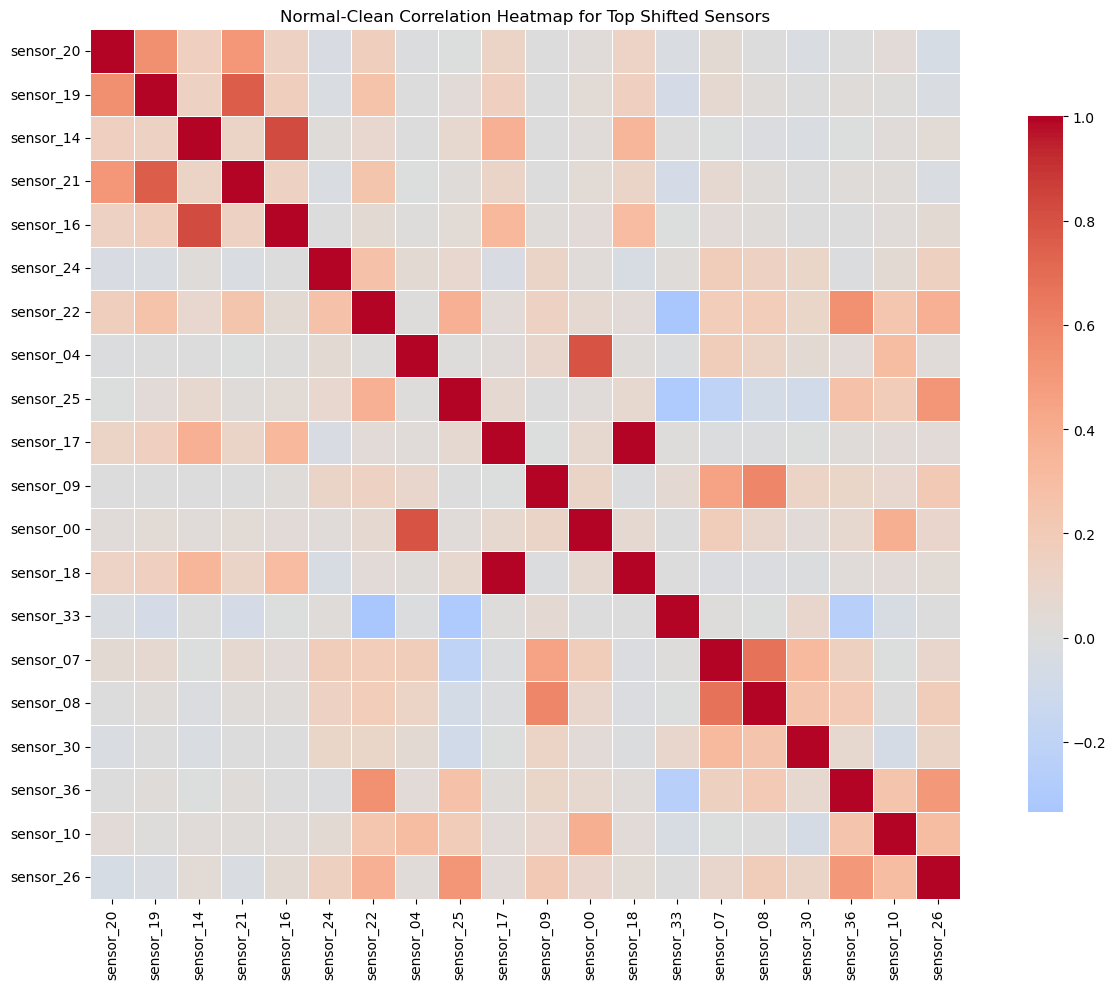

In [38]:
# =========================================================
# Correlation heatmap for top shifted sensors
# =========================================================

TOP_HEATMAP_SENSOR_COUNT = 20

top_shifted_sensors = (
    robust_state_compare_top_df["feature"]
    .dropna()
    .drop_duplicates()
    .head(TOP_HEATMAP_SENSOR_COUNT)
    .tolist()
)

if not top_shifted_sensors:
    print("No top shifted sensors found; skipping heatmap.")
else:
    top_shift_corr_matrix = correlation_matrix_normal_clean.loc[
        top_shifted_sensors, top_shifted_sensors
    ].copy()

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        top_shift_corr_matrix,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Normal-Clean Correlation Heatmap for Top Shifted Sensors")
    plt.tight_layout()
    plt.show()

## Build Top-Sensor Distribution Plots

### Ask

Why create distribution plots by profiled state?

### Answer

Distribution plots show how sensor values move across clean normal, contaminated normal, abnormal, and recovery states.

This helps me see whether a sensor shift is subtle, extreme, skewed, or state-specific.

## Build Timeline Plots for Shifted Sensors

### Ask

Why inspect selected sensors over time?

### Answer

Timeline plots show when important sensor changes happen.

This is useful because anomaly detection is not only about whether values differ, but also about when those differences appear relative to abnormal and recovery periods.

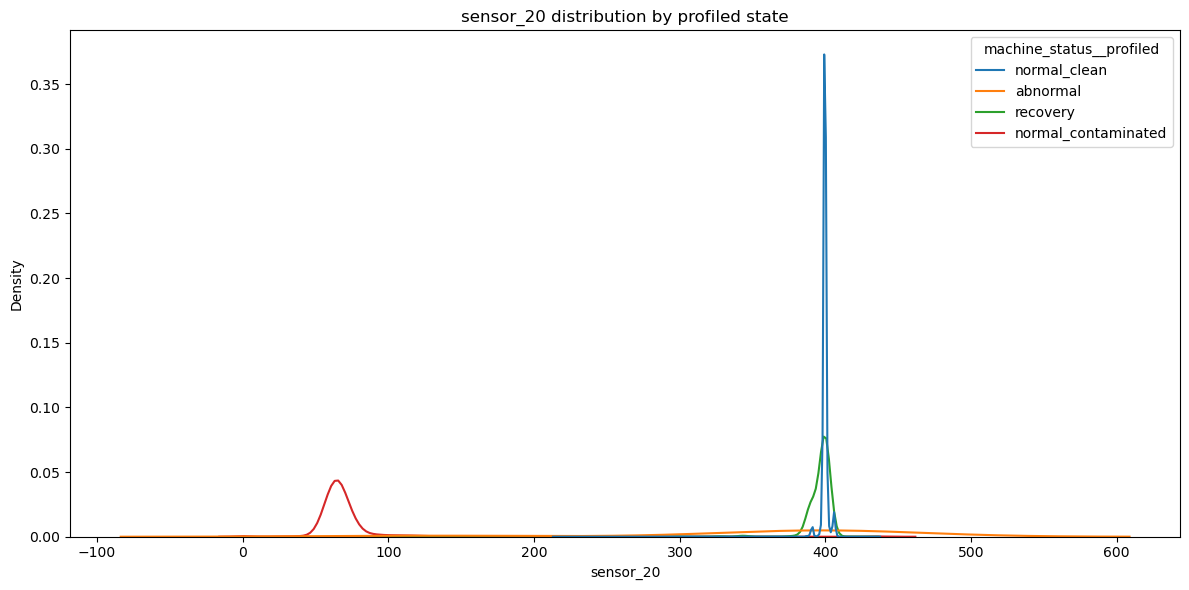

Saved: /workspace/artifacts/silver/pump/eda/distribution_plots/sensor_20__distribution_by_profiled_state.png


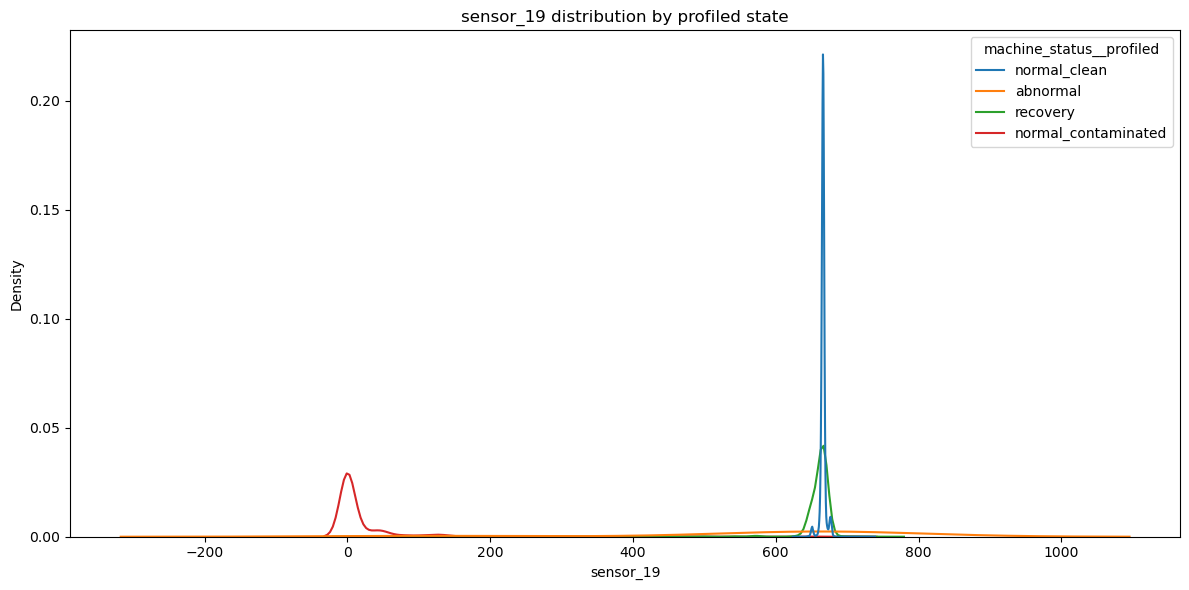

Saved: /workspace/artifacts/silver/pump/eda/distribution_plots/sensor_19__distribution_by_profiled_state.png


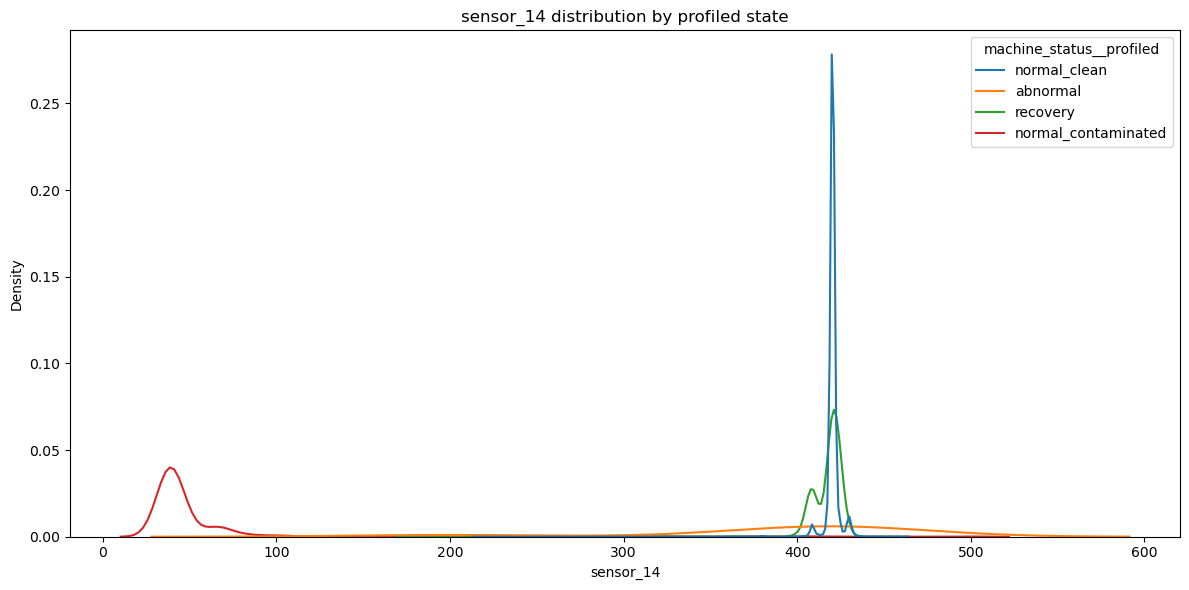

Saved: /workspace/artifacts/silver/pump/eda/distribution_plots/sensor_14__distribution_by_profiled_state.png


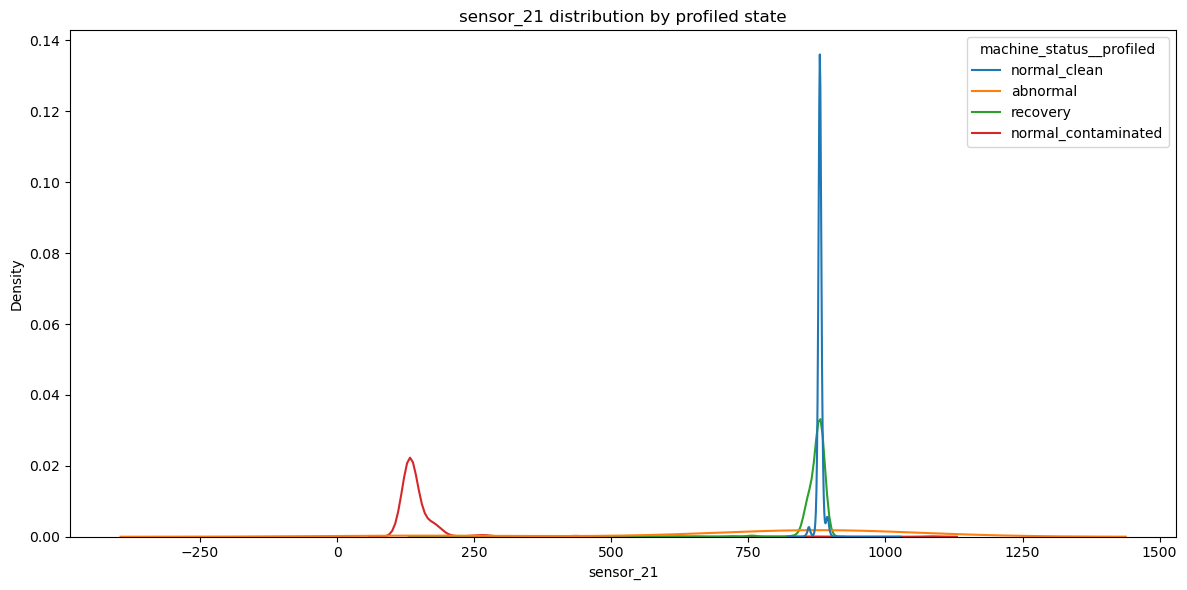

Saved: /workspace/artifacts/silver/pump/eda/distribution_plots/sensor_21__distribution_by_profiled_state.png


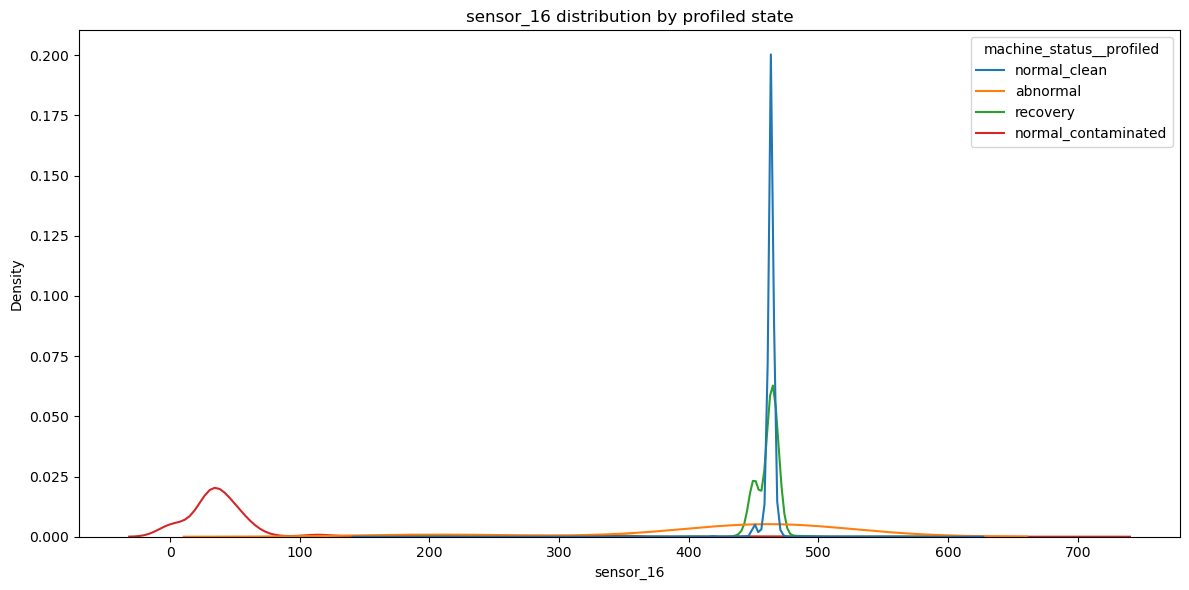

Saved: /workspace/artifacts/silver/pump/eda/distribution_plots/sensor_16__distribution_by_profiled_state.png


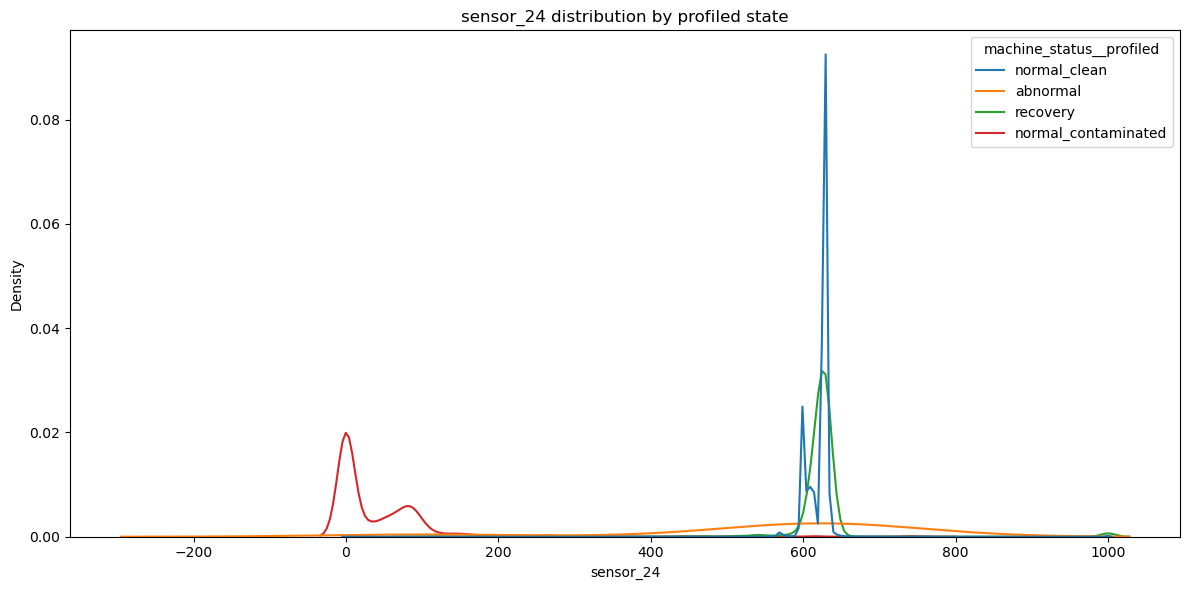

2026-06-02 15:48:58,816 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:48:58.816017+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'feature_distribution_comparisons', 'message': 'Built feature distribution comparison plots for top shifted sensors.', 'why': None, 'consequence': None, 'data': {'top_distribution_sensors': ['sensor_20', 'sensor_19', 'sensor_14', 'sensor_21', 'sensor_16', 'sensor_24']}}


Saved: /workspace/artifacts/silver/pump/eda/distribution_plots/sensor_24__distribution_by_profiled_state.png


{'ts_utc': '2026-06-02T15:48:58.816017+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'feature_distribution_comparisons',
 'message': 'Built feature distribution comparison plots for top shifted sensors.',
 'why': None,
 'consequence': None,
 'data': {'top_distribution_sensors': ['sensor_20',
   'sensor_19',
   'sensor_14',
   'sensor_21',
   'sensor_16',
   'sensor_24']}}

In [39]:
# =========================================================
# Feature distribution comparisons for top shifted sensors
# =========================================================

TOP_DISTRIBUTION_SENSOR_COUNT = 6

top_distribution_sensors = (
    robust_state_compare_top_df["feature"]
    .dropna()
    .drop_duplicates()
    .head(TOP_DISTRIBUTION_SENSOR_COUNT)
    .tolist()
)

if not top_distribution_sensors:
    print("No top shifted sensors found; skipping distribution plots.")
else:
    distribution_plot_dir = DISTRIBUTION_PLOT_DIR
    distribution_plot_dir.mkdir(parents=True, exist_ok=True)

    plot_states = [
        PROFILED_NORMAL_CLEAN_VALUE,
        PROFILED_NORMAL_CONTAMINATED_VALUE,
        PROFILED_ABNORMAL_VALUE,
        PROFILED_RECOVERY_VALUE,
    ]

    for sensor_col in top_distribution_sensors:
        plot_df = silver_eda_df[[STATE_COL_PROFILED, sensor_col]].copy()
        plot_df[sensor_col] = pd.to_numeric(plot_df[sensor_col], errors="coerce")
        plot_df = plot_df[plot_df[STATE_COL_PROFILED].isin(plot_states)].dropna(subset=[sensor_col])

        if plot_df.empty:
            continue

        plt.figure(figsize=(12, 6))
        sns.kdeplot(
            data=plot_df,
            x=sensor_col,
            hue=STATE_COL_PROFILED,
            common_norm=False,
            fill=False,
        )
        plt.title(f"{sensor_col} distribution by profiled state")
        plt.tight_layout()

        out_path = distribution_plot_dir / f"{sensor_col}__distribution_by_profiled_state.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

        print("Saved:", out_path)

ledger.add(
    kind="step",
    step="feature_distribution_comparisons",
    message="Built feature distribution comparison plots for top shifted sensors.",
    data={"top_distribution_sensors": top_distribution_sensors},
    logger=logger,
)

## Build Aligned Onset Windows

### Ask

Why align windows around anomaly onsets?

### Answer

Aligned onset windows let me compare how sensors behave before and after abnormal periods begin.

This helps identify whether changes start gradually before failure or appear suddenly near the abnormal label.

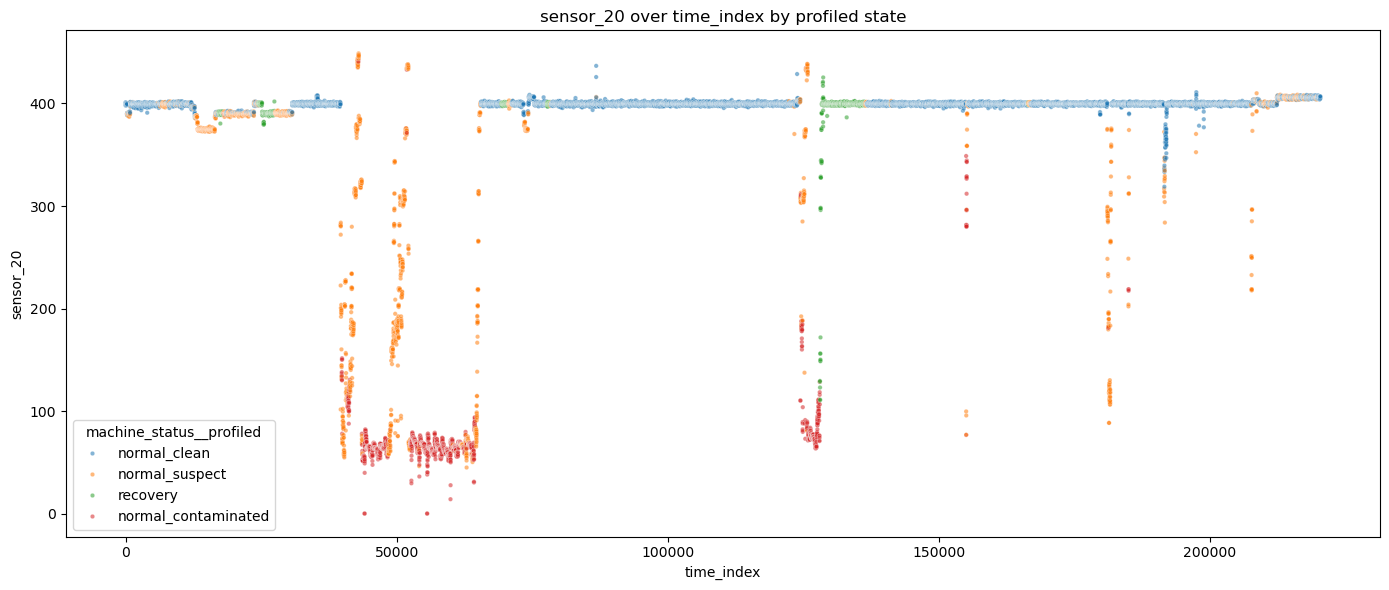

Saved: /workspace/artifacts/silver/pump/eda/timeline_overlays/sensor_20__timeline_overlay.png


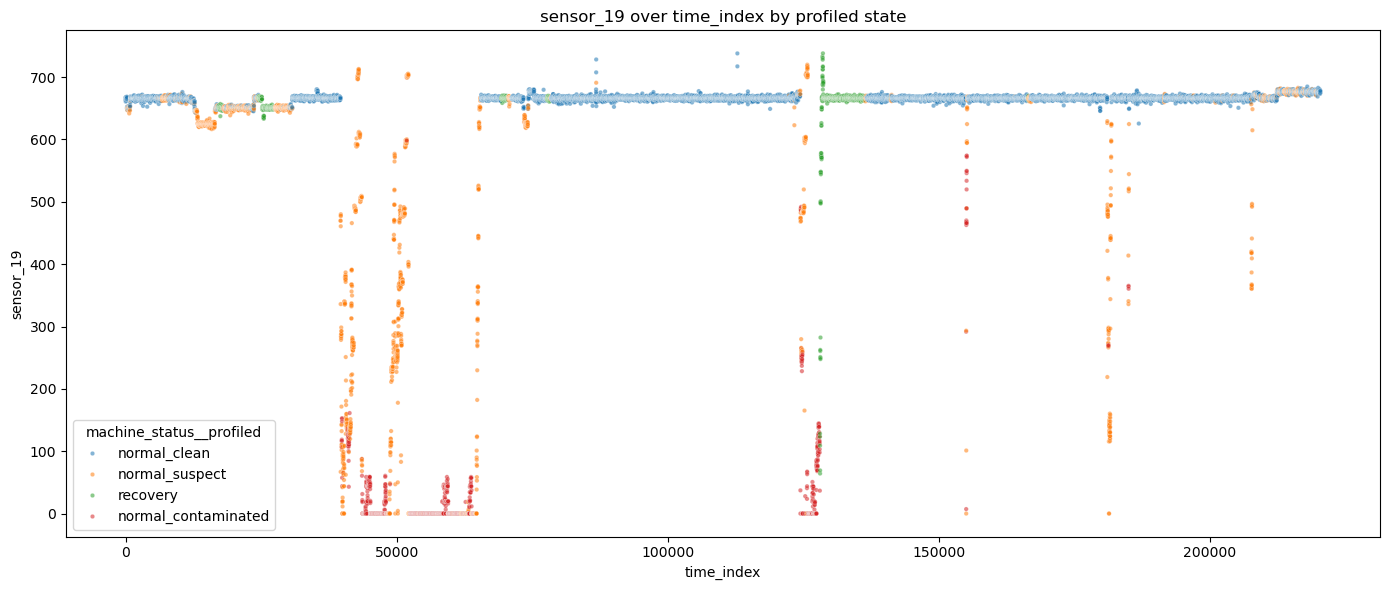

Saved: /workspace/artifacts/silver/pump/eda/timeline_overlays/sensor_19__timeline_overlay.png


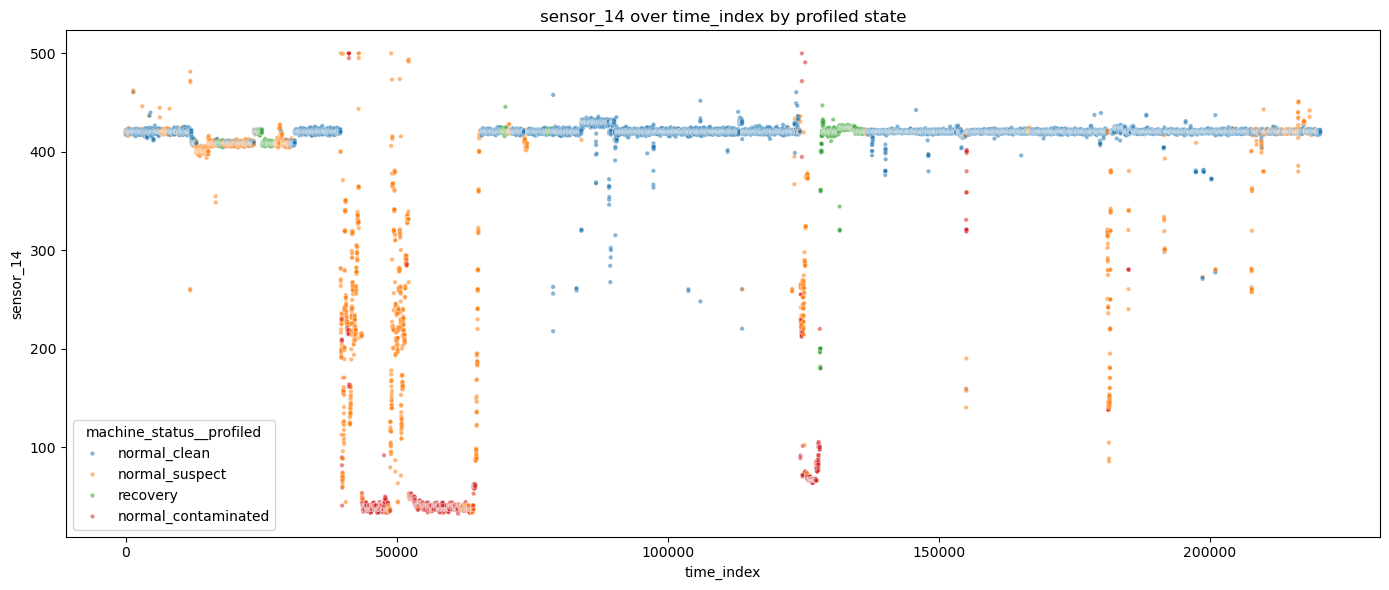

Saved: /workspace/artifacts/silver/pump/eda/timeline_overlays/sensor_14__timeline_overlay.png


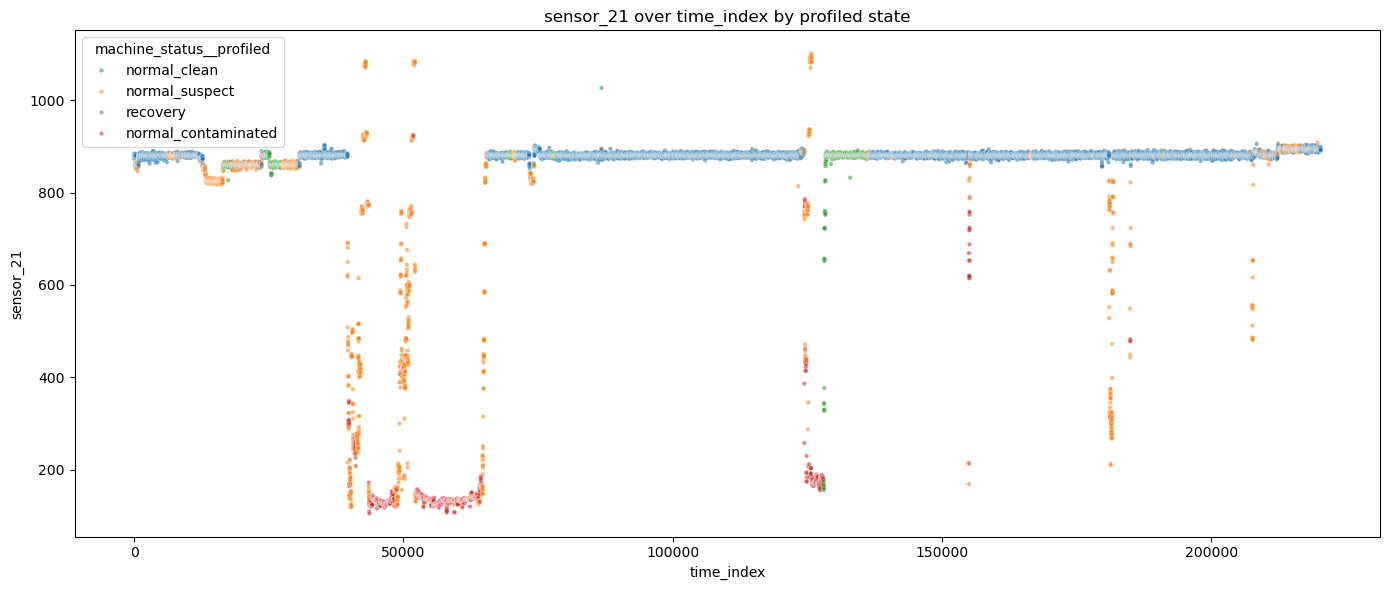

2026-06-02 15:49:08,576 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:08.576610+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'timeline_overlays', 'message': 'Built timeline overlay plots for top shifted sensors.', 'why': None, 'consequence': None, 'data': {'timeline_sensor_cols': ['sensor_20', 'sensor_19', 'sensor_14', 'sensor_21'], 'time_col': 'time_index'}}


Saved: /workspace/artifacts/silver/pump/eda/timeline_overlays/sensor_21__timeline_overlay.png


{'ts_utc': '2026-06-02T15:49:08.576610+00:00',
 'stage': 'silver_eda',
 'recipe': 'silver_eda__v001',
 'kind': 'step',
 'step': 'timeline_overlays',
 'message': 'Built timeline overlay plots for top shifted sensors.',
 'why': None,
 'consequence': None,
 'data': {'timeline_sensor_cols': ['sensor_20',
   'sensor_19',
   'sensor_14',
   'sensor_21'],
  'time_col': 'time_index'}}

In [40]:
# =========================================================
# Overlay top features across time
# =========================================================

TOP_TIMELINE_SENSOR_COUNT = 4

timeline_sensor_cols = (
    robust_state_compare_top_df["feature"]
    .dropna()
    .drop_duplicates()
    .head(TOP_TIMELINE_SENSOR_COUNT)
    .tolist()
)

time_col = "time_index" if "time_index" in silver_eda_df.columns else None
if time_col is None:
    for fallback_col in ["event_step", "event_time"]:
        if fallback_col in silver_eda_df.columns:
            time_col = fallback_col
            break

if time_col is None:
    print("No time/order column found; skipping overlay plots.")
else:
    timeline_plot_dir = TIMELINE_OVERLAY_DIR
    timeline_plot_dir.mkdir(parents=True, exist_ok=True)

    timeline_df = silver_eda_df.copy()

    # Keep plot size manageable
    if len(timeline_df) > 25000:
        timeline_df = timeline_df.sample(25000, random_state=42).copy()

    timeline_df = timeline_df.sort_values(time_col, kind="stable")

    for sensor_col in timeline_sensor_cols:
        if sensor_col not in timeline_df.columns:
            continue

        plot_df = timeline_df[[time_col, STATE_COL_PROFILED, sensor_col]].copy()
        plot_df[sensor_col] = pd.to_numeric(plot_df[sensor_col], errors="coerce")
        plot_df = plot_df.dropna(subset=[sensor_col])

        if plot_df.empty:
            continue

        plt.figure(figsize=(14, 6))
        sns.scatterplot(
            data=plot_df,
            x=time_col,
            y=sensor_col,
            hue=STATE_COL_PROFILED,
            s=10,
            alpha=0.55,
        )
        plt.title(f"{sensor_col} over {time_col} by profiled state")
        plt.tight_layout()

        out_path = timeline_plot_dir / f"{sensor_col}__timeline_overlay.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

        print("Saved:", out_path)

ledger.add(
    kind="step",
    step="timeline_overlays",
    message="Built timeline overlay plots for top shifted sensors.",
    data={"timeline_sensor_cols": timeline_sensor_cols, "time_col": time_col},
    logger=logger,
)

In [41]:
# =========================================================
# Detect abnormal onsets and build aligned window rows
# =========================================================

ALIGN_PRE_STEPS = 50
ALIGN_POST_STEPS = 50

if "meta__episode_id" not in silver_eda_df.columns:
    print("No meta__episode_id column found; skipping onset alignment.")
else:
    if time_col is None:
        print("No order/time column found; skipping onset alignment.")
    else:
        #aligned_rows: list[dict[str, Any]] = []
        aligned_rows: list[pd.DataFrame] = []

        work_df = silver_eda_df.copy()
        work_df = work_df.sort_values(["meta__episode_id", time_col], kind="stable").reset_index(drop=False)
        original_index_col = "index"

        for episode_value, episode_df in work_df.groupby("meta__episode_id", sort=False):
            episode_df = episode_df.reset_index(drop=True).copy()

            abnormal_positions = np.flatnonzero(
                episode_df[STATE_COL_PROFILED].eq(PROFILED_ABNORMAL_VALUE).to_numpy()
            )

            if len(abnormal_positions) == 0:
                continue

            first_abnormal_pos = int(abnormal_positions[0])

            start_pos = max(0, first_abnormal_pos - ALIGN_PRE_STEPS)
            end_pos = min(len(episode_df), first_abnormal_pos + ALIGN_POST_STEPS + 1)

            window_df = episode_df.iloc[start_pos:end_pos].copy()
            window_df["aligned_step"] = np.arange(start_pos, end_pos) - first_abnormal_pos
            window_df["onset_episode_id"] = episode_value
            window_df["abnormal_onset_position"] = first_abnormal_pos

            aligned_rows.append(window_df)

        if aligned_rows:
            #aligned_onset_df = pd.concat(aligned_rows, axis=0, ignore_index=True)
            #aligned_onset_df = pd.DataFrame(aligned_rows).reset_index(drop=True)
            aligned_onset_df = pd.concat(
                cast(list[pd.DataFrame], aligned_rows),
                axis=0,
                ignore_index=True,
            )
        else:
            aligned_onset_df = pd.DataFrame()

        ledger.add(
            kind="step",
            step="aligned_onset_windows",
            message="Built abnormal-onset aligned windows.",
            data={
                "aligned_onset_shape": list(aligned_onset_df.shape) if not aligned_onset_df.empty else [0, 0],
                "align_pre_steps": ALIGN_PRE_STEPS,
                "align_post_steps": ALIGN_POST_STEPS,
            },
            logger=logger,
        )

        display(aligned_onset_df.head(10))

2026-06-02 15:49:14,010 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:14.009925+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'aligned_onset_windows', 'message': 'Built abnormal-onset aligned windows.', 'why': None, 'consequence': None, 'data': {'aligned_onset_shape': [698, 343], 'align_pre_steps': 50, 'align_post_steps': 50}}


,index,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,timestamp,machine_status,machine_status__synthetic,__status_group,__is_normal_candidate,__normal_episode_id,__keep_after_episode_trim,__window_id,sensor_00__value_deviation,sensor_00__delta_deviation,sensor_00__value_abnormal_flag,sensor_00__delta_abnormal_flag,sensor_00__any_abnormal_flag,sensor_01__value_deviation,sensor_01__delta_deviation,sensor_01__value_abnormal_flag,sensor_01__delta_abnormal_flag,sensor_01__any_abnormal_flag,sensor_02__value_deviation,sensor_02__delta_deviation,sensor_02__value_abnormal_flag,sensor_02__delta_abnormal_flag,sensor_02__any_abnormal_flag,sensor_03__value_deviation,sensor_03__delta_deviation,sensor_03__value_abnormal_flag,sensor_03__delta_abnormal_flag,sensor_03__any_abnormal_flag,...,sensor_33__delta_abnormal_flag,sensor_33__any_abnormal_flag,sensor_34__value_deviation,sensor_34__delta_deviation,sensor_34__value_abnormal_flag,sensor_34__delta_abnormal_flag,sensor_34__any_abnormal_flag,sensor_35__value_deviation,sensor_35__delta_deviation,sensor_35__value_abnormal_flag,sensor_35__delta_abnormal_flag,sensor_35__any_abnormal_flag,sensor_36__value_deviation,sensor_36__delta_deviation,sensor_36__value_abnormal_flag,sensor_36__delta_abnormal_flag,sensor_36__any_abnormal_flag,sensor_37__value_deviation,sensor_37__delta_deviation,sensor_37__value_abnormal_flag,sensor_37__delta_abnormal_flag,sensor_37__any_abnormal_flag,sensor_38__value_deviation,sensor_38__delta_deviation,sensor_38__value_abnormal_flag,sensor_38__delta_abnormal_flag,sensor_38__any_abnormal_flag,sensor_39__value_deviation,sensor_39__delta_deviation,sensor_39__value_abnormal_flag,sensor_39__delta_abnormal_flag,sensor_39__any_abnormal_flag,sensor_40__value_deviation,sensor_40__delta_deviation,sensor_40__value_abnormal_flag,sensor_40__delta_abnormal_flag,sensor_40__any_abnormal_flag,sensor_41__value_deviation,sensor_41__delta_deviation,sensor_41__value_abnormal_flag,sensor_41__delta_abnormal_flag,sensor_41__any_abnormal_flag,sensor_42__value_deviation,sensor_42__delta_deviation,sensor_42__value_abnormal_flag,sensor_42__delta_abnormal_flag,sensor_42__any_abnormal_flag,sensor_43__value_deviation,sensor_43__delta_deviation,sensor_43__value_abnormal_flag,sensor_43__delta_abnormal_flag,sensor_43__any_abnormal_flag,sensor_44__value_deviation,sensor_44__delta_deviation,sensor_44__value_abnormal_flag,sensor_44__delta_abnormal_flag,sensor_44__any_abnormal_flag,sensor_45__value_deviation,sensor_45__delta_deviation,sensor_45__value_abnormal_flag,sensor_45__delta_abnormal_flag,sensor_45__any_abnormal_flag,sensor_46__value_deviation,sensor_46__delta_deviation,sensor_46__value_abnormal_flag,sensor_46__delta_abnormal_flag,sensor_46__any_abnormal_flag,sensor_47__value_deviation,sensor_47__delta_deviation,sensor_47__value_abnormal_flag,sensor_47__delta_abnormal_flag,sensor_47__any_abnormal_flag,sensor_48__value_deviation,sensor_48__delta_deviation,sensor_48__value_abnormal_flag,sensor_48__delta_abnormal_flag,sensor_48__any_abnormal_flag,sensor_49__value_deviation,sensor_49__delta_deviation,sensor_49__value_abnormal_flag,sensor_49__delta_abnormal_flag,sensor_49__any_abnormal_flag,sensor_51__value_deviation,sensor_51__delta_deviation,sensor_5

In [42]:
# =========================================================
# Cluster numeric features by correlation distance
# =========================================================

FEATURE_CLUSTER_COUNT = 8

if correlation_matrix_normal_clean.empty:
    print("Normal-clean correlation matrix is empty; skipping feature clustering.")
else:
    corr_for_cluster = correlation_matrix_normal_clean.copy().fillna(0.0)
    distance_matrix = 1.0 - corr_for_cluster.abs()

    # Agglomerative clustering on the precomputed distance matrix
    if len(distance_matrix.columns) < 2:
        print("Not enough features for clustering.")
        feature_cluster_map_df = pd.DataFrame()
    else:
        clustering_model = AgglomerativeClustering(
            n_clusters=min(FEATURE_CLUSTER_COUNT, len(distance_matrix.columns)),
            metric="precomputed",
            linkage="average",
        )

        cluster_labels = clustering_model.fit_predict(distance_matrix.values)

        feature_cluster_map_df = pd.DataFrame(
            {
                "feature": distance_matrix.index.tolist(),
                "feature_cluster": [f"cluster_{int(x):02d}" for x in cluster_labels],
            }
        ).sort_values(["feature_cluster", "feature"]).reset_index(drop=True)

        feature_cluster_map_path = (
            CORRELATION_ARTIFACT_DIR / "feature_cluster_map_normal_clean.csv"
        )
        feature_cluster_map_df.to_csv(feature_cluster_map_path, index=False)

        ledger.add(
            kind="step",
            step="feature_clustering",
            message="Clustered features by normal-clean correlation distance.",
            data={
                "feature_cluster_count": int(feature_cluster_map_df["feature_cluster"].nunique()),
                "feature_cluster_map_path": str(feature_cluster_map_path),
            },
            logger=logger,
        )

        print("Saved:", feature_cluster_map_path)
        display(feature_cluster_map_df.head(30))

2026-06-02 15:49:14,270 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:14.270847+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'feature_clustering', 'message': 'Clustered features by normal-clean correlation distance.', 'why': None, 'consequence': None, 'data': {'feature_cluster_count': 8, 'feature_cluster_map_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/feature_cluster_map_normal_clean.csv'}}


Saved: /workspace/artifacts/silver/pump/eda/correlation_analysis/feature_cluster_map_normal_clean.csv


,feature,feature_cluster
0,sensor_05,cluster_00
1,sensor_06,cluster_00
2,sensor_07,cluster_00
3,sensor_08,cluster_00
4,sensor_09,cluster_00
5,sensor_10,cluster_00
6,sensor_11,cluster_00
7,sensor_12,cluster_00
8,sensor_13,cluster_00
9,sensor_22,cluster_00


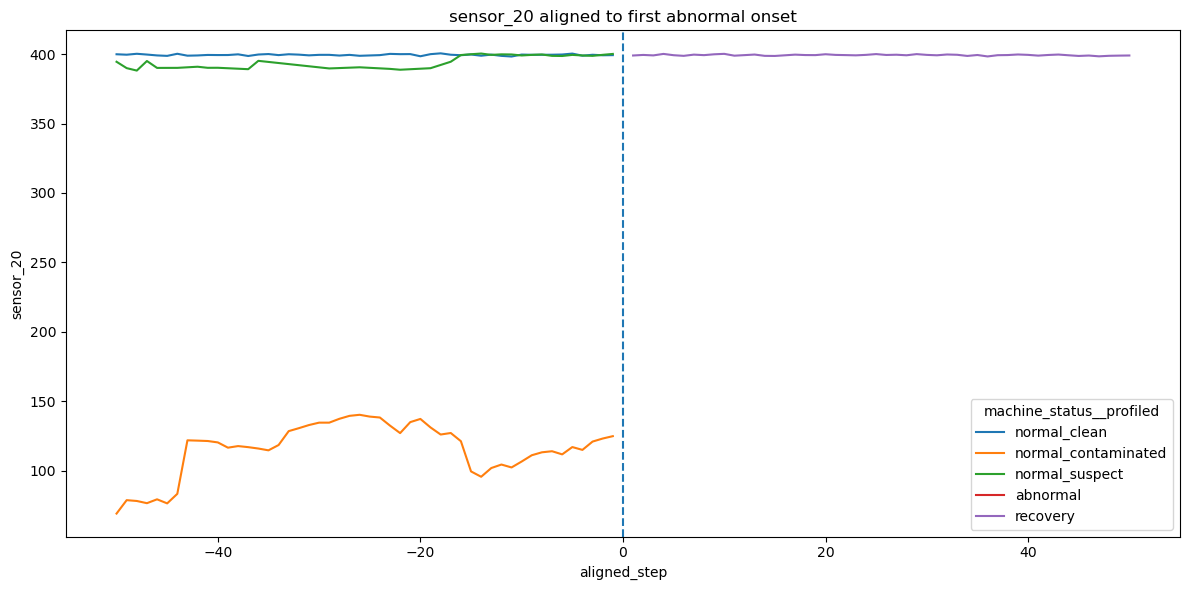

Saved: /workspace/artifacts/silver/pump/eda/aligned_onset_plots/sensor_20__aligned_onset_median_curve.png


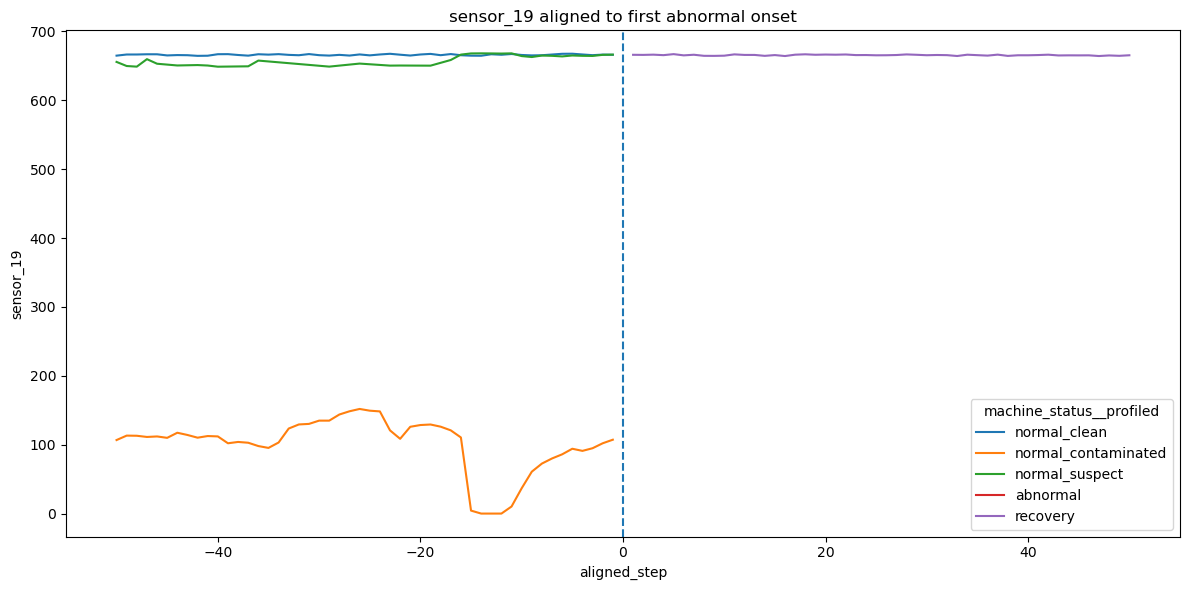

Saved: /workspace/artifacts/silver/pump/eda/aligned_onset_plots/sensor_19__aligned_onset_median_curve.png


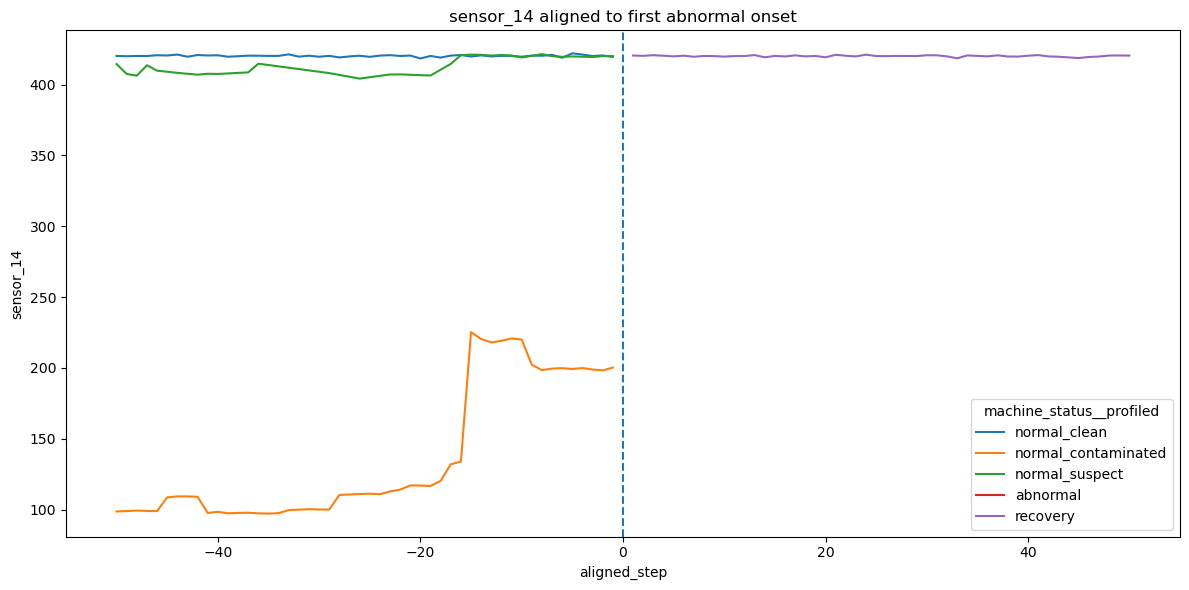

Saved: /workspace/artifacts/silver/pump/eda/aligned_onset_plots/sensor_14__aligned_onset_median_curve.png


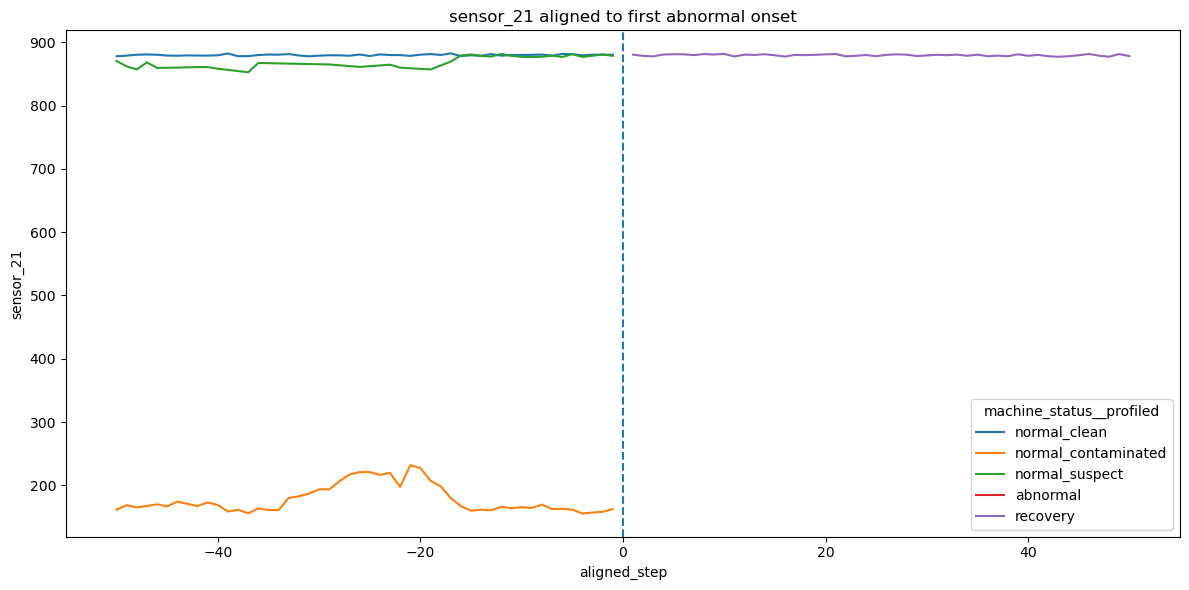

2026-06-02 15:49:17,224 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:17.224905+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'aligned_onset_sensor_curves', 'message': 'Built aligned onset median-curve plots for top shifted sensors.', 'why': None, 'consequence': None, 'data': {'aligned_sensor_cols': ['sensor_20', 'sensor_19', 'sensor_14', 'sensor_21']}}


Saved: /workspace/artifacts/silver/pump/eda/aligned_onset_plots/sensor_21__aligned_onset_median_curve.png


In [43]:
# =========================================================
# Aligned anomaly-onset sensor median curves
# =========================================================

if "aligned_onset_df" not in globals() or aligned_onset_df.empty:
    print("No aligned onset dataframe found; skipping aligned median curves.")
else:
    aligned_plot_dir = ALIGNED_ONSET_PLOT_DIR
    aligned_plot_dir.mkdir(parents=True, exist_ok=True)

    aligned_sensor_cols = (
        robust_state_compare_top_df["feature"]
        .dropna()
        .drop_duplicates()
        .head(4)
        .tolist()
    )

    for sensor_col in aligned_sensor_cols:
        plot_df = aligned_onset_df[["aligned_step", STATE_COL_PROFILED, sensor_col]].copy()
        plot_df[sensor_col] = pd.to_numeric(plot_df[sensor_col], errors="coerce")
        plot_df = plot_df.dropna(subset=[sensor_col])

        if plot_df.empty:
            continue

        summary_df = (
            plot_df.groupby(["aligned_step", STATE_COL_PROFILED], dropna=False)[sensor_col]
            .median()
            .reset_index()
        )

        plt.figure(figsize=(12, 6))
        sns.lineplot(
            data=summary_df,
            x="aligned_step",
            y=sensor_col,
            hue=STATE_COL_PROFILED,
        )
        plt.axvline(0, linestyle="--")
        plt.title(f"{sensor_col} aligned to first abnormal onset")
        plt.tight_layout()

        out_path = aligned_plot_dir / f"{sensor_col}__aligned_onset_median_curve.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

        print("Saved:", out_path)

    ledger.add(
        kind="step",
        step="aligned_onset_sensor_curves",
        message="Built aligned onset median-curve plots for top shifted sensors.",
        data={"aligned_sensor_cols": aligned_sensor_cols},
        logger=logger,
    )

## Run PCA Diagnostics

### Ask

Why include PCA in Silver EDA?

### Answer

PCA gives me a compact way to inspect whether profiled states separate in a lower-dimensional feature space.

I am not using PCA as the final model here. I am using it as an exploratory diagnostic to see whether clean normal, contaminated normal, abnormal, and recovery rows show meaningful structure.

2026-06-02 15:49:17,670 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:17.669975+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'pca_build', 'message': 'Built PCA projection for profiled states.', 'why': None, 'consequence': None, 'data': {'pca_sample_n': 20000, 'pca_explained_variance_ratio': [0.8565777797824984, 0.10767776278522838], 'pca_scaler': 'robust'}}


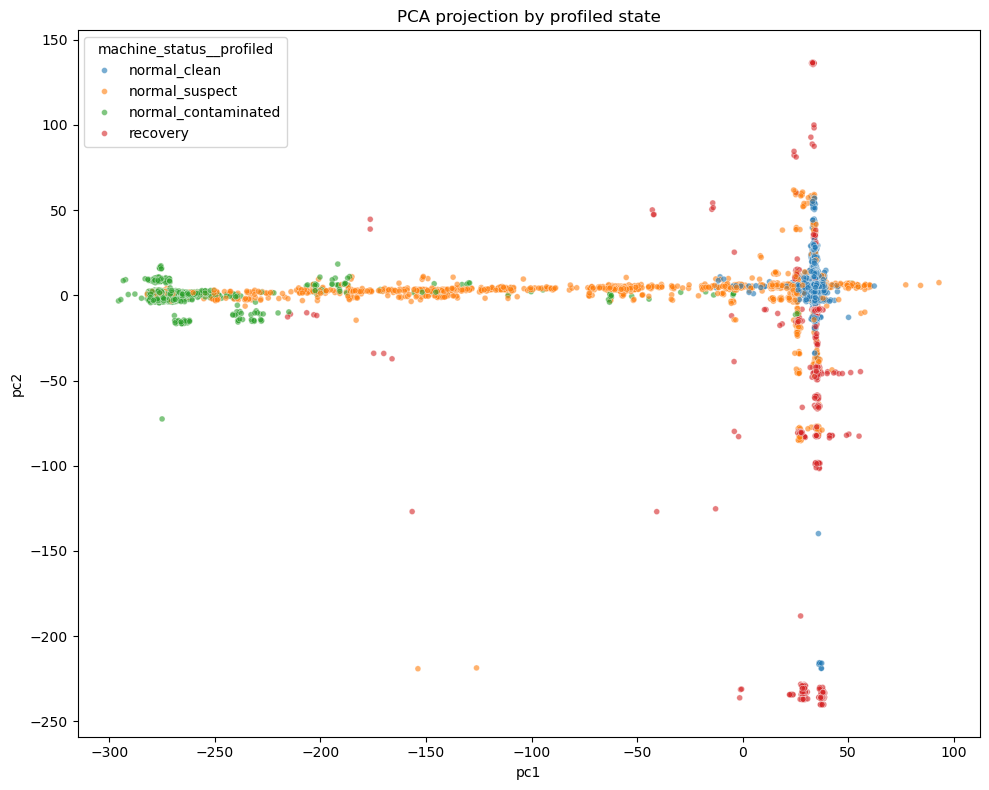

In [44]:
# =========================================================
# PCA build
# =========================================================

PCA_SAMPLE_N = 20000
PCA_N_COMPONENTS = 2
PCA_SCALER = "robust"   # "robust" or "standard"

pca_source_df = silver_eda_df[[STATE_COL_PROFILED] + FEATURE_COLUMNS].copy()

if len(pca_source_df) > PCA_SAMPLE_N:
    pca_source_df = pca_source_df.sample(PCA_SAMPLE_N, random_state=42).copy()

X_pca = pca_source_df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")

# Median impute for PCA prep
X_pca = X_pca.fillna(X_pca.median(numeric_only=True))

if PCA_SCALER == "standard":
    scaler = StandardScaler()
else:
    scaler = RobustScaler()

X_scaled = scaler.fit_transform(X_pca)

pca_model = PCA(n_components=PCA_N_COMPONENTS, random_state=42)
X_pca_components = pca_model.fit_transform(X_scaled)

pca_plot_df = pca_source_df[[STATE_COL_PROFILED]].copy()
pca_plot_df["pc1"] = X_pca_components[:, 0]
pca_plot_df["pc2"] = X_pca_components[:, 1]

ledger.add(
    kind="step",
    step="pca_build",
    message="Built PCA projection for profiled states.",
    data={
        "pca_sample_n": int(len(pca_plot_df)),
        "pca_explained_variance_ratio": pca_model.explained_variance_ratio_.tolist(),
        "pca_scaler": PCA_SCALER,
    },
    logger=logger,
)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_plot_df,
    x="pc1",
    y="pc2",
    hue=STATE_COL_PROFILED,
    s=18,
    alpha=0.6,
)
plt.title("PCA projection by profiled state")
plt.tight_layout()
plt.show()

In [45]:
# =========================================================
# PCA diagnostics
# =========================================================

pca_explained_variance_df = pd.DataFrame(
    {
        "component": [f"PC{i+1}" for i in range(len(pca_model.explained_variance_ratio_))],
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(pca_model.explained_variance_ratio_),
    }
)

loading_df = pd.DataFrame(
    pca_model.components_.T,
    index=FEATURE_COLUMNS,
    columns=[f"PC{i+1}" for i in range(pca_model.n_components_)],
).reset_index(names="feature")

loading_df["pc1_abs_loading"] = loading_df["PC1"].abs()
loading_df["pc2_abs_loading"] = loading_df["PC2"].abs()
loading_df["max_abs_loading"] = loading_df[["pc1_abs_loading", "pc2_abs_loading"]].max(axis=1)
loading_df = loading_df.sort_values("max_abs_loading", ascending=False).reset_index(drop=True)

pca_diag_dir = PCA_ARTIFACT_DIR
pca_diag_dir.mkdir(parents=True, exist_ok=True)

pca_explained_variance_path = pca_diag_dir / "pca_explained_variance.csv"
pca_loading_path = pca_diag_dir / "pca_feature_loadings.csv"

pca_explained_variance_df.to_csv(pca_explained_variance_path, index=False)
loading_df.to_csv(pca_loading_path, index=False)

ledger.add(
    kind="step",
    step="pca_diagnostics",
    message="Built PCA diagnostics and saved loadings.",
    data={
        "pca_explained_variance_path": str(pca_explained_variance_path),
        "pca_loading_path": str(pca_loading_path),
        "top_pca_features": loading_df.head(15).to_dict(orient="records"),
    },
    logger=logger,
)

print("Saved:", pca_explained_variance_path)
print("Saved:", pca_loading_path)
display(pca_explained_variance_df)
display(loading_df.head(20))

2026-06-02 15:49:18,577 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:18.577551+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'pca_diagnostics', 'message': 'Built PCA diagnostics and saved loadings.', 'why': None, 'consequence': None, 'data': {'pca_explained_variance_path': '/workspace/artifacts/silver/pump/eda/pca/pca_explained_variance.csv', 'pca_loading_path': '/workspace/artifacts/silver/pump/eda/pca/pca_feature_loadings.csv', 'top_pca_features': [{'feature': 'sensor_09', 'PC1': -0.011477845195021215, 'PC2': 0.9572665988411699, 'pc1_abs_loading': 0.011477845195021215, 'pc2_abs_loading': 0.9572665988411699, 'max_abs_loading': 0.9572665988411699}, {'feature': 'sensor_20', 'PC1': 0.5509816227716877, 'PC2': 0.00817609439400937, 'pc1_abs_loading': 0.5509816227716877, 'pc2_abs_loading': 0.00817609439400937, 'max_abs_loading': 0.5509816227716877}, {'feature': 'sensor_19', 'PC1': 0.5079637538173013, 'PC2': 0.00554230732

Saved: /workspace/artifacts/silver/pump/eda/pca/pca_explained_variance.csv
Saved: /workspace/artifacts/silver/pump/eda/pca/pca_feature_loadings.csv


,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,PC1,0.856578,0.856578
1,PC2,0.107678,0.964256


,feature,PC1,PC2,pc1_abs_loading,pc2_abs_loading,max_abs_loading
0,sensor_09,-0.011478,0.957267,0.011478,0.957267,0.957267
1,sensor_20,0.550982,0.008176,0.550982,0.008176,0.550982
2,sensor_19,0.507964,0.005542,0.507964,0.005542,0.507964
3,sensor_14,0.438194,0.005022,0.438194,0.005022,0.438194
4,sensor_21,0.379224,0.006970,0.379224,0.006970,0.379224
5,sensor_16,0.279654,0.003920,0.279654,0.003920,0.279654
6,sensor_04,-0.010209,0.228558,0.010209,0.228558,0.228558
7,sensor_07,-0.001396,0.105084,0.001396,0.105084,0.105084
8,sensor_17,0.102949,0.002992,0.102949,0.002992,0.102949
9,sensor_08,-0.000898,0.089822,0.000898,0.089822,0.089822


## Compare Imputation Behavior

### Ask

Why test imputation during EDA?

### Answer

Gold preprocessing will need to handle missing values, so this notebook checks how imputation choices behave on the profiled feature set.

This helps validate whether the missing-value strategy is reasonable before it becomes part of the modeling workflow.

In [46]:
# =========================================================
# Imputation comparison
# =========================================================

IMPUTE_COMPARE_SAMPLE_N = 10000

impute_df = silver_eda_df[FEATURE_COLUMNS].copy()
if len(impute_df) > IMPUTE_COMPARE_SAMPLE_N:
    impute_df = impute_df.sample(IMPUTE_COMPARE_SAMPLE_N, random_state=42).copy()

impute_df = impute_df.apply(pd.to_numeric, errors="coerce")

# Strategy 1: median impute
median_imputed_df = impute_df.fillna(impute_df.median(numeric_only=True))

# Strategy 2: forward fill within row order, then backfill, then median fallback
if "meta__episode_id" in silver_eda_df.columns and time_col is not None:
    impute_source_with_keys = silver_eda_df[["meta__episode_id", time_col] + FEATURE_COLUMNS].copy()
    if len(impute_source_with_keys) > IMPUTE_COMPARE_SAMPLE_N:
        impute_source_with_keys = impute_source_with_keys.sample(IMPUTE_COMPARE_SAMPLE_N, random_state=42).copy()

    impute_source_with_keys = impute_source_with_keys.sort_values(["meta__episode_id", time_col], kind="stable")

    ffill_df = impute_source_with_keys.copy()
    ffill_df[FEATURE_COLUMNS] = ffill_df.groupby("meta__episode_id")[FEATURE_COLUMNS].ffill()
    ffill_df[FEATURE_COLUMNS] = ffill_df.groupby("meta__episode_id")[FEATURE_COLUMNS].bfill()
    ffill_df[FEATURE_COLUMNS] = ffill_df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
    ffill_imputed_df = ffill_df[FEATURE_COLUMNS].fillna(ffill_df[FEATURE_COLUMNS].median(numeric_only=True))
else:
    ffill_imputed_df = impute_df.fillna(method="ffill").fillna(method="bfill")
    ffill_imputed_df = ffill_imputed_df.fillna(ffill_imputed_df.median(numeric_only=True))

impute_compare_rows = []

for feature_col in FEATURE_COLUMNS:
    original_s = pd.to_numeric(impute_df[feature_col], errors="coerce")
    median_s = pd.to_numeric(median_imputed_df[feature_col], errors="coerce")
    ffill_s = pd.to_numeric(ffill_imputed_df[feature_col], errors="coerce")

    impute_compare_rows.append(
        {
            "feature": feature_col,
            "original_missing_pct": float(original_s.isna().mean()),
            "original_mean": float(original_s.mean()) if original_s.notna().any() else np.nan,
            "median_imputed_mean": float(median_s.mean()) if median_s.notna().any() else np.nan,
            "ffill_imputed_mean": float(ffill_s.mean()) if ffill_s.notna().any() else np.nan,
            "original_std": float(original_s.std(ddof=1)) if original_s.notna().sum() > 1 else np.nan,
            "median_imputed_std": float(median_s.std(ddof=1)) if median_s.notna().sum() > 1 else np.nan,
            "ffill_imputed_std": float(ffill_s.std(ddof=1)) if ffill_s.notna().sum() > 1 else np.nan,
        }
    )

imputation_compare_df = pd.DataFrame(impute_compare_rows)

imputation_compare_df["median_mean_shift"] = (
    imputation_compare_df["median_imputed_mean"] - imputation_compare_df["original_mean"]
)
imputation_compare_df["ffill_mean_shift"] = (
    imputation_compare_df["ffill_imputed_mean"] - imputation_compare_df["original_mean"]
)

imputation_compare_df["median_std_shift"] = (
    imputation_compare_df["median_imputed_std"] - imputation_compare_df["original_std"]
)
imputation_compare_df["ffill_std_shift"] = (
    imputation_compare_df["ffill_imputed_std"] - imputation_compare_df["original_std"]
)

imputation_compare_df = imputation_compare_df.sort_values(
    "original_missing_pct",
    ascending=False,
).reset_index(drop=True)

imputation_compare_path = SILVER_EDA_ARTIFACT_DIR / "imputation_compare_summary.csv"
imputation_compare_df.to_csv(imputation_compare_path, index=False)

ledger.add(
    kind="step",
    step="imputation_comparison",
    message="Built imputation comparison summary.",
    data={
        "imputation_compare_path": str(imputation_compare_path),
        "top_imputation_compare_rows": imputation_compare_df.head(20).to_dict(orient="records"),
    },
    logger=logger,
)

print("Saved:", imputation_compare_path)
display(imputation_compare_df.head(25))

2026-06-02 15:49:19,293 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:19.293926+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'imputation_comparison', 'message': 'Built imputation comparison summary.', 'why': None, 'consequence': None, 'data': {'imputation_compare_path': '/workspace/artifacts/silver/pump/eda/imputation_compare_summary.csv', 'top_imputation_compare_rows': [{'feature': 'sensor_51', 'original_missing_pct': 0.0714, 'original_mean': 201.16092250568406, 'median_imputed_mean': 200.84664665877818, 'ffill_imputed_mean': 258.1980326387782, 'original_std': 103.30585384371147, 'median_imputed_std': 99.55561267386437, 'ffill_imputed_std': 228.52681962647404, 'median_mean_shift': -0.31427584690587196, 'ffill_mean_shift': 57.03711013309416, 'median_std_shift': -3.7502411698471008, 'ffill_std_shift': 125.22096578276256}, {'feature': 'sensor_00', 'original_missing_pct': 0.0443, 'original_mean': 2.3712088642318196, '

Saved: /workspace/artifacts/silver/pump/eda/imputation_compare_summary.csv


,feature,original_missing_pct,original_mean,median_imputed_mean,ffill_imputed_mean,original_std,median_imputed_std,ffill_imputed_std,median_mean_shift,ffill_mean_shift,median_std_shift,ffill_std_shift
0,sensor_51,0.0714,201.160923,200.846647,258.198033,103.305854,99.555613,228.526820,-0.314276,5.703711e+01,-3.750241,1.252210e+02
1,sensor_00,0.0443,2.371209,2.374989,2.305874,0.411621,0.402782,0.560414,0.003780,-6.533439e-02,-0.008839,1.487929e-01
2,sensor_07,0.0246,15.869633,15.876962,15.851472,2.080436,2.055203,2.124066,0.007328,-1.816138e-02,-0.025233,4.362998e-02
3,sensor_08,0.0213,15.199090,15.205388,14.898488,2.015490,1.994365,2.874500,0.006298,-3.006011e-01,-0.021126,8.590097e-01
4,sensor_06,0.0206,13.509426,13.512176,13.232315,2.125216,2.103296,2.841929,0.002750,-2.771107e-01,-0.021920,7.167125e-01
5,sensor_09,0.0195,14.807217,14.812585,14.545701,2.030308,2.010774,2.801939,0.005367,-2.615163e-01,-0.019535,7.716304e-01
6,sensor_01,0.0011,47.626963,47.627520,47.632212,3.282060,3.280298,3.285211,0.000557,5.249225e-03,-0.001763,3.150369e-03
7,sensor_30,0.0008,614.493775,614.537365,614.079958,195.463339,195.391203,195.931761,0.043590,-4.138172e-01,-0.072135,4.684224e-01
8,sensor_32,0.0003,805.949231,805.971244,806.195446,261.587842,261.551684,261.981436,0.022013,2.462141e-01,-0.036158,3.935940e-01
9,sensor_22,0.0002,460.212441,460.226773,460.129900,154.011090,153.999020,154.106242,0.014331,-8.254197e-02,-0.012070,9.515244e-02


## Run Outlier Audit by Profiled State

### Ask

Why audit outliers by profiled state?

### Answer

Outliers may have different meanings depending on whether they appear in clean normal, contaminated normal, abnormal, or recovery rows.

This audit helps separate ordinary sensor variation from behavior that may be tied to fault development or recovery.

In [47]:
# =========================================================
# Outlier audit (downstream confirmation, not primary cleaner)
# =========================================================

OUTLIER_AUDIT_SAMPLE_N = 20000
OUTLIER_CONTAMINATION = 0.05

outlier_df = silver_eda_df[[STATE_COL_PROFILED] + FEATURE_COLUMNS].copy()

# Train only on normal_clean
train_outlier_df = outlier_df.loc[mask_profiled_normal_clean, FEATURE_COLUMNS].copy()
train_outlier_df = train_outlier_df.apply(pd.to_numeric, errors="coerce")
train_outlier_df = train_outlier_df.fillna(train_outlier_df.median(numeric_only=True))

score_outlier_df = outlier_df.copy()
score_outlier_features = score_outlier_df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
score_outlier_features = score_outlier_features.fillna(score_outlier_features.median(numeric_only=True))

if len(train_outlier_df) > OUTLIER_AUDIT_SAMPLE_N:
    train_outlier_df = train_outlier_df.sample(OUTLIER_AUDIT_SAMPLE_N, random_state=42).copy()

outlier_scaler = RobustScaler()
X_train_outlier = outlier_scaler.fit_transform(train_outlier_df)
X_score_outlier = outlier_scaler.transform(score_outlier_features)

outlier_model = IsolationForest(
    n_estimators=200,
    contamination=OUTLIER_CONTAMINATION,
    random_state=42,
    n_jobs=-1,
)

outlier_model.fit(X_train_outlier)

score_outlier_df["iforest_score"] = outlier_model.decision_function(X_score_outlier)
score_outlier_df["iforest_pred"] = outlier_model.predict(X_score_outlier)
score_outlier_df["iforest_is_outlier"] = score_outlier_df["iforest_pred"].eq(-1)

outlier_summary_df = (
    score_outlier_df.groupby(STATE_COL_PROFILED, dropna=False)
    .agg(
        row_count=("iforest_is_outlier", "size"),
        outlier_count=("iforest_is_outlier", "sum"),
        mean_iforest_score=("iforest_score", "mean"),
        median_iforest_score=("iforest_score", "median"),
    )
    .reset_index()
)

outlier_summary_df["outlier_rate"] = (
    outlier_summary_df["outlier_count"] / outlier_summary_df["row_count"]
)

outlier_summary_path = SILVER_EDA_ARTIFACT_DIR / "outlier_audit_profiled_states.csv"
outlier_summary_df.to_csv(outlier_summary_path, index=False)

ledger.add(
    kind="step",
    step="outlier_audit",
    message="Built downstream IsolationForest outlier audit across profiled states.",
    data={
        "outlier_summary_path": str(outlier_summary_path),
        "outlier_summary": outlier_summary_df.to_dict(orient="records"),
    },
    logger=logger,
)

print("Saved:", outlier_summary_path)
display(outlier_summary_df)

2026-06-02 15:49:24,123 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:24.123923+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'outlier_audit', 'message': 'Built downstream IsolationForest outlier audit across profiled states.', 'why': None, 'consequence': None, 'data': {'outlier_summary_path': '/workspace/artifacts/silver/pump/eda/outlier_audit_profiled_states.csv', 'outlier_summary': [{'machine_status__profiled': 'abnormal', 'row_count': 7, 'outlier_count': 5, 'mean_iforest_score': -0.08576406001891528, 'median_iforest_score': -0.07727478153762701, 'outlier_rate': 0.7142857142857143}, {'machine_status__profiled': 'normal_clean', 'row_count': 153885, 'outlier_count': 7827, 'mean_iforest_score': 0.05640695530804441, 'median_iforest_score': 0.062125061262022, 'outlier_rate': 0.050862657179062284}, {'machine_status__profiled': 'normal_contaminated', 'row_count': 18682, 'outlier_count': 18682, 'mean_iforest_score': -0.1

Saved: /workspace/artifacts/silver/pump/eda/outlier_audit_profiled_states.csv


,machine_status__profiled,row_count,outlier_count,mean_iforest_score,median_iforest_score,outlier_rate
0,abnormal,7,5,-0.085764,-0.077275,0.714286
1,normal_clean,153885,7827,0.056407,0.062125,0.050863
2,normal_contaminated,18682,18682,-0.172435,-0.169199,1.000000
3,normal_suspect,33269,28659,-0.076691,-0.071627,0.861433
4,recovery,14477,14466,-0.125125,-0.123193,0.999240


In [48]:
# =========================================================
# Export episode status counts for synthetic generator inputs
# =========================================================
# Location:
#   artifacts/silver_subsets/pump/generator_inputs/episode_status_counts.json
# =========================================================

EPISODE_STATUS_EXPORT_PATH = (
    GENERATOR_INPUT_DIR / "episode_status_counts.json"
)

if "meta__episode_id" not in silver_eda_df.columns:
    print("WARNING: meta__episode_id not found. Creating one global fallback episode.")
    episode_source_df = silver_eda_df.copy()
    episode_source_df["meta__episode_id"] = 0
else:
    episode_source_df = silver_eda_df.copy()

episode_status_work_df = episode_source_df.copy()

episode_status_work_df[STATE_COL_PROFILED] = (
    episode_status_work_df[STATE_COL_PROFILED]
    .astype(str)
    .str.lower()
    .str.strip()
)

episode_status_rows = []

for episode_id, episode_df in episode_status_work_df.groupby(
    "meta__episode_id",
    dropna=False,
    sort=True,
):
    state_counts = episode_df[STATE_COL_PROFILED].value_counts(dropna=False).to_dict()

    normal_clean_count = int(state_counts.get("normal_clean", 0))
    normal_suspect_count = int(state_counts.get("normal_suspect", 0))
    normal_contaminated_count = int(state_counts.get("normal_contaminated", 0))
    abnormal_count = int(state_counts.get("abnormal", 0))
    recovery_count = int(state_counts.get("recovery", 0))

    normal_total = (
        normal_clean_count
        + normal_suspect_count
        + normal_contaminated_count
    )

    episode_total_rows = int(len(episode_df))

    episode_status_rows.append(
        {
            "meta__episode_id": int(episode_id) if pd.notna(episode_id) else -1,
            "normal": normal_total,
            "normal_clean": normal_clean_count,
            "normal_suspect": normal_suspect_count,
            "normal_contaminated": normal_contaminated_count,
            "abnormal": abnormal_count,
            "failure": abnormal_count,
            "recovery": recovery_count,
            "episode_total_rows": episode_total_rows,
            "normal_percent": float(normal_total / episode_total_rows) if episode_total_rows else 0.0,
            "normal_clean_percent": float(normal_clean_count / episode_total_rows) if episode_total_rows else 0.0,
            "normal_suspect_percent": float(normal_suspect_count / episode_total_rows) if episode_total_rows else 0.0,
            "normal_contaminated_percent": float(normal_contaminated_count / episode_total_rows) if episode_total_rows else 0.0,
            "abnormal_percent": float(abnormal_count / episode_total_rows) if episode_total_rows else 0.0,
            "failure_percent": float(abnormal_count / episode_total_rows) if episode_total_rows else 0.0,
            "recovery_percent": float(recovery_count / episode_total_rows) if episode_total_rows else 0.0,
        }
    )

with open(EPISODE_STATUS_EXPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(episode_status_rows, f, indent=2)

ledger.add(
    kind="artifact",
    step="export_episode_status_counts",
    message="Exported episode-level profiled state counts for synthetic generator inputs.",
    data={
        "episode_status_counts_path": str(EPISODE_STATUS_EXPORT_PATH),
        "episode_count": int(len(episode_status_rows)),
    },
    logger=logger,
)

print("Saved episode status counts:", EPISODE_STATUS_EXPORT_PATH)
print("Episode count:", len(episode_status_rows))
print("First row:", episode_status_rows[0] if episode_status_rows else None)

2026-06-02 15:49:35,068 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:35.068650+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'artifact', 'step': 'export_episode_status_counts', 'message': 'Exported episode-level profiled state counts for synthetic generator inputs.', 'why': None, 'consequence': None, 'data': {'episode_status_counts_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/episode_status_counts.json', 'episode_count': 8}}


Saved episode status counts: /workspace/artifacts/silver/pump/eda/generator_inputs/episode_status_counts.json
Episode count: 8
First row: {'meta__episode_id': 0, 'normal': 17155, 'normal_clean': 10784, 'normal_suspect': 6371, 'normal_contaminated': 0, 'abnormal': 1, 'failure': 1, 'recovery': 944, 'episode_total_rows': 18100, 'normal_percent': 0.9477900552486188, 'normal_clean_percent': 0.5958011049723757, 'normal_suspect_percent': 0.3519889502762431, 'normal_contaminated_percent': 0.0, 'abnormal_percent': 5.524861878453039e-05, 'failure_percent': 5.524861878453039e-05, 'recovery_percent': 0.052154696132596684}


In [49]:
# =========================================================
# Update generator input manifest with episode + dropped profile paths
# =========================================================
# This cell should run AFTER:
#   1. generator-ready profile/correlation/group/fault exports
#   2. dropped feature profile exports
#   3. episode status counts export
# =========================================================

# If the manifest dictionary is not still in memory, reload it from disk.
if "generator_input_manifest" not in globals():
    if not Path(generator_input_manifest_path).exists():
        raise FileNotFoundError(
            f"generator_input_manifest_path does not exist: {generator_input_manifest_path}"
        )

    with open(generator_input_manifest_path, "r", encoding="utf-8") as f:
        generator_input_manifest = json.load(f)


required_manifest_variables = [
    "EPISODE_STATUS_EXPORT_PATH",
    "DROPPED_SENSOR_REGISTRY_PATH",
    "dropped_feature_profile_normal_clean_path",
    "dropped_feature_profile_abnormal_path",
    "dropped_feature_profile_recovery_path",
]

missing_manifest_variables = [
    variable_name
    for variable_name in required_manifest_variables
    if variable_name not in globals()
]

if missing_manifest_variables:
    raise NameError(
        "The following variables are not defined yet. "
        "Run the dropped-profile export and episode-status export cells before this cell: "
        f"{missing_manifest_variables}"
    )


# Existing required generator inputs
generator_input_manifest["feature_profile_normal_clean_path"] = str(feature_profile_normal_clean_path)
generator_input_manifest["feature_profile_abnormal_path"] = str(feature_profile_abnormal_path)
generator_input_manifest["feature_profile_recovery_path"] = str(feature_profile_recovery_path)
generator_input_manifest["sensor_correlation_pairs_normal_clean_path"] = str(sensor_correlation_pairs_normal_clean_path)
generator_input_manifest["sensor_group_map_normal_clean_path"] = str(sensor_group_map_normal_clean_path)
generator_input_manifest["sensor_fault_pairings_normal_path"] = str(sensor_fault_pairings_normal_path)
generator_input_manifest["sensor_correlation_hotspot_clusters_normal_clean_path"] = str(
    sensor_correlation_hotspot_clusters_normal_clean_path
)

# Newly added generator inputs
generator_input_manifest["episode_status_counts_path"] = str(EPISODE_STATUS_EXPORT_PATH)

generator_input_manifest["dropped_sensor_registry_path"] = str(
    DROPPED_SENSOR_REGISTRY_PATH
)

generator_input_manifest["dropped_feature_profile_normal_clean_path"] = str(
    dropped_feature_profile_normal_clean_path
)

generator_input_manifest["dropped_feature_profile_abnormal_path"] = str(
    dropped_feature_profile_abnormal_path
)

generator_input_manifest["dropped_feature_profile_recovery_path"] = str(
    dropped_feature_profile_recovery_path
)


# Validate paths before writing manifest
missing_manifest_paths = []

for key, value in generator_input_manifest.items():
    if value is None or str(value).strip() == "":
        missing_manifest_paths.append((key, value))
        continue

    if not Path(value).exists():
        missing_manifest_paths.append((key, value))

if missing_manifest_paths:
    print("WARNING: Some manifest paths do not exist yet:")
    for key, value in missing_manifest_paths:
        print(f"  {key}: {value}")
else:
    print("PASS: All generator manifest paths exist.")


with open(generator_input_manifest_path, "w", encoding="utf-8") as f:
    json.dump(generator_input_manifest, f, indent=2)

ledger.add(
    kind="artifact",
    step="update_generator_input_manifest",
    message="Updated generator input manifest with episode status counts and dropped feature profile paths.",
    data={
        "generator_input_manifest_path": str(generator_input_manifest_path),
        **generator_input_manifest,
    },
    logger=logger,
)

print("Updated generator input manifest:", generator_input_manifest_path)

for key, value in generator_input_manifest.items():
    print(f"{key}: {value}")

2026-06-02 15:49:35,196 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:35.195996+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'artifact', 'step': 'update_generator_input_manifest', 'message': 'Updated generator input manifest with episode status counts and dropped feature profile paths.', 'why': None, 'consequence': None, 'data': {'generator_input_manifest_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/generator_input_manifest.json', 'feature_profile_normal_clean_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_normal_clean.csv', 'feature_profile_abnormal_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_abnormal.csv', 'feature_profile_recovery_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_recovery.csv', 'sensor_correlation_pairs_normal_clean_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pai

PASS: All generator manifest paths exist.
Updated generator input manifest: /workspace/artifacts/silver/pump/eda/generator_inputs/generator_input_manifest.json
feature_profile_normal_clean_path: /workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_normal_clean.csv
feature_profile_abnormal_path: /workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_abnormal.csv
feature_profile_recovery_path: /workspace/artifacts/silver/pump/eda/generator_inputs/feature_profile_recovery.csv
sensor_correlation_pairs_normal_clean_path: /workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_normal_clean.csv
sensor_group_map_normal_clean_path: /workspace/artifacts/silver/pump/eda/generator_inputs/sensor_group_map_normal_clean.csv
sensor_fault_pairings_normal_path: /workspace/artifacts/silver/pump/eda/generator_inputs/sensor_fault_pairings_normal.csv
sensor_correlation_hotspot_clusters_normal_clean_path: /workspace/artifacts/silver/pump/eda/generato

## Build Truth Record and Save Final Profiled EDA Outputs

### Ask

What makes the Silver 02b outputs formal artifacts?

### Answer

This section packages the EDA outputs with lineage, truth metadata, summaries, and artifact paths.

The goal is to make the profiled EDA results traceable and reusable. These artifacts support the synthetic generator, Gold preprocessing, and the final project explanation.

In [50]:
# =========================================================
# Finalize Silver Subsets truth record for synthetic generator
# =========================================================

profiled_state_counts = (
    silver_eda_df[STATE_COL_PROFILED]
    .astype(str)
    .value_counts(dropna=False)
    .to_dict()
)

silver_subsets_summary = {
    "dataset_name": DATASET_NAME,
    "stage": STAGE,
    "layer_name": LAYER_NAME,
    "profiled_state_counts": profiled_state_counts,
    "feature_count": int(len(FEATURE_COLUMNS)),
    "normal_clean_rows": int(mask_profiled_normal_clean.sum()),
    "normal_contaminated_rows": int(mask_profiled_normal_contaminated.sum()),
    "abnormal_rows": int(mask_profiled_abnormal.sum()),
    "recovery_rows": int(mask_profiled_recovery.sum()),
    "correlation_matrix_normal_clean_path": str(correlation_matrix_normal_clean_path),
    "sensor_correlation_pairs_normal_clean_path": str(sensor_correlation_pairs_normal_clean_path),
    "sensor_group_map_normal_clean_path": str(sensor_group_map_normal_clean_path),
    "sensor_fault_pairings_normal_path": str(sensor_fault_pairings_normal_path),
    "feature_profile_normal_clean_path": str(feature_profile_normal_clean_path),
    "feature_profile_abnormal_path": str(feature_profile_abnormal_path),
    "feature_profile_recovery_path": str(feature_profile_recovery_path),
    "sensor_correlation_hotspot_clusters_normal_clean_path": str(sensor_correlation_hotspot_clusters_normal_clean_path),
    "generator_input_manifest_path": str(generator_input_manifest_path),
    "hotspot_sensor_path": str(hotspot_sensor_path) if "hotspot_sensor_path" in globals() else None,
    "pca_explained_variance_path": str(pca_explained_variance_path) if "pca_explained_variance_path" in globals() else None,
    "imputation_compare_path": str(imputation_compare_path) if "imputation_compare_path" in globals() else None,
    "outlier_summary_path": str(outlier_summary_path) if "outlier_summary_path" in globals() else None,
    "episode_status_counts_path": str(EPISODE_STATUS_EXPORT_PATH),
}

silver_subsets_summary_path = (
    SILVER_EDA_ARTIFACT_DIR / f"{DATASET_NAME}__silver_subsets__summary.json"
)

with open(silver_subsets_summary_path, "w", encoding="utf-8") as f:
    json.dump(silver_subsets_summary, f, indent=2)


# ---------------------------------------------------------
# Build truth record
# ---------------------------------------------------------
silver_subsets_truth = initialize_layer_truth(
    truth_version=TRUTH_VERSION,
    dataset_name=DATASET_NAME,
    layer_name=LAYER_NAME,
    process_run_id=SILVER_SUBSETS_PROCESS_RUN_ID,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=SILVER_TRUTH_HASH,
)

silver_subsets_truth = update_truth_section(
    silver_subsets_truth,
    "config_snapshot",
    {
        "source_config_stage": "silver_eda",
        "effective_stage": STAGE,
        "effective_layer_name": LAYER_NAME,
        "dataset_name": DATASET_NAME,
        "pipeline_mode": PIPELINE_MODE,
        "run_mode": RUN_MODE,
    },
)

silver_subsets_truth = update_truth_section(
    silver_subsets_truth,
    "runtime_facts",
    {
        "parent_layer_name": "silver",
        "parent_truth_hash": SILVER_TRUTH_HASH,
        "source_profiled_dataframe_path": str(PROFILED_DF_PATH),
        "state_col_profiled": STATE_COL_PROFILED,
        "profiled_state_counts": profiled_state_counts,
        "normal_clean_rows": int(mask_profiled_normal_clean.sum()),
        "normal_contaminated_rows": int(mask_profiled_normal_contaminated.sum()),
        "abnormal_rows": int(mask_profiled_abnormal.sum()),
        "recovery_rows": int(mask_profiled_recovery.sum()),
    },
)

# Carry missingness payload forward from Silver PreEDA truth.
missingness_payload = (
    silver_truth.get("runtime_facts", {})
    .get("missingness_quarantine")
)

if missingness_payload is not None:
    silver_subsets_truth = update_truth_section(
        silver_subsets_truth,
        "runtime_facts",
        {
            "missingness_quarantine": missingness_payload,
        },
    )

silver_subsets_truth = update_truth_section(
    silver_subsets_truth,
    "artifact_paths",
    {
        # Source / summary
        "profiled_dataframe_path": str(PROFILED_DF_PATH),
        "silver_subsets_summary_path": str(silver_subsets_summary_path),
        "generator_input_manifest_path": str(generator_input_manifest_path),

        # Generator-ready profile artifacts
        "feature_profile_normal_clean_path": str(feature_profile_normal_clean_path),
        "feature_profile_abnormal_path": str(feature_profile_abnormal_path),
        "feature_profile_recovery_path": str(feature_profile_recovery_path),

        # Generator-ready profiles for dropped sensor artifacts
        "dropped_sensor_registry_path": str(DROPPED_SENSOR_REGISTRY_PATH),
        "dropped_feature_profile_normal_clean_path": str(dropped_feature_profile_normal_clean_path),
        "dropped_feature_profile_abnormal_path": str(dropped_feature_profile_abnormal_path),
        "dropped_feature_profile_recovery_path": str(dropped_feature_profile_recovery_path),

        # Generator-ready relationship artifacts
        "sensor_correlation_pairs_normal_clean_path": str(sensor_correlation_pairs_normal_clean_path),
        "sensor_group_map_normal_clean_path": str(sensor_group_map_normal_clean_path),
        "sensor_fault_pairings_normal_path": str(sensor_fault_pairings_normal_path),
        "sensor_correlation_hotspot_clusters_normal_clean_path": str(sensor_correlation_hotspot_clusters_normal_clean_path),

        # Diagnostic artifacts
        "correlation_matrix_normal_clean_path": str(correlation_matrix_normal_clean_path),
        "hotspot_sensor_path": str(hotspot_sensor_path) if "hotspot_sensor_path" in globals() else None,
        "pca_explained_variance_path": str(pca_explained_variance_path) if "pca_explained_variance_path" in globals() else None,
        "imputation_compare_path": str(imputation_compare_path) if "imputation_compare_path" in globals() else None,
        "outlier_summary_path": str(outlier_summary_path) if "outlier_summary_path" in globals() else None,
        "episode_status_counts_path": str(EPISODE_STATUS_EXPORT_PATH),

        # Parent Silver feature registry passthrough
        "feature_registry_path": str(FEATURE_REGISTRY_PATH),
        "feature_registry_dir": str(FEATURE_REGISTRY_PATH.parent),
    },
)

silver_subsets_truth = update_truth_section(
    silver_subsets_truth,
    "notes",
    {
        "purpose": (
            "Silver profiled subset artifact bundle. This truth record provides "
            "clean-normal generator inputs for the synthetic data generator."
        ),
    },
)

silver_subsets_truth_record = build_truth_record(
    truth_base=silver_subsets_truth,
    row_count=len(silver_eda_df),
    column_count=silver_eda_df.shape[1],
    meta_columns=identify_meta_columns(silver_eda_df),
    feature_columns=list(FEATURE_COLUMNS),
)

SILVER_SUBSETS_TRUTH_HASH = silver_subsets_truth_record["truth_hash"]

silver_subsets_truth_path = save_truth_record(
    silver_subsets_truth_record,
    truth_dir=TRUTHS_PATH,
    dataset_name=DATASET_NAME,
    layer_name=LAYER_NAME,
)

append_truth_index(
    silver_subsets_truth_record,
    truth_index_path=TRUTH_INDEX_PATH,
)

ledger.add(
    kind="step",
    step="build_silver_subsets_truth_record",
    message="Built and indexed Silver Subsets truth record for synthetic generator inputs.",
    data={
        "silver_subsets_truth_hash": SILVER_SUBSETS_TRUTH_HASH,
        "silver_subsets_truth_path": str(silver_subsets_truth_path),
        "parent_silver_truth_hash": SILVER_TRUTH_HASH,
        "silver_subsets_summary_path": str(silver_subsets_summary_path),
        "generator_input_manifest_path": str(generator_input_manifest_path),
    },
    logger=logger,
)

print("Saved Silver Subsets summary:", silver_subsets_summary_path)
print("Saved Silver Subsets truth:", silver_subsets_truth_path)
print("SILVER_SUBSETS_TRUTH_HASH:", SILVER_SUBSETS_TRUTH_HASH)

display(silver_subsets_summary)

2026-06-02 15:49:35,334 | INFO | capstone.silver_eda_profiled | LEDGER | {'ts_utc': '2026-06-02T15:49:35.334075+00:00', 'stage': 'silver_eda', 'recipe': 'silver_eda__v001', 'kind': 'step', 'step': 'build_silver_subsets_truth_record', 'message': 'Built and indexed Silver Subsets truth record for synthetic generator inputs.', 'why': None, 'consequence': None, 'data': {'silver_subsets_truth_hash': 'ca793166656ce0dd4162429ba0b54c2b8f7c21a21ec51774aafb3a17f581675c', 'silver_subsets_truth_path': '/workspace/artifacts/truths/silver_eda/pump__silver_eda__truth__ca793166656ce0dd4162429ba0b54c2b8f7c21a21ec51774aafb3a17f581675c.json', 'parent_silver_truth_hash': 'e6ca1b7d8df1c76bdb7754a40c0d50951622eecc39b2e107ffa7876b3268ff4a', 'silver_subsets_summary_path': '/workspace/artifacts/silver/pump/eda/pump__silver_subsets__summary.json', 'generator_input_manifest_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/generator_input_manifest.json'}}


Saved Silver Subsets summary: /workspace/artifacts/silver/pump/eda/pump__silver_subsets__summary.json
Saved Silver Subsets truth: /workspace/artifacts/truths/silver_eda/pump__silver_eda__truth__ca793166656ce0dd4162429ba0b54c2b8f7c21a21ec51774aafb3a17f581675c.json
SILVER_SUBSETS_TRUTH_HASH: ca793166656ce0dd4162429ba0b54c2b8f7c21a21ec51774aafb3a17f581675c


{'dataset_name': 'pump',
 'stage': 'silver_eda',
 'layer_name': 'silver_eda',
 'profiled_state_counts': {'normal_clean': 153885,
  'normal_suspect': 33269,
  'normal_contaminated': 18682,
  'recovery': 14477,
  'abnormal': 7},
 'feature_count': 50,
 'normal_clean_rows': 153885,
 'normal_contaminated_rows': 18682,
 'abnormal_rows': 7,
 'recovery_rows': 14477,
 'correlation_matrix_normal_clean_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/correlation_matrix_normal_clean.csv',
 'sensor_correlation_pairs_normal_clean_path': '/workspace/artifacts/silver/pump/eda/correlation_analysis/sensor_correlation_pairs_normal_clean.csv',
 'sensor_group_map_normal_clean_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/sensor_group_map_normal_clean.csv',
 'sensor_fault_pairings_normal_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/sensor_fault_pairings_normal.csv',
 'feature_profile_normal_clean_path': '/workspace/artifacts/silver/pump/eda/generator_inputs/

# Silver EDA SQL Logging Cell
Target:
- capstone.pipeline_runs
- capstone.data_quality_events
- capstone.pipeline_artifacts

Purpose:
- Log Silver EDA summary information to SQL metadata tables without duplicating every EDA artifact in the database.


In [ ]:

WRITE_TO_POSTGRES = False

if WRITE_TO_POSTGRES:

    silver_eda_sql_summary_dataframe = log_silver_eda_sql(
        engine=engine,
        capstone_schema=CAPSTONE_SCHEMA,
        dataset_id=DATASET_ID,
        run_id=RUN_ID,
        notebook_globals=globals(),
        dataset_name=globals().get("DATASET_NAME", DATASET_ID),
    )

    display(silver_eda_sql_summary_dataframe)
else:
    print("Postgres write skipped.")

NameError: No dataframe found. Checked: silver_eda_dataframe, silver_dataframe, silver_df, analysis_dataframe, eda_dataframe, cleaned_dataframe, dataframe, silver_subset_df. Pass dataframe=... directly or update candidate_names.

## QA

In [52]:
# =========================================================
# Verify silver_subsets truth exists
# =========================================================

truth_dir_check = TRUTHS_PATH / "silver_subsets"

print("silver_subsets truth dir:", truth_dir_check)
print("truth files:", sorted([p.name for p in truth_dir_check.glob("*.json")])[-5:])

truth_index_df = pd.read_json(TRUTH_INDEX_PATH, lines=True)

display(
    truth_index_df.loc[
        truth_index_df["layer_name"].astype(str).eq("silver_subsets")
    ].tail(5)
)

silver_subsets truth dir: /workspace/artifacts/truths/silver_subsets
truth files: ['pump__silver_subsets__truth__ee38ccd6444315736ad5c95fc22a3c251f683eae798eb5807eb8edd384fa2900.json']


,artifact_paths,column_count,config_snapshot,created_at_utc,dataset_name,feature_columns,layer_name,meta_columns,notes,parent_truth_hash,pipeline_mode,process_run_id,row_count,runtime_facts,source_fingerprint,truth_hash,truth_version
4,{'correlation_matrix_normal_clean_path': '/wor...,339,"{'dataset_name': 'pump', 'effective_layer_name...",2026-06-02T13:08:36+00:00,pump,"[sensor_00, sensor_01, sensor_02, sensor_03, s...",silver_subsets,"[meta__asset_id, meta__dataset, meta__episode_...",{'purpose': 'Silver profiled subset artifact b...,0f2c8895d670e24b98d928dd04011749d253b335098ac1...,batch,silver_subsets__20260602T112708Z,220320,"{'abnormal_rows': 7, 'missingness_quarantine':...",{},ee38ccd6444315736ad5c95fc22a3c251f683eae798eb5...,truth__001
